# **StockGuard_for_youtube**
2022105468 소프트웨어융합학과 송예지

### **0. 환경 설정**

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.rcParams['font.family'] = 'NanumGothic' # 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

DB_PATH = Path('/home/songyaeji/stockguard_for_youtube/data/youtube_channels.db')
conn = sqlite3.connect(DB_PATH)

### **1. 데이터 load**

In [2]:
df_channels = pd.read_sql('SELECT * FROM channels', conn)
df_videos   = pd.read_sql('SELECT * FROM videos', conn)
df_comments = pd.read_sql('SELECT * FROM comments', conn)

### **2. 연구 가설**
모델 전 가설 확정 — EDA(3장)·전처리(4장)는 아래 가설의 feature·근거를 탐색·정제하는 단계.

**모집단**: "30개 주식 키워드로 검색된 채널" 2,508개(경제유튜브 전체 아님 → 선택편향). 분석 단위 = **채널**(리딩방 = 채널).

| 가설 | 주장 | 방법 | 판정 기준 |
|---|---|---|---|
| **H1** 지도학습 분류 | 리딩방은 규제키워드 없이도 행동·구조 패턴만으로 판별 가능 | holdout 분류 | recall·F1 |
| **H2** 비지도 PCA+군집 | 작전성 채널이 별도 군집으로 분리 | PCA→클러스터링 | 시드라벨 일치도(ARI·purity) |
| **H3** 통계검정 | 의심군 참여율·시황민감도 ≠ 정상군 | t-test/ANOVA | 유의수준 0.05 + 효과크기 |

**핵심 원칙**
- **라벨 leakage 금지**: `search_query`·`query_group` → 분류 입력 feature 제외(평가·시드라벨로만).
- **anomaly = 타겟**: 리딩방·봇·유령은 정상분포 이탈 = 탐지 대상 → 삭제 X, **flag 보존**(Retention).
- **regex ≠ ML**: 규제 키워드는 라벨 근거라 feature 금지 / URL·연락처는 *형식* 정규식이라 feature 허용.
- **기각도 결과**: 가설 기각 시에도 정당한 insight


### **3. EDA(Exploratory Data Analysis)**

#### 3-1. Comprehensive Data Exploration
`info()`·`describe()`로 3개 테이블의 구조·타입·결측을 한 번에 파악

In [3]:
# 데이터 개수 확인
print(f"채널: {df_channels.shape[0]:,} rows × {df_channels.shape[1]} cols")
print(f"영상: {df_videos.shape[0]:,} rows × {df_videos.shape[1]} cols")
print(f"댓글: {df_comments.shape[0]:,} rows × {df_comments.shape[1]} cols")

채널: 2,508 rows × 14 cols
영상: 34,162 rows × 14 cols
댓글: 423,522 rows × 9 cols


In [4]:
print("----------df_channels 데이터 맛보기----------")
display(df_channels.head(1))
print("----------df_videos 데이터 맛보기----------")
display(df_videos.head(1))
print("----------df_comments 데이터 맛보기----------")
display(df_comments.head(1))

----------df_channels 데이터 맛보기----------


,channel_id,title,description,custom_url,country,language,subscriber_count,video_count,view_count,published_at,thumbnail_url,search_query,collected_at,videos_fetched
0,UCzcy0PURMktW2BBgNpih-rw,청담개미여왕,"❌️리딩방, 후원요구채널 아닙니다.❌️\n주식정보 찐맛집!!\n안전하고 꾸준하게 주...",@cheongdam_queenant,,,83,35,36736,2025-06-15T11:41:08.17101Z,https://yt3.ggpht.com/VjQXF-XOKdfwNmxJZJg4RgKH...,주식리딩방,2026-06-02T12:24:07.760332+00:00,1


----------df_videos 데이터 맛보기----------


,video_id,channel_id,title,description,published_at,view_count,like_count,comment_count,duration_seconds,thumbnail_url,collected_at,comments_disabled,comments_fetched,is_shorts
0,lp4FzVNTRFQ,UC---QNKc1l1dp4XmbnAi9lQ,가난하다고 절대 좌절하면 안되는이유,안녕하세요. 익절 박아주는 남자 익박남입니다\n\n익빡남 무료타점방 입장 :\nht...,2026-05-08T08:39:05Z,34,4,1,171,https://i.ytimg.com/vi/lp4FzVNTRFQ/default.jpg,2026-06-02T12:25:58.972364+00:00,0,1,0


----------df_comments 데이터 맛보기----------


,comment_id,video_id,channel_id,author,text,like_count,published_at,collected_at,parent_id
0,UgwfVzvaxyKdp5mxJ3t4AaABAg,dbyjQlAvSNk,UC---QNKc1l1dp4XmbnAi9lQ,@익빡남,익빡남 무료 타점방 입장 : https://forms.gle/zya57ooVj6d4...,0,2026-04-27T08:36:56Z,2026-06-03T08:53:15.132192+00:00,NaN


##### 3-1-1. df_channels
| 컬럼 | 의미 | 관찰 | 결론 |
|---|---|---|---|
| `channel_id` | 채널 고유 ID(PK) | object, non-null 2,508 | PK 무결. 식별자 → 분석 feature 제외 |
| `title` | 채널명 | object, non-null 2,508 | NLP·중복점검 대상, 수치 분석 제외 |
| `description` | 채널 설명글 | non-null 2,508(빈문자 결측은 info 미포착) | NLP 분석 + NULL 값을 빈 값으로 확인(4-1) |
| `custom_url` | @핸들 형태 URL | non-null 2,508, title과 일치할 확률 높아보임 | title 일치율 측정 후 삭제 판단 |
| `country` | 국가코드 | 한국 대상으로 크롤링했는데 다른 국가코드도 보임 | KR `is_kr` 이진분류 예정(4-1) |
| `language` | 채널 언어 | non-null 2,508(빈문자 미포착) | 실제 결측 규모 확인(3-2-4) 후 과다면 feature 제외 |
| `subscriber_count` | 구독자수 | 평균 36,744 ≫ 중앙 59.5, max 410만 → 강한 우편향 | log1p 등의 전처리 필요(3-2-1) |
| `video_count` | 채널 총 영상수 | 평균 512 ≫ 중앙 24, max 10.2만 → 강한 우편향 | log1p + IQR 점검(삭제 X·플래그, 4-3) |
| `view_count` | 채널 누적 조회수 | 평균 884만 ≫ 중앙 1.3만, max 18.8억 → 강한 우편향 | log1p + 조회0 flag + IQR 점검(삭제 X·플래그, 4-3) |
| `published_at` | 채널 개설일 | object(문자열) → datetime 아님 | `datetime` 변환 후 시간 분석(3-2-5) |
| `thumbnail_url` | 프로필 이미지 URL | 이미지 링크 | 수치 분석 제외 |
| `search_query` | 수집 검색어 | 직접 만든 검색어 30개 | **leakage 방지 위해 분류 입력 feature 금지** |
| `collected_at` | 수집 시각 | object(문자열) | `datetime` 변환 후 시간 분석(3-2-5) |
| `videos_fetched` | 크롤링 시도 flag | 크롤링 시 중복 방지용 flag | 분석 feature 제외 |


In [5]:
df_channels.info()
df_channels[['subscriber_count','video_count','view_count']].describe() # 수치형 데이터만 요약 통계

<class 'pandas.DataFrame'>
RangeIndex: 2508 entries, 0 to 2507
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   channel_id        2508 non-null   str  
 1   title             2508 non-null   str  
 2   description       2508 non-null   str  
 3   custom_url        2508 non-null   str  
 4   country           2508 non-null   str  
 5   language          2508 non-null   str  
 6   subscriber_count  2508 non-null   int64
 7   video_count       2508 non-null   int64
 8   view_count        2508 non-null   int64
 9   published_at      2508 non-null   str  
 10  thumbnail_url     2508 non-null   str  
 11  search_query      2508 non-null   str  
 12  collected_at      2508 non-null   str  
 13  videos_fetched    2508 non-null   int64
dtypes: int64(4), str(10)
memory usage: 274.4 KB


,subscriber_count,video_count,view_count
count,2.508000e+03,2508.000000,2.508000e+03
mean,3.674420e+04,511.669059,8.840102e+06
std,2.039118e+05,3467.745690,7.872604e+07
min,0.000000e+00,0.000000,0.000000e+00
25%,2.000000e+00,5.000000,5.692500e+02
50%,5.950000e+01,24.000000,1.316550e+04
75%,3.202500e+03,169.000000,2.764282e+05
max,4.100000e+06,101522.000000,1.877501e+09


##### 3-1-2. df_videos
| 컬럼 | 의미 | 관찰 | 결론 |
|---|---|---|---|
| `video_id` | 영상 고유 ID(PK) | non-null 34,162 | PK 무결. 식별자 → feature 제외 |
| `channel_id` | 소속 채널 ID(FK) | non-null 34,162 | 채널 단위 집계 키(4-4) |
| `title` | 영상 제목 | non-null 34,162 | NLP·중복점검, 수치 제외 |
| `description` | 영상 설명문 | non-null 34,162(빈문자 미포착) | NULL 값을 빈 값으로 확인(4-1) |
| `published_at` | 업로드일 | object(문자열) → datetime 아님 | `datetime` 변환 |
| `view_count` | 영상 조회수 | 평균 8,997 ≫ 중앙 441, max 1,050만 → 강한 우편향 | IQR outlier 우선 + log1p. 참여비율 계산(3-2-3) |
| `like_count` | 좋아요수 | 평균 167 ≫ 중앙 5, max 4.99만 → 강한 우편향 | log1p + 조회수 보정 비율 계산 `like_rate`(3-2-3) |
| `comment_count` | 댓글수 | 평균 13.3, **중앙 0·하위 75%까지 ≤2**(과반 0), max 6,856 → 0-과잉 | 0/비0 분리 + log1p. 0 원인 = `comments_disabled` 교차 확인 |
| `duration_seconds` | 영상 길이(초) | 중앙 186, 평균 1,290, max 42,901(≈12시간) → 강한 우편향 | shorts 분류 필요 → 실측 `is_shorts`로 판정(3-2-4) |
| `thumbnail_url` | 썸네일 URL | 이미지 링크 | 수치 분석 제외 feature |
| `collected_at` | 수집 시각 | object(문자열) → datetime 아님 | `datetime` 변환 |
| `comments_disabled` | 댓글 차단 여부(0/1) | non-null 34,162, 차단 2,426(7.1%) | **단독 feature 아님** — `comment_count`=0의 구조적 원인(차단 vs 참여없음) 분리용 **보조컬럼** |
| `comments_fetched` | 크롤링 시도 flag | 크롤링 시 중복 방지용 flag | 분석 feature 제외 |
| `is_shorts` | Shorts 여부(0/1) | redirect로 실측한 판별 라벨, 1=15,071(44.1%) | 실제 Shorts flag. 채널별 `short_ratio`(4-4) |


In [6]:
df_videos.info()
print(f"\nis_shorts(실측 Shorts 라벨): 1={int(df_videos['is_shorts'].sum()):,} / 0={int((df_videos['is_shorts']==0).sum()):,}")
df_videos[['view_count','like_count','comment_count','duration_seconds']].describe() # 수치형 데이터만 요약 통계

<class 'pandas.DataFrame'>
RangeIndex: 34162 entries, 0 to 34161
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   video_id           34162 non-null  str  
 1   channel_id         34162 non-null  str  
 2   title              34162 non-null  str  
 3   description        34162 non-null  str  
 4   published_at       34162 non-null  str  
 5   view_count         34162 non-null  int64
 6   like_count         34162 non-null  int64
 7   comment_count      34162 non-null  int64
 8   duration_seconds   34162 non-null  int64
 9   thumbnail_url      34162 non-null  str  
 10  collected_at       34162 non-null  str  
 11  comments_disabled  34162 non-null  int64
 12  comments_fetched   34162 non-null  int64
 13  is_shorts          34162 non-null  int64
dtypes: int64(7), str(7)
memory usage: 3.6 MB

is_shorts(실측 Shorts 라벨): 1=15,071 / 0=19,091


,view_count,like_count,comment_count,duration_seconds
count,3.416200e+04,34162.000000,34162.000000,34162.000000
mean,8.996862e+03,166.827030,13.282243,1290.165125
std,1.083920e+05,968.884591,96.788119,4275.864635
min,0.000000e+00,0.000000,0.000000,0.000000
25%,5.700000e+01,0.000000,0.000000,44.000000
50%,4.410000e+02,5.000000,0.000000,186.000000
75%,1.942750e+03,30.000000,2.000000,828.750000
max,1.050501e+07,49900.000000,6856.000000,42901.000000


##### 3-1-3. df_comments
| 컬럼 | 의미 | 관찰 | 결론 |
|---|---|---|---|
| `comment_id` | 댓글 고유 ID(PK) | non-null 423,522 | PK 무결. 식별자 → feature 제외 |
| `video_id` | 소속 영상 FK | non-null 423,522 | 영상 단위 집계 키 |
| `channel_id` | 소속 채널 FK | non-null 423,522 | 채널 단위 집계 키(4-4) |
| `parent_id` | 부모(최상위) 댓글 ID | **non-null 118,906 → NaN 71.9%** (info가 잡은 유일한 실결측값) | 최상위 댓글은 정의상 부모 없음(구조적) → 대댓글 여부 신호, 채널 `reply_rate`로 집계(4-4) |
| `author` | 작성자명 | non-null 423,522 | NLP·중복점검(소수 작성자 도배 = 봇·작전 신호 feature로 사용 가능) |
| `text` | 댓글 내용 | non-null 423,522 | NLP 핵심. 동일문구 반복 = 도배·봇 신호 feature로 사용 가능 |
| `like_count` | 댓글 좋아요수 | 평균 4 ≫ 중앙 1, 하위 25%=0, max 4,372 → 우편향+0 다수 | log1p + 0/비0 분리 검토(3-2-1) |
| `published_at` | 작성일 | object(문자열) → datetime 아님 | `datetime` 변환 |
| `collected_at` | 수집 시각 | object(문자열) → datetime 아님 | `datetime` 변환 |


In [7]:
df_comments.info()
df_comments[['like_count']].describe() # 수치형 데이터만 요약 통계

<class 'pandas.DataFrame'>
RangeIndex: 423522 entries, 0 to 423521
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   comment_id    423522 non-null  str  
 1   video_id      423522 non-null  str  
 2   channel_id    423522 non-null  str  
 3   author        423522 non-null  str  
 4   text          423522 non-null  str  
 5   like_count    423522 non-null  int64
 6   published_at  423522 non-null  str  
 7   collected_at  423522 non-null  str  
 8   parent_id     118906 non-null  str  
dtypes: int64(1), str(8)
memory usage: 29.1 MB


,like_count
count,423522.000000
mean,4.041346
std,30.197555
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,4372.000000


#### 3-2. Exploring Attributes
변수를 **하나씩** 보며 각 feature 분포·특성을 확인. 수치형 → 파생 feature → 범주형 → 시간 → 파생 시간 attribute → 텍스트 순.

**결론 요약**: 수치형은 전부 우편향+0-과잉 → log1p·flag로 처리(4장). 파생 feature 사용. 모집단 = 주식 키워드 검색 채널(선택편향) → 일반화 한계 전제.

##### 3-2-1. Descriptive Statistics - 수치형 Attributes
**목적**: 수치형 8컬럼의 중심경향·변동성·분포형태를 한 표로 파악.

**방법** — 지표 읽는 법 + 판정 2축

| 지표 | 뜻 | 읽기 | 주의 |
|---|---|---|---|
| 평균·중앙값 | 중심 | 평균≫중앙값 = 우편향 | 우편향 시 평균 대표성 X → 중앙값 |
| 0비율% | 0 비중 | 0-과잉 규모 | 0 많으면 변환으로 안 펴짐 |
| 표준편차·IQR | 흩어짐(분산의 √) | 절대 퍼짐 정도 | 단위에 묶임 → 변수끼리 비교 X |
| CV (=표준편차/평균) | 상대 흩어짐 | 단위 약분 → 변수끼리 비교 가능 | 극단치에 취약 → 참고용 |
| QCD (=(Q3−Q1)/(Q3+Q1)) | 분위 흩어짐 | 가운데 50%만 봐 극단치에 강건 | outlier 남기는 본 데이터엔 우선 지표 |
| skewness | 치우침 | >0 우편향, \|값\|>1 강함 → log1p | - |
| kurtosis | 꼬리 두께 | >0 정규보다 꼬리 두꺼움 | 극단 1개에도 폭등 → max/P99로 보조 |
| max/P99 (최댓값/99분위) | 극단치 쏠림 | 큼=소수 극단치가 통계 주도(outlier 후보) | 정식 판정은 1.5×IQR(4-2) |

판정 2축 — **0비율**: 중앙값=0(0비율≥50%)이면 0/비0 분리, 미만은 0이 구조적(댓글차단·미집계)인지 확인 후 처리 / **max/P99**: 클수록 1.5×IQR outlier 비중↑(4-2), 작으면 log1p만으로 충분.

**결과**

| 변수 | 0비율 | 중앙값 | skewness | kurtosis | max/P99 | 판정·조치 |
|---|---|---|---|---|---|---|
| channels `subscriber_count` | 17.5% | 59.5 | 11.85 | 176.5 | 6.1 | 우편향+0-과잉 |
| channels `video_count` | 3.7% | 24.0 | 21.92 | 570.7 | 14.0 | 극단치 쏠림 큼 |
| channels `view_count` | 11.0% | 13,165.5 | 16.94 | 333.6 | 10.4 | 우편향+0-과잉+극단치 |
| videos `view_count` | 4.4% | 441.0 | 55.62 | 4,092.6 | **73.8** | 극단치 최악 |
| videos `like_count` | 25.6% | 5.0 | 20.70 | 664.7 | 15.3 | 0-과잉+극단치 |
| videos `comment_count` | **53.5%** | **0.0** | 31.70 | 1,630.8 | 30.6 | 과반 0 |
| videos `duration_seconds` | 0.6% | 186.0 | 6.37 | 45.7 | **1.7** | 꼬리 고름 |
| comments `like_count` | 48.6% | 1.0 | 44.87 | 3,552.5 | **78.1** | 0-과잉+극단치 |

**결론**
- 전 컬럼 강한 우편향(skewness 6~56) → 평균 무의미, 중앙값·분위수로 해석, 전부 `log1p` 적용해야함(4-2)
- 변동성도 일관: CV 3.3~12배·QCD 0.90~1.00 = 극단치 뺀 가운데 50%조차 넓게 퍼지고 0에 쏠림(QCD≈1.00은 Q1=0 뜻) → log1p + 일부 0/비0 분리가 합리적
- `comment_count`(중앙 0)·comments `like_count`(0비율 48.6%) = 0-과잉 커 **0/비0 분리** 필수.
- videos `view_count`·comments `like_count`는 max/P99 70+ → **log1p 후 IQR 잔여 극단 점검 우선**(4-2, 처리 전략은 Retention이라 삭제 X). `duration_seconds`만 max/P99 1.7 → log1p로 충분.
- 단 표만으론 0이 실제 부재(미수집)인지·극단값이 target인지·outlier 경계는 확실히 알 수 X → 0초과 분포(3-2-2)·1.5×IQR(4-2)·라벨 대조(4-3)에서 확인.


In [8]:
def describe_numeric(df, cols):
    """수치형 요약통계 표. pandas/scipy 내장 함수만 사용(직접 구현 X)."""
    d = df[cols]
    base = d.describe(percentiles=[.25, .5, .75, .90, .99]).T
    q1, q3 = base['25%'], base['75%']
    out = pd.DataFrame({
        '개수'       : base['count'].astype(int),
        '평균'     : base['mean'].round(1),
        '중앙값'   : base['50%'].round(1),
        '0비율%'  : (d == 0).mean().mul(100).round(1), # 0-과잉 규모(0 쏠림 정도)
        '표준편차' : base['std'].round(1),
        'IQR'     : d.apply(stats.iqr).round(1),
        'CV'      : d.apply(lambda s: stats.variation(s, ddof=1)).round(2),
        'QCD'     : ((q3 - q1) / (q3 + q1)).round(2), #(Q3-Q1)/(Q3+Q1)
        'skewness': d.apply(lambda s: stats.skew(s, bias=False)).round(2),
        'kurtosis': d.apply(lambda s: stats.kurtosis(s, bias=False)).round(2),
        'P90'     : base['90%'].round(1),
        'P99'     : base['99%'].round(1),
        'max/P99' : (base['max'] / base['99%']).round(1), #kurtosis 보조 지표. outlier 영향 vs 우편향 진단
    }).replace([np.inf, -np.inf], np.nan)
    sty = out.rename_axis('속성').reset_index().style.hide(axis='index')
    fmt = {col: '{:,.2f}' for col in out.columns if col != '개수'}  # 수치 2자리(콤마)
    fmt['개수'] = '{:,}'
    return sty.format(fmt)

ch_num  = ['subscriber_count','video_count','view_count']
vid_num = ['view_count','like_count','comment_count','duration_seconds']
cm_num  = ['like_count']

print('[channels]'); display(describe_numeric(df_channels, ch_num))
print('[videos]');   display(describe_numeric(df_videos, vid_num))
print('[comments]'); display(describe_numeric(df_comments, cm_num))

[channels]


속성,개수,평균,중앙값,0비율%,표준편차,IQR,CV,QCD,skewness,kurtosis,P90,P99,max/P99
subscriber_count,"2,508","36,744.20",59.50,17.50,"203,911.80","3,200.50",5.55,1.00,11.85,176.50,"40,710.00","675,620.00",6.10
video_count,"2,508",511.70,24.00,3.70,"3,467.70",164.00,6.78,0.94,21.92,570.69,904.30,"7,249.10",14.00
view_count,"2,508","8,840,101.70","13,165.50",11.00,"78,726,035.60","275,859.00",8.91,1.00,16.94,333.56,"3,896,301.20","180,020,338.00",10.40


[videos]


속성,개수,평균,중앙값,0비율%,표준편차,IQR,CV,QCD,skewness,kurtosis,P90,P99,max/P99
view_count,"34,162","8,996.90",441.00,4.40,"108,392.00","1,885.80",12.05,0.94,55.62,"4,092.61","8,695.90","142,255.90",73.80
like_count,"34,162",166.80,5.00,25.60,968.90,30.00,5.81,1.00,20.70,664.71,243.00,"3,263.60",15.30
comment_count,"34,162",13.30,0.00,53.50,96.80,2.00,7.29,1.00,31.70,"1,630.83",17.00,224.40,30.60
duration_seconds,"34,162","1,290.20",186.00,0.60,"4,275.90",784.80,3.31,0.90,6.37,45.72,"1,929.00","25,931.30",1.70


[comments]


속성,개수,평균,중앙값,0비율%,표준편차,IQR,CV,QCD,skewness,kurtosis,P90,P99,max/P99
like_count,"423,522",4.00,1.00,48.60,30.20,2.00,7.47,1.00,44.87,"3,552.52",6.00,56.00,78.10


##### 3-2-2. Data Visualization - 수치형 Attributes
**목적**: log1p 처리로 충분한지, 0/비0 분리를 해야 하는지 판단.

**방법**: ①원본 histogram(빈도 log축) ②boxplot ③log1p 변환본(0초과만) 3개 그림 비교. 판정 = ③의 *0초과 skewness* — |값|<0.5면 정규분포 형태와 가까움(log1p 충분), 0.5 안팎 경계값은 0-과잉 여부·대안 처리 경로 유무로 종합 판정, 여전히 크면 log로 안 펴짐(0-과잉이 본질 → 0/비0 분리).

**결과**

| 변수 | 전체 skewness | 0비율 | 0초과 skewness | 판정 |
|---|---|---|---|---|
| channels `subscriber_count` | 11.85 | 17.5% | 0.32 | log1p 충분 |
| channels `video_count` | 21.92 | 3.7% | 0.58 | log1p 충분 |
| channels `view_count` | 16.94 | 11.0% | **0.01** | log1p로 완전 대칭화 |
| videos `view_count` | 55.62 | 4.4% | **0.02** | log1p로 완전 대칭화 |
| videos `like_count` | 20.70 | 25.6% | 0.90 | log1p + 0비율 남아있음 |
| videos `comment_count` | 31.70 | **53.5%** | **1.25** | log로도 안 펴짐 |
| videos `duration_seconds` | 6.37 | 0.6% | 0.15 | log1p 충분 |
| comments `like_count` | 44.87 | 48.6% | **1.83** | log로도 안 펴짐 |

**결론**
- log1p로 충분한 변수 **5개**: log1p 뒤 대부분 skewness 0 근처로 퍼짐 → log1p 잘 듣는 변수.
- log1p로 충분하지 않은 변수 **3개** → 분모(조회수) 유무로 처리 경로 갈림:
  - videos `like_count`·`comment_count`: 영상 조회수 분모 있음 → 비율로 계산해보자(3-2-3)
  - comments `like_count`: 댓글엔 view/노출수 없어 분모 없음 → 비율화 불가. 0/비0 분리는 가능하나 채널 feature로 안 써서 생성 안 함

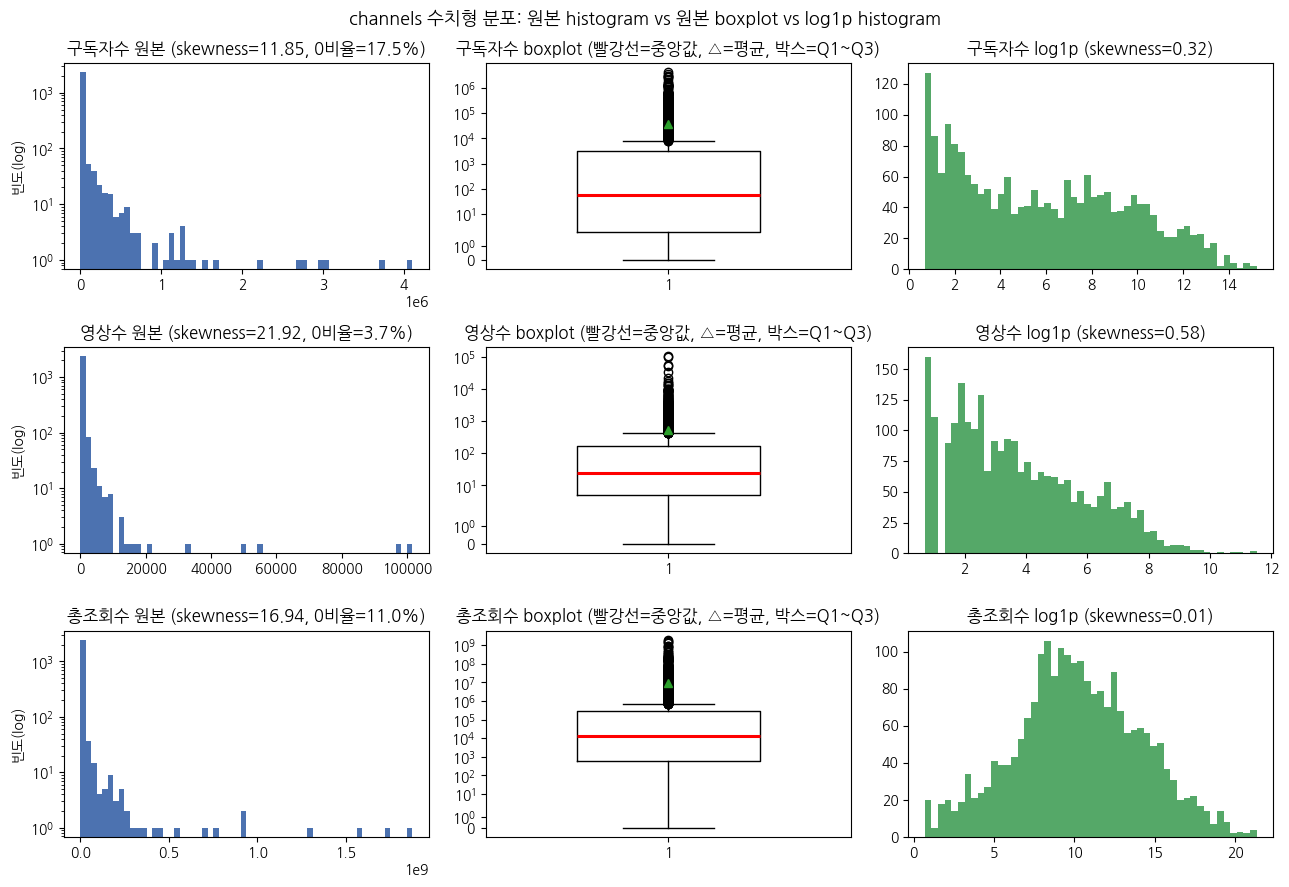

In [9]:
def dist_grid(df, cols, label_map, title):
    n = len(cols)
    fig, axes = plt.subplots(n, 3, figsize=(13, 3*n))
    if n == 1: axes = axes.reshape(1, -1)
    for i, c in enumerate(cols):
        s = df[c].astype(float)
        pos = s[s > 0]
        zero_pct = (s == 0).mean() * 100
        axes[i,0].hist(s, bins=60, color='#4c72b0'); axes[i,0].set_yscale('log')
        axes[i,0].set_title(f'{label_map[c]} 원본 (skewness={s.skew():.2f}, 0비율={zero_pct:.1f}%)')
        axes[i,0].set_ylabel('빈도(log)')
        axes[i,1].boxplot(s, vert=True, widths=0.5, showmeans=True,
                          medianprops=dict(color='red', linewidth=2.2)); axes[i,1].set_yscale('symlog')
        axes[i,1].set_title(f'{label_map[c]} boxplot (빨강선=중앙값, △=평균, 박스=Q1~Q3)')
        sl = np.log1p(pos)
        axes[i,2].hist(sl, bins=50, color='#55a868')
        axes[i,2].set_title(f'{label_map[c]} log1p (skewness={sl.skew():.2f})')
    fig.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()

dist_grid(df_channels, ch_num,
          {'subscriber_count':'구독자수','video_count':'영상수','view_count':'총조회수'},
          'channels 수치형 분포: 원본 histogram vs 원본 boxplot vs log1p histogram')

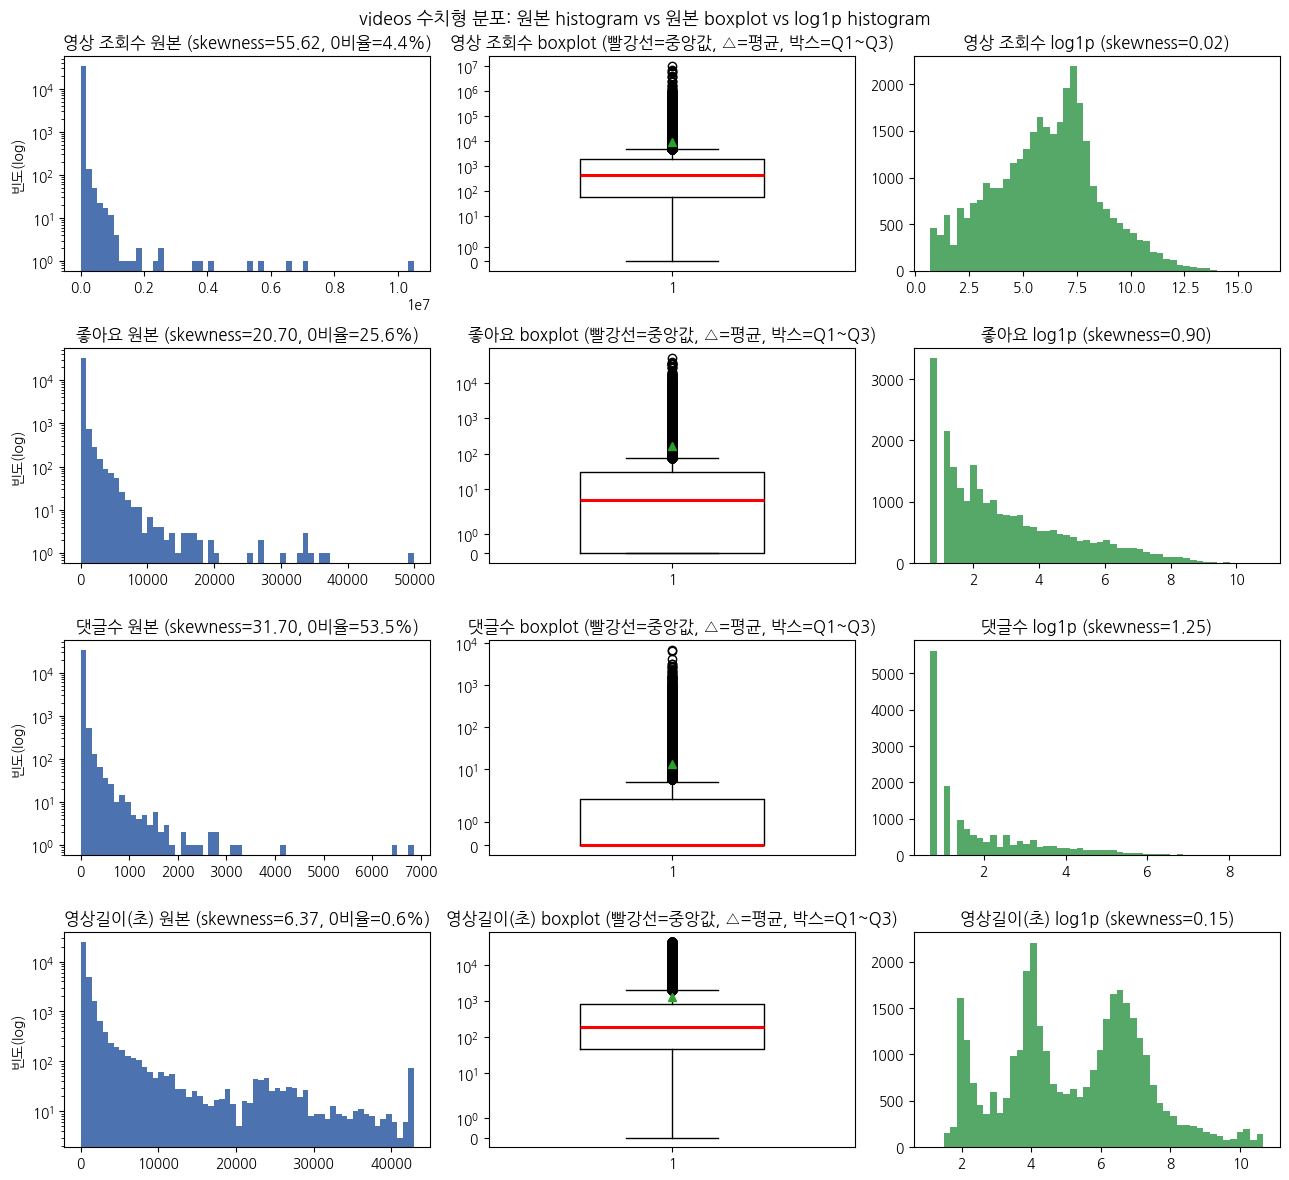

In [10]:
dist_grid(df_videos, vid_num,
          {'view_count':'영상 조회수','like_count':'좋아요','comment_count':'댓글수','duration_seconds':'영상길이(초)'},
          'videos 수치형 분포: 원본 histogram vs 원본 boxplot vs log1p histogram')

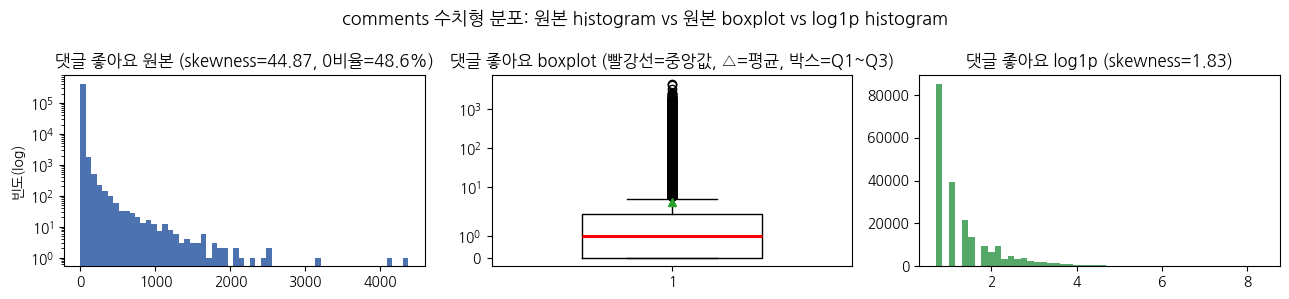

In [11]:
dist_grid(df_comments, cm_num,
          {'like_count':'댓글 좋아요'},
          'comments 수치형 분포: 원본 histogram vs 원본 boxplot vs log1p histogram')

##### 3-2-3. 참여 비율 - 수치형 파생 Attributes
**목적**: 3-2-2서 `like_count`·`comment_count`는 규모 보정만으론 부족 — 둘 다 **조회수 종속**(조회 100만 영상 좋아요 1,000 ≠ 조회 2,000 영상 좋아요 1,000)이라 절대수는 규모효과지 참여의 질 아님. 조회수로 나눈 **참여율** 도입해 채널 간 비교하는 변수 생성해보자

**방법**: `like_rate = like/view`·`comment_rate = comment/view`(유튜브 표준 지표). `view=0`은 비율 정의 불가 + 도메인상 view=0인데 좋아요·댓글 있으면 anomaly → **비율 계산에서 제외**. 비율도 우편향이니 log1p축으로 형태 확인.

**결과** (view>0 = 32,670 / 34,162 영상)

| 지표 | 중앙값 | P99 | >1(비정상) |
|---|---|---|---|
| like_rate | 0.014 | 0.27 | 19개 |
| comment_rate | 0.000 | 0.25 | 5개 |

**결론**
- 두 파생변수 `like_rate`·`comment_rate` 모두 채택 = 규모효과 제거된 참여율 지표
- `like_rate`: 0비율 22.4%로 적음 → **log1p**만으로 충분
- `comment_rate`: 과반 0(51.9%) → **0/비0 분리 후 has_comment flag + 비0 log1p**로 사용하는게 합리적
- 비율>1 비정상값은 4-3에서 갈라 처리 — `like_rate>1`(좋아요>조회)은 물리적 불가능 = 데이터오류라 **삭제**, `comment_rate>1`은 한 명이 댓글 여러 개 가능(오류 단정 불가)이라 **보존**


비율 계산 대상(view>0): 32,670 / 34,162 영상
like_rate>1 (좋아요>조회, 비정상): 19개
comment_rate>1: 5개


속성,개수,평균,중앙값,0비율%,표준편차,IQR,CV,QCD,skewness,kurtosis,P90,P99,max/P99
like_rate,"32,670",0.00,0.00,22.40,0.10,0.00,3.01,0.95,36.81,"2,312.02",0.10,0.30,30.80
comment_rate,"32,670",0.00,0.00,51.90,0.10,0.00,6.21,1.00,14.03,280.27,0.00,0.20,12.00


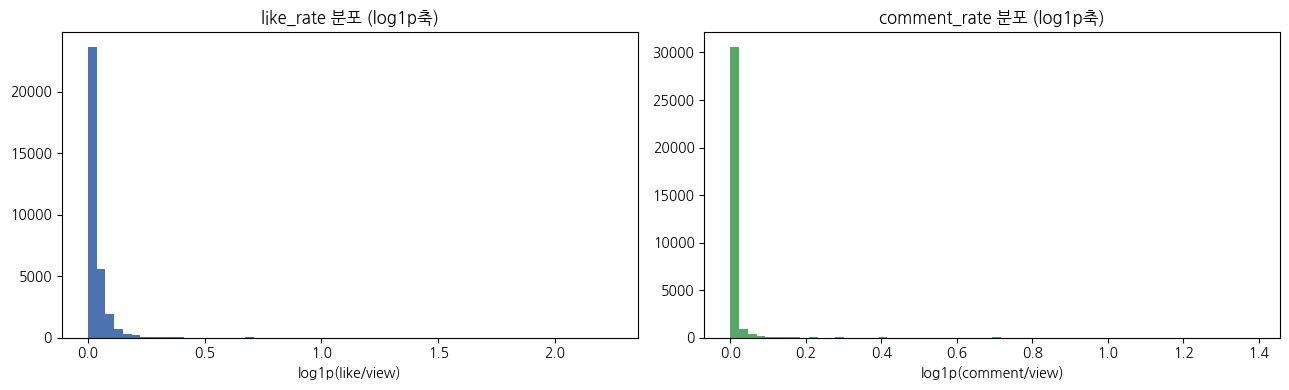

In [12]:
# 조회수>0 영상만
v = df_videos[df_videos['view_count'] > 0].copy()
v['like_rate']    = v['like_count']    / v['view_count']
v['comment_rate'] = v['comment_count'] / v['view_count']

print(f"비율 계산 대상(view>0): {len(v):,} / {len(df_videos):,} 영상")
print(f"like_rate>1 (좋아요>조회, 비정상): {int((v['like_rate']>1).sum())}개")
print(f"comment_rate>1: {int((v['comment_rate']>1).sum())}개")
display(describe_numeric(v, ['like_rate', 'comment_rate']))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# 비율도 우편향 → log1p 축으로 형태 확인
ax[0].hist(np.log1p(v['like_rate']),    bins=60, color='#4c72b0')
ax[0].set_title('like_rate 분포 (log1p축)');    ax[0].set_xlabel('log1p(like/view)')
ax[1].hist(np.log1p(v['comment_rate']), bins=60, color='#55a868')
ax[1].set_title('comment_rate 분포 (log1p축)'); ax[1].set_xlabel('log1p(comment/view)')
plt.tight_layout(); plt.show()

##### 3-2-4. Frequency - 범주형 Attributes
**목적**: 범주형은 평균·분산이 무의미 → 값별 빈도·고유값으로 파악. (1) `info()`가 못 잡는 빈문자(`''`) 숨은 결측 가시화, (2) 실측 `is_shorts` 라벨 분포 확인, (3) 영상단위 빈도를 **채널단위로 집계**해 채널당 Shorts 수·비율 파

**방법**: 빈 문자열은 `(빈값)`으로 치환해 결측처럼 노출, value_counts로 분포 확인. 영상 길이 `duration_seconds`는 구간화(≤180s/3~10분/10~30분/>30분)해서 확인. Shorts 판정은 길이 근사가 아니라 **실측 결과값인 `is_shorts`**(redirect 판별 - 크롤링 이후 따로 진행)를 사용 — 길이 근사(≤180s)와 교차해 오차도 확인. 채널 집계는 `groupby(channel_id)`로 `short_count`(=is_shorts 합)·`short_ratio`(=합/영상수). 영상 0개 empty 채널 85개는 분모 0이라 집계에서 제외(2,423채널만).

**결과**

| 변수 | 분포 | 관찰 |
|---|---|---|
| `country` (채널) | 고유 11. KR 1,337(53.3%) / (빈값) 1,126(44.9%) / US 26 / 그외 극소수 | KR·빈값 양분, 해외 무시 가능 |
| `language` (채널) | 고유 5. (빈값) 2,425(96.7%) / ko 79 / 그외 4 | 거의 전부 미기재 |
| `search_query` (채널) | 30종 전부 등장, 채널당 45~98개(중앙 87)로 고름 | 크롤링 시 설계 의도대로 |
| `is_shorts` (영상, 실측) | 1=15,071(44.1%) / 0=19,091(55.9%) | Shorts가 영상의 약 44% |
| `duration`→길이형식 (영상) | ≤180s 49.7% / 3~10분 17.1% / 10~30분 22.5% / >30분 10.7% | shorts, 일반 영상, 라이브 영상 혼재 |

**채널 집계** (영상보유 2,423채널, empty 85 제외)

| 파생 | 분포 | 관찰 |
|---|---|---|
| `short_count` (채널당 Shorts 수) | 중앙 3 / 평균 6.2 / max 20 | 절반은 최근 20개 영상 중 3개 이하 |
| `short_ratio` (채널당 Shorts 비율) | 중앙 0.55 / 평균 0.518. 구간: **0(없음) 857** / 0~0.2 152 / 0.2~0.8 350 / **0.8~1.0 1,064**(완전1.0=972) | **양극단** — Shorts 안 쓰는 채널 vs Shorts 공장 |

*실측 Shorts(15,071)는 전부 ≤180s 안에 속함. 길이 근사(≤180s=16,986)는 실측보다 1,915개 많음(근사 false positive 11.3%) → 길이 근사 폐기, 실측 `is_shorts` 사용.

**결론**
- `country` → KR/비KR 이진 분류 `is_kr`(4-1).
- `language` → 결측 96.7%로 정보가치 거의 없음 → **feature 제외** 확정
- `search_query` → 균등 분포라 빈도 자체는 정보가치 없음 + **분류 입력 feature 금지(leakage)**. 평가·시드라벨로만 사용하자
- `is_shorts` → 영상 44.1%가 Shorts = 비중 생각보다 큼. **실측 라벨 그대로 채널별 `short_ratio`로 집계**(4-4). 길이 근사 불필요.
- `short_ratio` 채널분포 = **뚜렷한 양극화(0:857 / 0.8~1.0:1,064)** → 중간대(0.2~0.8) 350개뿐 → **H2 군집 분리 강신호**, H1 입력 feature 후보.
- 영상 길이 형식 → 장문(>30분 10.7%)엔 라이브 다시보기 혼재. 단 **라이브는 Shorts처럼 실측하지 않음** — 도메인상 정상 채널도 라이브(시황방송·다시보기)를 매우 많이 해 의심·정상군 분포가 겹쳐 판별력이 낮음.


In [13]:
def show_categorical(s, name, top=None):
    s = s.fillna('').astype(str).str.strip().replace('', '(빈값)')
    vc = s.value_counts()
    print(f'[{name}] 고유값 {s.nunique()}개 / 최빈값: {vc.index[0]} ({vc.iloc[0]:,})')
    return vc.head(top) if top else vc

# country (채널, 숨은 결측 가시화)
print(show_categorical(df_channels['country'], 'country').head(8)); print()
# language (채널, 숨은 결측 가시화)
print(show_categorical(df_channels['language'], 'language').head(6))

[country] 고유값 11개 / 최빈값: KR (1,337)
country
KR      1337
(빈값)    1126
US        26
IN         8
AU         4
GB         2
NZ         1
HK         1
Name: count, dtype: int64

[language] 고유값 5개 / 최빈값: (빈값) (2,425)
language
(빈값)     2425
ko         79
hi          2
en          1
en-IN       1
Name: count, dtype: int64


In [14]:
# search_query (채널, 수집 키워드 30종 — 분류 입력 feature 제외)
sq = df_channels['search_query'].fillna('').astype(str).str.strip().replace('', '(빈값)').value_counts()
print(f'[search_query] 고유값 {len(sq)}개 / 키워드당 채널수 평균 {sq.mean():.1f} ± {sq.std():.1f}'
      f' (min {sq.min()} ~ max {sq.max()})')
print(sq.head(30))

[search_query] 고유값 30개 / 키워드당 채널수 평균 83.6 ± 13.5 (min 45 ~ max 98)
search_query
급등주       98
수익률보장     98
기업분석      98
경제전망      97
주식자동매매    95
애널리스트     95
주식리딩방     93
단타매매      93
증권사리포트    93
코스피       92
오늘의추천주    91
테마주       90
재테크       90
주식종목추천    87
VIP종목     87
ETF투자     87
무료리딩      85
주식대박      85
주식차트      84
주식투자방법    83
개인투자자     81
주식시장      80
코스닥       79
주식공부      79
주식시황      77
미국주식      72
주식투자      61
주식초보      61
주식유튜브     52
주식방송      45
Name: count, dtype: int64


[is_shorts] 고유값 2개 / 최빈값: 0 (19,091)
is_shorts
0    19091
1    15071
Name: count, dtype: int64

[영상 길이 형식]
duration_seconds
≤180s     16986
3~10분      5851
10~30분     7673
>30분       3652
Name: count, dtype: int64

[Shorts 근사 vs 실측] 실측 15,071 ⊂ ≤180s 16,986 → 근사 오판(≤180s지만 일반영상) 1,915개 (FP 11.3%)


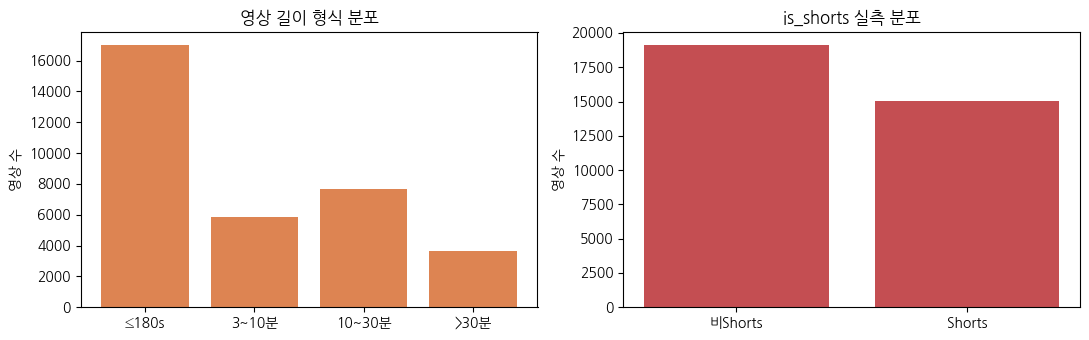


[채널 Shorts 집계] 영상보유 2,423채널 (empty 85개 제외)
  short_count  중앙 3 / 평균 6.22 / max 20
  short_ratio  중앙 0.550 / 평균 0.518 / 완전0 857 / 완전1 972


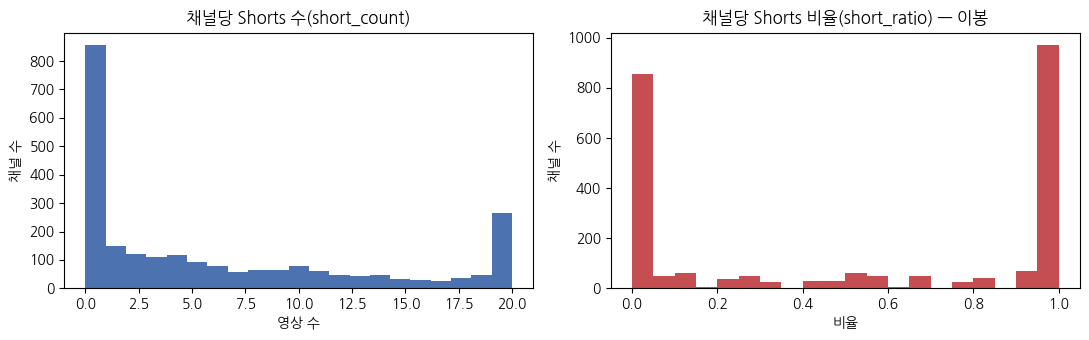

In [15]:
# is_shorts (영상, 실측 Shorts 라벨 — redirect 판별 후 DB 기록)
print(show_categorical(df_videos['is_shorts'], 'is_shorts'))

# 영상 길이 형식 (duration_seconds → 길이 구간. Shorts는 실측 is_shorts로 별도 판정)
dur_bucket = pd.cut(df_videos['duration_seconds'], [-1, 180, 600, 1800, np.inf],
                    labels=['≤180s', '3~10분', '10~30분', '>30분'])
db = dur_bucket.value_counts().reindex(['≤180s', '3~10분', '10~30분', '>30분'])
print('\n[영상 길이 형식]'); print(db)

# 길이 근사(≤180s) vs 실측 is_shorts 교차 — 근사 오차 확인
_approx = (df_videos['duration_seconds'] <= 180)
_real   = (df_videos['is_shorts'] == 1)
_fp = int((_approx & ~_real).sum())
print(f'\n[Shorts 근사 vs 실측] 실측 {int(_real.sum()):,} ⊂ ≤180s {int(_approx.sum()):,}'
      f' → 근사 오판(≤180s지만 일반영상) {_fp:,}개 (FP {_fp/_approx.sum()*100:.1f}%)')

fig2, ax2 = plt.subplots(1, 2, figsize=(11, 3.5))
ax2[0].bar(db.index, db.values, color='#dd8452'); ax2[0].set_title('영상 길이 형식 분포'); ax2[0].set_ylabel('영상 수')
isd = df_videos['is_shorts'].map({1: 'Shorts', 0: '비Shorts'}).value_counts()
ax2[1].bar(isd.index, isd.values, color='#c44e52'); ax2[1].set_title('is_shorts 실측 분포'); ax2[1].set_ylabel('영상 수')
plt.tight_layout(); plt.show()

# ---- 채널 집계: 채널당 Shorts 수·비율 (분석단위=채널) ----
# empty 채널(영상 0개)은 groupby에 안 잡혀 자동 제외
_g = df_videos.groupby('channel_id')['is_shorts']
ch_short = pd.DataFrame({'short_count': _g.sum(), 'video_count': _g.size()})
ch_short['short_ratio'] = ch_short['short_count'] / ch_short['video_count']
print(f'\n[채널 Shorts 집계] 영상보유 {len(ch_short):,}채널 (empty {df_channels.shape[0]-len(ch_short)}개 제외)')
print(f"  short_count  중앙 {ch_short['short_count'].median():.0f} / 평균 {ch_short['short_count'].mean():.2f} / max {ch_short['short_count'].max()}")
print(f"  short_ratio  중앙 {ch_short['short_ratio'].median():.3f} / 평균 {ch_short['short_ratio'].mean():.3f}"
      f" / 완전0 {int((ch_short['short_ratio']==0).sum())} / 완전1 {int((ch_short['short_ratio']==1).sum())}")

fig3, ax3 = plt.subplots(1, 2, figsize=(11, 3.5))
ax3[0].hist(ch_short['short_count'], bins=21, color='#4c72b0')
ax3[0].set_title('채널당 Shorts 수(short_count)'); ax3[0].set_xlabel('영상 수'); ax3[0].set_ylabel('채널 수')
ax3[1].hist(ch_short['short_ratio'], bins=20, color='#c44e52')
ax3[1].set_title('채널당 Shorts 비율(short_ratio) — 이봉'); ax3[1].set_xlabel('비율'); ax3[1].set_ylabel('채널 수')
plt.tight_layout(); plt.show()

##### 3-2-5. 시간 분포 - 시간 Attributes
**목적**: 문자열 날짜를 `datetime` 변환 후 채널 개설·영상 업로드 시간 분포 확인. 이유 3가지:
- (1) **채널 개설 시기 추세** — 언제 채널들이 새로 생겼나. 리딩방이 한꺼번에 늘어난 시점 단서.
- (2) **수집 표본의 시점 쏠림** — 수집된 영상이 특정 시기에 몰렸는지. 조회·좋아요 raw 수를 영상 나이로 보정해야 하는 근거를 찾자(3-2-6).
- (3) **업로드 시간대 분석** — 하루 중 몇 시에 영상을 올리나. 장 마감 후 다음날 종목 띄우기 등 시황 민감도(H3) 단서.

**결과**
| 대상 | 범위 | 관찰 |
|---|---|---|
| 채널 개설 | 2005-11 ~ 2026-06 | 2026년 930개(전체 37%)·2025년 352개 → **최근 급증**, 절반(52%)이 1.5년 내 신설 |
| 영상 업로드 | 2009-02 ~ 2026-06 | 최근 3개월 63.8% / 12개월 80.9% → **극단 최근 편중** |
| 업로드 시각(KST) | 0~23시 | 18시 모드 9.2%, 장중(9~15시) 32.2% / 장마감후(16~20시) 38.2%, 주말 20.8% |

**결론**
- `published_at` → `datetime` 변환 확정. 채널 개설일에서 채널 나이 feature(`channel_age`) 파생 가능.
- 크롤링 시 최신순 영상 20개 수집해서 영상 업로드 날짜 편중 → **나이보정 `video_age_days` 필수(3-2-6)**
- 2026년 채널 개설 급증(37%) = 리딩방 신생 가설 후보 feature로 놓고 살펴보기
- 업로드 18시 집중·장마감후(16~20시) 38.2% → **장 마감 후 다음날 종목 띄우기 의심**(H3 시황민감도 단변량 근거). 그룹 간 비교는 H3 본분석.

채널 개설: 최초 2005-11-17 ~ 최근 2026-06-02
영상 업로드: 최초 2009-02-15 ~ 최근 2026-06-03
영상 최근 3개월(age<=90일) 63.8% / 12개월(<=365일) 80.9%
채널 개설 2026년 930개(37%) / 2025년 352개 / 1.5년내 신설 52%


/tmp/ipykernel_7173/1884276945.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  vid_dt.dt.to_period('M').value_counts().sort_index().tail(24).plot(kind='bar', ax=ax[1], color='#55a868')


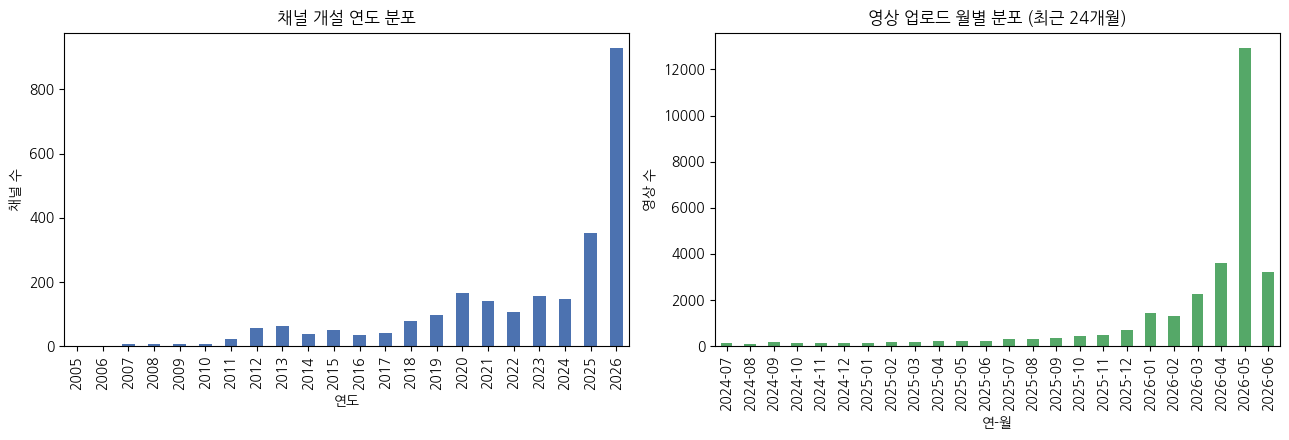

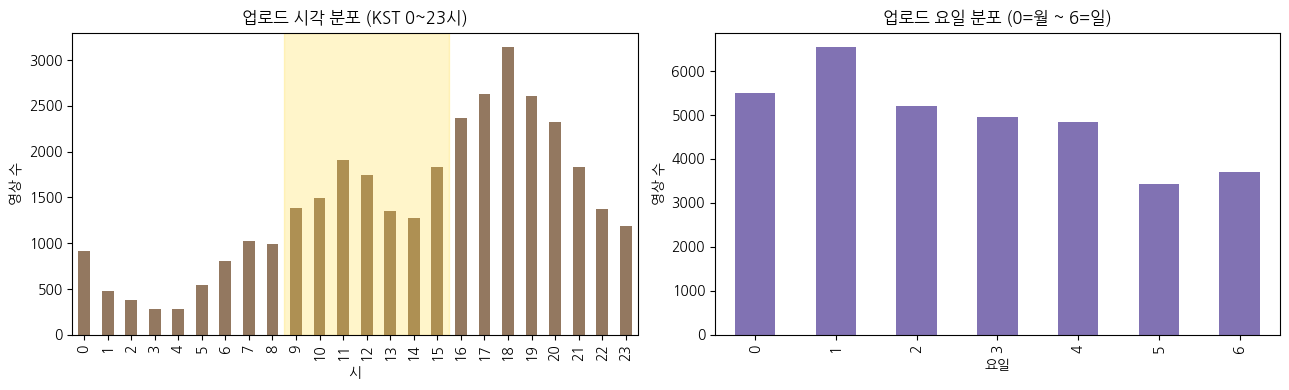

업로드 18시 9.2% / 장중(9~15시) 32.2% / 장마감후(16~20시) 38.2% / 주말 20.8%


In [16]:
ch_dt  = pd.to_datetime(df_channels['published_at'], format='ISO8601', utc=True)
vid_dt = pd.to_datetime(df_videos['published_at'],   format='ISO8601', utc=True)

print('채널 개설: 최초', ch_dt.min().date(), '~ 최근', ch_dt.max().date())
print('영상 업로드: 최초', vid_dt.min().date(), '~ 최근', vid_dt.max().date())
# 업로드 최근 편중(영상 나이 기준) + 채널 개설 연도/신생 비율
_vage = (pd.to_datetime(df_videos['collected_at'], format='ISO8601', utc=True) - vid_dt).dt.total_seconds() / 86400
print(f'영상 최근 3개월(age<=90일) {(_vage<=90).mean()*100:.1f}% / 12개월(<=365일) {(_vage<=365).mean()*100:.1f}%')
_cyr = ch_dt.dt.year.value_counts()
_cage = (pd.to_datetime(df_channels['collected_at'], format='ISO8601', utc=True) - ch_dt).dt.total_seconds() / 86400
print(f'채널 개설 2026년 {int(_cyr.get(2026,0))}개({_cyr.get(2026,0)/len(ch_dt)*100:.0f}%) / 2025년 {int(_cyr.get(2025,0))}개 / 1.5년내 신설 {(_cage<=547.5).mean()*100:.0f}%')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ch_dt.dt.year.value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4c72b0')
ax[0].set_title('채널 개설 연도 분포'); ax[0].set_xlabel('연도'); ax[0].set_ylabel('채널 수')
vid_dt.dt.to_period('M').value_counts().sort_index().tail(24).plot(kind='bar', ax=ax[1], color='#55a868')
ax[1].set_title('영상 업로드 월별 분포 (최근 24개월)'); ax[1].set_xlabel('연-월'); ax[1].set_ylabel('영상 수')
plt.tight_layout(); plt.show()

# 업로드 시각대(KST) — H3 시황 민감도 단변량 근거 (장중 9~15시 vs 장마감후)
vid_kst = vid_dt.dt.tz_convert('Asia/Seoul')
hr = vid_kst.dt.hour
fig2, ax2 = plt.subplots(1, 2, figsize=(13, 4))
hr.value_counts().sort_index().plot(kind='bar', ax=ax2[0], color='#937860')
ax2[0].set_title('업로드 시각 분포 (KST 0~23시)'); ax2[0].set_xlabel('시'); ax2[0].set_ylabel('영상 수')
ax2[0].axvspan(8.5, 15.5, color='#ffd92f', alpha=0.25)  # 장중 9~15시 음영
vid_kst.dt.weekday.value_counts().sort_index().plot(kind='bar', ax=ax2[1], color='#8172b3')
ax2[1].set_title('업로드 요일 분포 (0=월 ~ 6=일)'); ax2[1].set_xlabel('요일'); ax2[1].set_ylabel('영상 수')
plt.tight_layout(); plt.show()
print(f'업로드 18시 {(hr==18).mean()*100:.1f}% / 장중(9~15시) {hr.between(9,15).mean()*100:.1f}% / 장마감후(16~20시) {hr.between(16,20).mean()*100:.1f}% / 주말 {vid_kst.dt.weekday.isin([5,6]).mean()*100:.1f}%')

##### 3-2-6. 수집시점 나이 - 파생 시간 Attributes
**목적**: `collected_at − published_at`으로 영상·채널 두 나이를 계산하고, **나이가 raw 카운트(view/like/comment)를 교란하는지 점검**. 이론상 게시 후 시간이 길수록 조회가 누적됨(1일차 100만 ≠ 5년차 100만) → 실제 데이터에서 교란 정도를 확인해 보정 필요성 판단. 동시에 음수(게시>수집)로 수집 시점 정합성 점검.

**결과**
| 대상 | 중앙값 | 범위 | 음수(게시>수집=오류) |
|---|---|---|---|
| 영상 나이 | 39일 | 0 ~ 6,316일(17년) | 0개 |
| 채널 나이 | 480일(1.3년) | 0 ~ 7,502일(20.6년) | 0개 |

- 채널 1년 미만 신생 = **46.8%**(거의 절반)
- 영상 나이 vs 조회수 **Spearman ρ = −0.06**(거의 무상관)
  - *Spearman = 순위 기반 상관 계수*: 기존 데이터가 강한 우편향·극단치라 Pearson(선형·정규 가정)은 극단치에 휘둘림 → 값을 순위로 바꿔 계산하는 Spearman으로 관계를 강건하게 확인(|ρ|<0.1 무상관)

**결론**
- `video_age_days` → 원본 데이터 view 주요 교란 원인 **아님**(ρ≈0, 나이 구간별 조회 중앙값 534→517→338→250로 평탄·약감소 = 누적 우상향 없음, 산점도도 같은 나이서 광분산). 원인 = 3-2-5 시점 편향(수집이 최근 영상 위주 → 나이 범위 압축, 자연 누적 가려짐). 따라서 raw 카운트를 나이로 나누는 **보정용으로는 불필요**. 단 채널별 중앙 영상나이(`med_age_days`)는 최근 활동도를 담는 행동 신호라 채널 feature로 유지(4-4 VIF 1.7 = 독립축 확인), 급등·단타 탐지용 속도 파생 후보로도 활용 가능.
- `channel_age_days` → 채널 성숙도 feature. 중앙 1.3년·신생(<1년) 46.8% = 3-2-5 개설 급증의 정량 확인 → 리딩방 신생 가설 정량 근거, 후보 feature로 놓고 살펴보기
- 음수 0개 → 게시>수집 영상·채널 없음 = 수집 시점 정합성 정상, anomaly 삭제 불필요(4-3).


영상 나이  중앙 39일 / 범위 0~6316일 / 음수(오류) 0개
채널 나이  중앙 480일(1.3년) / 범위 0~7502일 / 음수(오류) 0개
1년 미만 신생 채널: 46.8%
영상 나이-조회수 Spearman rho = -0.06
나이구간별 조회수 중앙값: 0~30일 534 / 30~180일 517 / 180~365일 338 / 365일+ 250


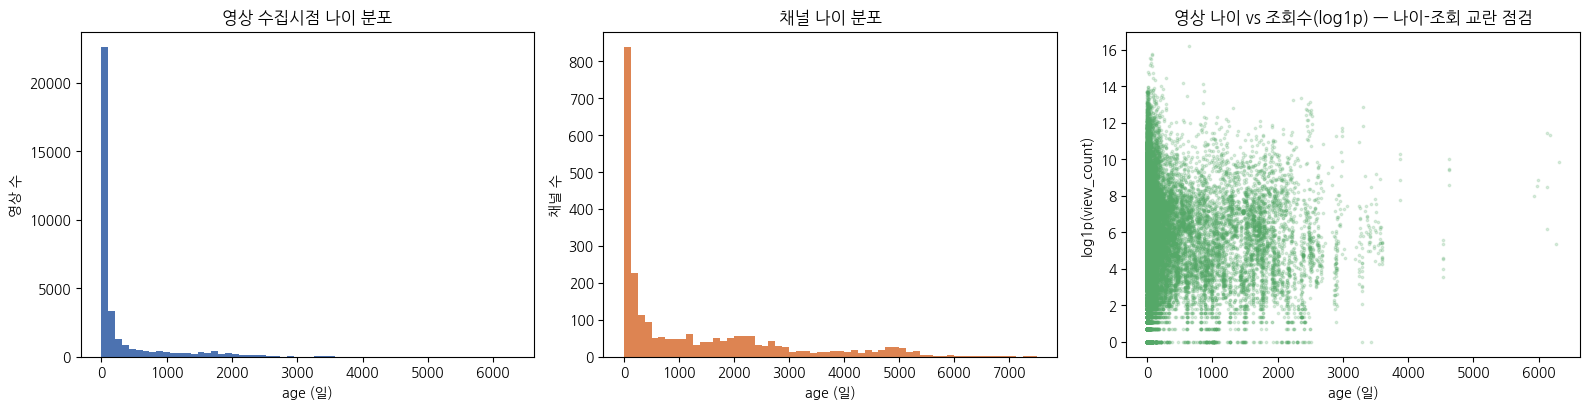

In [17]:
# 두 나이 파생: 수집시점 − 게시/개설시점
vid_age = (pd.to_datetime(df_videos['collected_at'],   format='ISO8601', utc=True)
           - pd.to_datetime(df_videos['published_at'], format='ISO8601', utc=True)).dt.total_seconds() / 86400
ch_age  = (pd.to_datetime(df_channels['collected_at'],   format='ISO8601', utc=True)
           - pd.to_datetime(df_channels['published_at'], format='ISO8601', utc=True)).dt.total_seconds() / 86400

print(f'영상 나이  중앙 {vid_age.median():.0f}일 / 범위 {vid_age.min():.0f}~{vid_age.max():.0f}일 / 음수(오류) {int((vid_age<0).sum())}개')
print(f'채널 나이  중앙 {ch_age.median():.0f}일({ch_age.median()/365:.1f}년) / 범위 {ch_age.min():.0f}~{ch_age.max():.0f}일 / 음수(오류) {int((ch_age<0).sum())}개')
print(f'1년 미만 신생 채널: {(ch_age<365).mean()*100:.1f}%')

# 나이가 raw view를 끄는지: Spearman + 나이구간별 조회 중앙값(프로즈 수치 재현용)
rho = stats.spearmanr(vid_age, df_videos['view_count']).correlation
age_bin = pd.cut(vid_age, [0, 30, 180, 365, np.inf], labels=['0~30일','30~180일','180~365일','365일+'], right=False)
vmed = df_videos['view_count'].groupby(age_bin, observed=True).median()
print(f'영상 나이-조회수 Spearman rho = {rho:.2f}')
print('나이구간별 조회수 중앙값:', ' / '.join(f'{k} {x:.0f}' for k, x in vmed.items()))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(vid_age.clip(lower=0), bins=60, color='#4c72b0')
ax[0].set_title('영상 수집시점 나이 분포'); ax[0].set_xlabel('age (일)'); ax[0].set_ylabel('영상 수')
ax[1].hist(ch_age.clip(lower=0), bins=60, color='#dd8452')
ax[1].set_title('채널 나이 분포'); ax[1].set_xlabel('age (일)'); ax[1].set_ylabel('채널 수')
# 같은 raw view_count라도 나이가 다르면 의미가 다름: age vs view(log)
ax[2].scatter(vid_age.clip(lower=0), np.log1p(df_videos['view_count']), s=3, alpha=0.2, color='#55a868')
ax[2].set_title('영상 나이 vs 조회수(log1p) — 나이-조회 교란 점검')
ax[2].set_xlabel('age (일)'); ax[2].set_ylabel('log1p(view_count)')
plt.tight_layout(); plt.show()


##### 3-2-7. 텍스트 길이 - 텍스트 Attributes
**목적**: 텍스트 자체(NLP)는 H1 feature·H3 입력으로 4장·모델링 단계서 본격 처리하지만, *길이*는 수치형으로 탐색 가능. (1) 길이0 = 빈 문자열 → `info()`가 못 잡는 숨은 결측 규모 가시화, (2) max로 API로 데이터 가져오면서 잘린 데이터 있는지 확인, (3) 분포로 장문·복붙·도배 단서 사전 점검. NLP 대상 = 채널/영상 `title`·`description`, 댓글 `author`·`text` 전부 길이·결측 확인.

**방법**: `strip()` 후 글자 수 → 변수별 최소·중앙·최대로 분포 폭 파악.

**결과**

| 변수 | 최소 | 중앙값 | 최대 | 길이0(빈값) |
|---|---|---|---|---|
| 채널 `title` | 1 | 8 | 37 | 0 |
| 채널 `description` | 0 | 154 | 999 | 311(12.4%) |
| 영상 `title` | 1 | 43 | 100 | 0 |
| 영상 `description` | 0 | 220 | 4,997 | 3,547(10.4%) |
| 댓글 `author` | 0 | 8 | 31 | 9(0.0%) |
| 댓글 `text` | 0 | 25 | 5,070 | 205(0.0%) |

**결론**
- 빈값 결측 = 채널 설명 311(12.4%)·영상 설명 3,547(10.4%)만 유의 → 둘 다 4-1서 Retention(원값 보존), 영상 설명은 4-4서 NLP 입력. 제목·작성자·댓글내용은 사실상 결측 0 → NLP 입력 그대로 사용 가능.
- API max값 : 채널 설명 999·영상 설명 4,997 = API 응답 상한 흔적 → 길이 feature는 상한 포화 감안. 영상 제목 max 100 = 유튜브 제목 글자 제한과 일치.
- 댓글 `text` 중앙 25·최대 5,070 = 짧은 응원~장문 혼재 → 도배·복붙 탐지 시 길이+중복 교차 확인할 것(text 고유 342,246 = 중복 다수 있음). `author` 최대 31 = 핸들 길이 제한이라 변별력 낮음 → 작성자는 길이 아닌 도배 빈도로만 활용.


채널 title         최소  1 / 중앙     8 / 최대    37 / (빈값) 0(0.0%)
채널 description   최소  0 / 중앙   154 / 최대   999 / (빈값) 311(12.4%)
영상 title         최소  1 / 중앙    43 / 최대   100 / (빈값) 0(0.0%)
영상 description   최소  0 / 중앙   220 / 최대  4997 / (빈값) 3547(10.4%)
댓글 author        최소  0 / 중앙     8 / 최대    31 / (빈값) 9(0.0%)
댓글 text          최소  0 / 중앙    25 / 최대  5070 / (빈값) 205(0.0%)


댓글 text 고유값(중복 제거): 342,246 / 전체 423,522 → 중복 다수


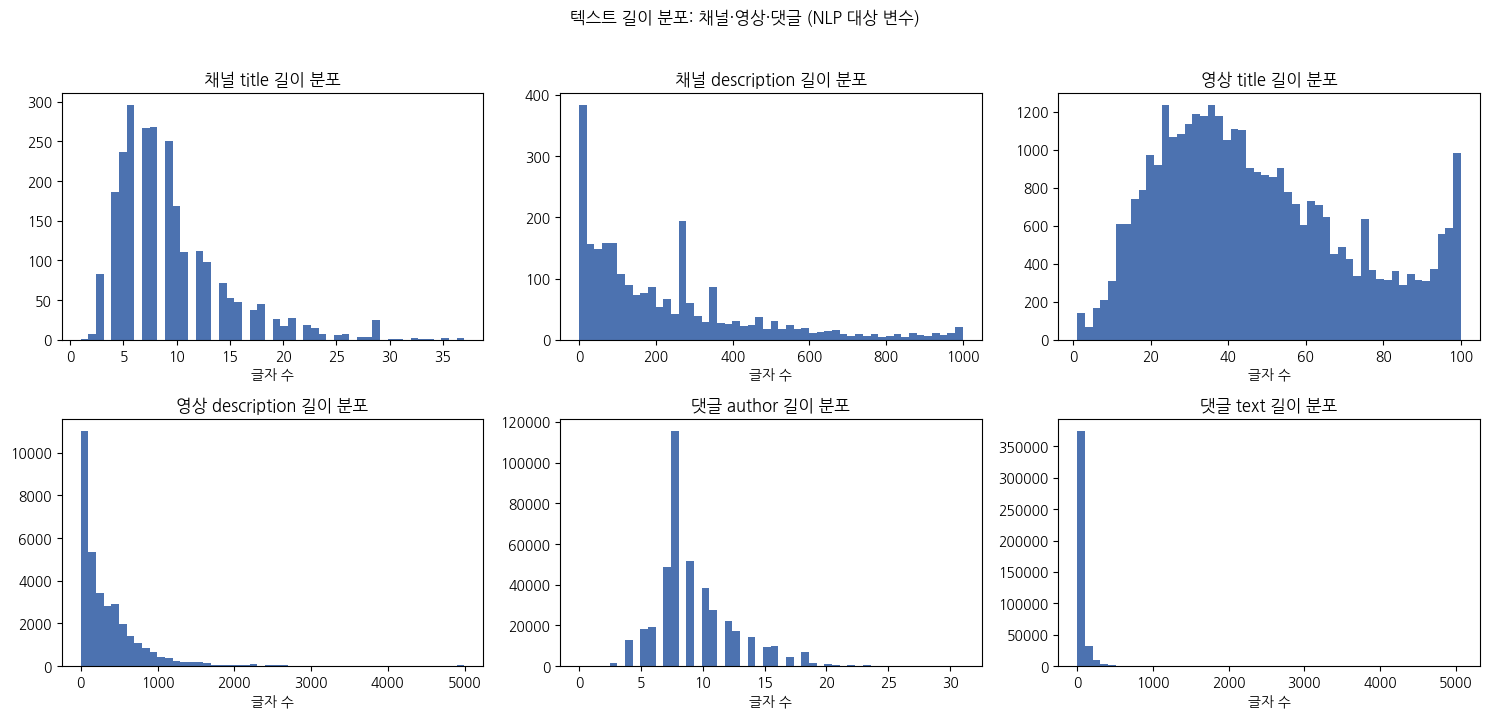

In [18]:
def len_stat(s):
    return s.fillna('').astype(str).str.strip().str.len()  # strip 기준 → 길이0 = 결측분석 빈값과 일치

txt_cols = {
    '채널 title':       df_channels['title'],
    '채널 description': df_channels['description'],
    '영상 title':       df_videos['title'],
    '영상 description': df_videos['description'],
    '댓글 author':      df_comments['author'],
    '댓글 text':        df_comments['text'],
}
lens = {k: len_stat(v) for k, v in txt_cols.items()}

for k, L in lens.items():
    z = int((L == 0).sum())
    print(f'{k:16s} 최소 {L.min():>2d} / 중앙 {L.median():>5.0f} / 최대 {L.max():>5d} / (빈값) {z}({z/len(L)*100:.1f}%)')
print(f"댓글 text 고유값(중복 제거): {df_comments['text'].fillna('').astype(str).str.strip().nunique():,} / 전체 {len(df_comments):,} → 중복 다수")

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, (k, L) in zip(ax.ravel(), lens.items()):
    a.hist(L, bins=50, color='#4c72b0')
    a.set_title(f'{k} 길이 분포'); a.set_xlabel('글자 수')
fig.suptitle('텍스트 길이 분포: 채널·영상·댓글 (NLP 대상 변수)', y=1.02)
plt.tight_layout(); plt.show()


##### 3-2-8. 댓글 행동 패턴 - 행동 Attributes
**목적**: 댓글 테이블(423,522행)은 이 프로젝트에서 가장 큰 신호원. 3-2-7은 댓글 *길이*만 봤지만, 리딩방·작전 채널의 진짜 흔적은 행동에 있다.
- **소수가 도배**: 적은 수의 작성자(봇·바람잡이)가 댓글을 반복.
- **같은 문구 복붙**: 동일한 텍스트가 여러 번 등장.
- **관리형 토론**: 대댓글이 비정상적으로 많은 구조.

**방법**: 채널마다 세 지표를 계산.
| 지표 | 정의 | 읽는 법 |
|---|---|---|
| `author_uniq` | 고유 작성자수 / 댓글수 | 낮을수록 소수가 도배 |
| `text_uniq` | 고유 텍스트수 / 댓글수 | 낮을수록 같은 문구 복붙 |
| `reply_rate` | 대댓글수 / 댓글수 | 높을수록 관리형 토론 의심 |

**최소 댓글 임계값 10 채택**

최소 댓글 임계값을 1~50으로 바꿔가며 중앙 결론이 흔들리는지 확인

| 댓글 최소 | 채널수 | `author_uniq` 중앙 | `text_uniq` 중앙 | `reply_rate` 중앙 | 작성자 고유율 하위 5%(도배 가장 심한 채널) |
|---|---|---|---|---|---|
| 1 (무필터) | 1,575 | 0.511 | 0.983 | 0.100 | 0.107 |
| 3 | 1,306 | 0.465 | 0.950 | 0.154 | 0.095 |
| 5 | 1,185 | 0.448 | 0.939 | 0.167 | 0.091 |
| **10 (채택)** | **965** | **0.447** | **0.933** | **0.192** | **0.090** |
| 20 | 733 | 0.464 | 0.929 | 0.239 | 0.125 |
| 30 | 604 | 0.488 | 0.935 | 0.260 | 0.159 |
| 50 | 494 | 0.496 | 0.936 | 0.270 | 0.157 |

- `author_uniq`·`text_uniq` 중앙값은 임계 3~50 내내 거의 그대로 → 견고한 지표. 단, 최소 댓글 1개일 때 중앙값이 눈에 띄게 바뀜 → 노이즈가 끼어 있다는 것을 알 수 있음
- 눈에 띄게 변하는 건 `reply_rate`와 하위 5% 채널(도배 가장 심한 채널) 값 → 10일 때 가장 최솟값(0.090) = 도배 신호가 가장 강하게 남는 지점 — 10 미만은 잔챙이 노이즈가 섞여 꼬리가 흐려지고, 20 이상은 댓글 10~20개짜리 진짜 도배 채널이 통째로 걸러져 신호가 빠져나감

**결과** (댓글 10개 이상인 채널 965개)
| 지표 | 중앙값 | 5% 분위 | 최소 | 해석 |
|---|---|---|---|---|
| `author_uniq` | 0.447 | 0.090 | **0.008** | 최소 = 댓글 2,602개를 작성자 ~20명이 작성 = 극단 도배 채널 |
| `text_uniq` | 0.933 | 0.282 | 0.053 | 대체로 다양, 하위 5%는 70% 이상 복붙 |
| `reply_rate` | 0.192 | — | 0 | 전체 대댓글 28.1%, 일부 채널은 75.0%까지 = 관리형 토론방 의심 |

- 같은 텍스트 최다 반복: `감사합니다` **8,481회** 등 정형 응원구 도배 존재.

**결론**
- `author_uniq`(작성자 고유율): 소수 도배 = 극단적으로 값이 적은 채널은 봇·바람잡이를 강하게 의심 → H1·H2 핵심 feature. anomaly=target이라 삭제하지 않고 플래그로 보존(4-3).
- `text_uniq`(텍스트 고유율): 복붙 지표. 단 정형 응원구(`감사합니다`)는 정상 채널에도 쓰이므로 단독으론 약함 → 길이·작성자 집중과 교차 확인.
- `reply_rate`(대댓글 비율): 토론 활성도. 과도하면 관리형 방 신호 후보 → `parent_id`로 채널 집계(4-4)에서 확정.

댓글 10개 이상 채널 965개 / 댓글 보유 채널 1575개


,author_uniq,text_uniq,reply_rate
count,965.000,965.000,965.000
mean,0.458,0.834,0.226
std,0.246,0.224,0.189
min,0.008,0.053,0.000
5%,0.090,0.282,0.000
25%,0.256,0.770,0.048
50%,0.447,0.933,0.192
75%,0.628,0.998,0.394
max,1.000,1.000,0.750


전체 대댓글 비율 28.1%
동일 텍스트 최다 반복 top5:


text
감사합니다      8481
감사합니다.     2058
상수         1795
알림신청합니다    1390
❤          1206
Name: count, dtype: int64

[임계값 민감도]  (author_uniq·text_uniq 중앙이 임계에 둔감 = 결론 robust)
 thr   채널수  author_uniq중앙   text_uniq중앙   reply중앙  author_p5
   1  1575          0.511         0.983     0.100      0.107
   3  1306          0.465         0.950     0.154      0.095
   5  1185          0.448         0.939     0.167      0.091
  10   965          0.447         0.933     0.192      0.090
  20   733          0.464         0.929     0.239      0.125
  30   604          0.488         0.935     0.260      0.159
  50   494          0.496         0.936     0.270      0.157


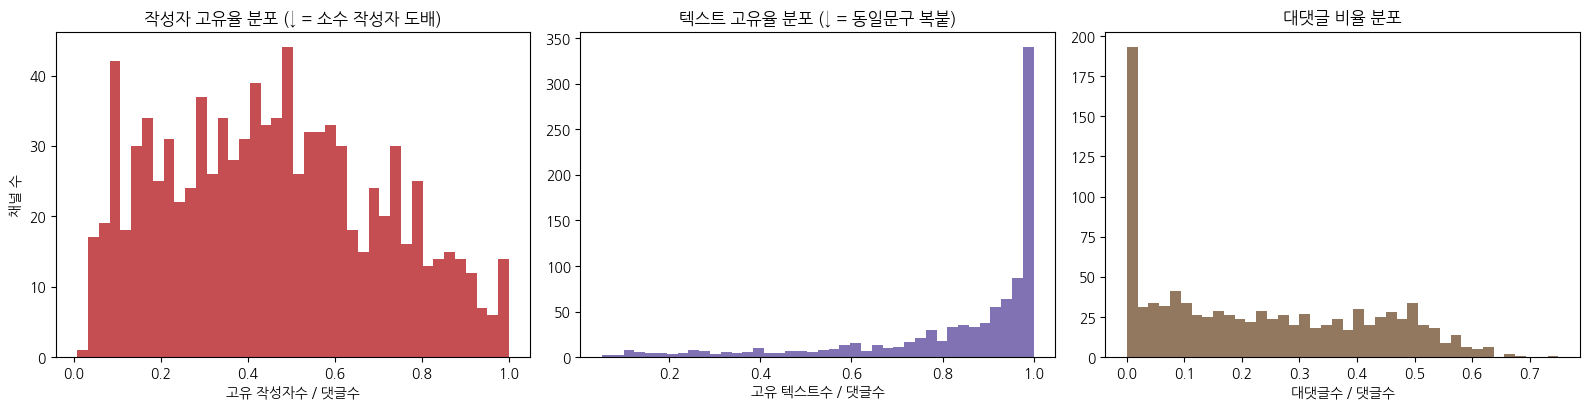

In [19]:
# 댓글 단위(423,522) → 채널 단위 행동 패턴 집계
g = df_comments.groupby('channel_id')
cmt_n = g.size()
beh = pd.DataFrame({
    'comment_n'   : cmt_n,
    'author_uniq' : g['author'].nunique() / cmt_n,   # 작성자 고유율 ↓ = 소수 도배
    'text_uniq'   : g['text'].nunique() / cmt_n,      # 텍스트 고유율 ↓ = 복붙 도배
    'reply_rate'  : df_comments['parent_id'].notna().groupby(df_comments['channel_id']).mean(),  # 대댓글 비율
})
beh_s = beh[beh['comment_n'] >= 10]   # 비율 분모 안정: 댓글 10개 이상 채널만
print(f'댓글 10개 이상 채널 {len(beh_s)}개 / 댓글 보유 채널 {len(beh)}개')
display(beh_s[['author_uniq','text_uniq','reply_rate']].describe(percentiles=[.05,.25,.5,.75]).round(3))
print(f'전체 대댓글 비율 {df_comments["parent_id"].notna().mean()*100:.1f}%')
print('동일 텍스트 최다 반복 top5:'); print(df_comments['text'].value_counts().head(5))

# 임계값 민감도: 댓글 최소 기준 10은 자의적 → 바꿔도 중앙 결론 안 흔들리는지(robust) 확인
print('\n[임계값 민감도]  (author_uniq·text_uniq 중앙이 임계에 둔감 = 결론 robust)')
print(f'{"thr":>4} {"채널수":>5} {"author_uniq중앙":>14} {"text_uniq중앙":>13} {"reply중앙":>9} {"author_p5":>10}')
for t in [1, 3, 5, 10, 20, 30, 50]:
    s = beh[beh['comment_n'] >= t]
    print(f'{t:>4} {len(s):>5} {s["author_uniq"].median():>14.3f} {s["text_uniq"].median():>13.3f} '
          f'{s["reply_rate"].median():>9.3f} {s["author_uniq"].quantile(.05):>10.3f}')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(beh_s['author_uniq'], bins=40, color='#c44e52')
ax[0].set_title('작성자 고유율 분포 (↓ = 소수 작성자 도배)'); ax[0].set_xlabel('고유 작성자수 / 댓글수'); ax[0].set_ylabel('채널 수')
ax[1].hist(beh_s['text_uniq'], bins=40, color='#8172b3')
ax[1].set_title('텍스트 고유율 분포 (↓ = 동일문구 복붙)'); ax[1].set_xlabel('고유 텍스트수 / 댓글수')
ax[2].hist(beh_s['reply_rate'], bins=40, color='#937860')
ax[2].set_title('대댓글 비율 분포'); ax[2].set_xlabel('대댓글수 / 댓글수')
plt.tight_layout(); plt.show()


##### 3-2-9. 연락처·외부유도 형식 - 형식 regex Attributes  (① 형식 추출)
**목적**: 불법 리딩방 핵심 수법 = 시청자를 유튜브 밖 유료방(카톡·텔레그램·밴드)으로 빼내는 것. 연락처 노출 자리 세 곳 — 영상 설명 / 채널 설명 / **채널 주인이 자기 영상에 직접 단 댓글**.

규제어(급등주·리딩방 등)는 라벨 근거라 feature로 쓰면 순환(leakage). URL·연락처는 *의미*가 아니라 *형식*이라 정규식으로 뽑아도 leakage 아님(regex≠ML 원칙) → feature 허용. 형식 플래그만 추출.

**방법**: 여섯 형식 정규식을 세 소스에 적용

| 플래그 | 무엇을 잡나 |
|---|---|
| `has_url` | http/www 링크 |
| `has_kakao` | open.kakao·kakao.com 링크 |
| `has_phone` | 01X-XXXX-XXXX 전화번호 |
| `has_telegram` | t.me·telegram 링크 |
| `has_band` | band.us 링크 |
| `has_email` | 주소@도메인 이메일 |

- **소유자 댓글** 식별: 댓글 작성자 핸들(`@xxx`) == 채널 핸들(`custom_url`)인 댓글만. 시청자가 단 URL은 채널 행동 아니라 제외
- 카톡·텔레그램·밴드는 **단어 아니라 실제 링크 형식**(`open.kakao.com`·`t.me/`·`band.us`)만 매칭 — "카톡 문의" 같은 단순 언급 제외
- `has_email`도 운영자 외부 연락 수단이라 같은 형식 플래그로 포함 — 이메일 있다고 리딩방 안 하는 건 아니라 정상 증거로 분리하지 않음
- 규제 키워드는 일절 매칭 안 함(leakage 차단).

**결과**: 소스별 검출 개수(그래프) + 플래그별 상위 3 예시(구독순) + 채널 단위 보유 수.

| 플래그 | 채널 보유 수 (2,508 중) |
|---|---|
| `has_url` | 1,011 |
| `has_email` | 376 |
| `has_kakao` | 233 |
| `has_phone` | 180 |
| `has_telegram` | 140 |
| `has_band` | 40 |

- 구독순 예시 상위는 전부 **대형 정상 경제채널**(삼프로TV·한국경제TV…) — url·카톡·전화·텔레그램·이메일을 정상 채널도 비즈 용도로 둠. → **플래그 존재(presence) 자체는 정상에도 흔해 단독 판별력 약함**(판별력·사용법은 ② 보조셀에서 분석).
- 채널 단위(세 소스 중 하나라도)로 개별 플래그를 집계해 4-4 `channel_features`에 전달.

*측정 한계*: 채널 "정보" 탭의 **링크란**(홈페이지·카톡·텔레그램 제목+URL 패널)은 YouTube Data API v3 미제공 → **미수집**. 플래그는 description 본문·영상 desc·소유자 댓글 *텍스트*만 본 것 → 링크를 본문에 안 쓰고 링크란에만 둔 채널은 누락 = 채널 desc는 **하한치(undercount)**.

전체 423,522 중 소유자 본인 댓글 53,157개(12.6%), 1,238개 채널


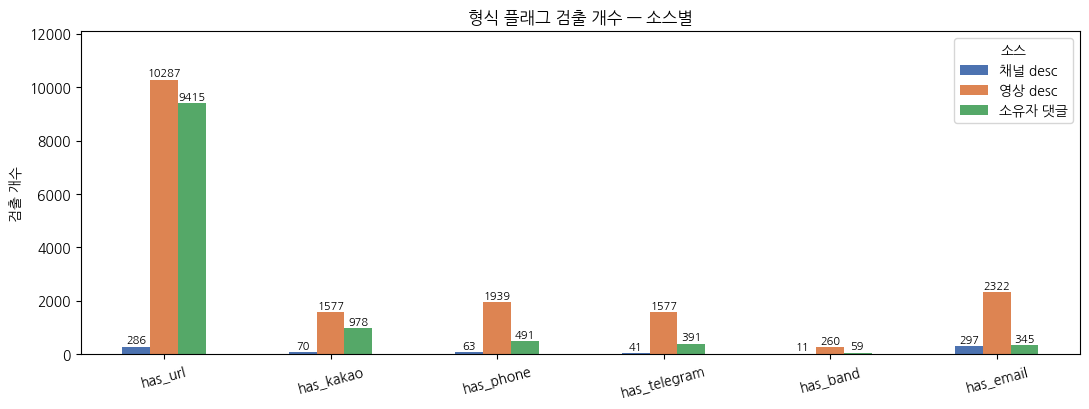


[채널 desc — 플래그별 상위 3 (구독순)]
      플래그                                       채널명                매칭
     has_url                              삼프로TV 3PROTV            https://
     has_url                                   한국경제TV            https://
     has_url                           MTN 머니투데이방송            https://
   has_kakao                                   한국경제TV        pf.kakao.com
   has_kakao                                      E트렌드        pf.kakao.com
   has_kakao                              존리의 부자학교        pf.kakao.com
   has_phone                              삼프로TV 3PROTV       010-2090-6748
   has_phone                    글로벌투자 - 슈퍼개미군단       010-5174-8880
   has_phone                          김종갑의 경제부동산       010-2626-6276
has_telegram                                   달팽이주식               t.me/
has_telegram                         하창봉 ㅣ 주식클라쓰               t.me/
has_telegram                       Oneriver 원리버 강하나               t.me/
    has_band                     _주린

In [20]:
# 형식 regex
contact_pats = {
    'has_url'     : r'https?://|www\.',
    'has_kakao'   : r'open\.kakao\.com|pf\.kakao\.com|kko\.to|kakao\.com/',
    'has_phone'   : r'01[016789][-.\s]?\d{3,4}[-.\s]?\d{4}',
    'has_telegram': r't\.me/|telegram\.me/|telegram\.org',
    'has_band'    : r'band\.us',
    'has_email'   : r'[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}',
}
def contact_flags(text):
    s = text.fillna('').astype(str)
    return pd.DataFrame({k: s.str.contains(p, case=False, regex=True) for k, p in contact_pats.items()})

# 소유자 본인 댓글: 댓글 작성자 핸들(@xxx) == 채널 핸들(custom_url) → 채널 주인이 자기 영상에 직접 단 댓글. 시청자 댓글 URL은 채널 행동 아님 → 제외
ch_handle = df_channels[['channel_id', 'custom_url']].copy()
ch_handle['handle'] = ch_handle['custom_url'].fillna('').astype(str).str.lstrip('@').str.lower()
cmt = df_comments.merge(ch_handle[['channel_id', 'handle']], on='channel_id', how='left')
cmt['author_handle'] = cmt['author'].fillna('').astype(str).str.lstrip('@').str.lower()
owner_cmt = cmt[(cmt['handle'] != '') & (cmt['author_handle'] == cmt['handle'])]
print(f'전체 {len(cmt):,} 중 소유자 본인 댓글 {len(owner_cmt):,}개({len(owner_cmt)/len(cmt)*100:.1f}%), {owner_cmt["channel_id"].nunique():,}개 채널')

# 세 소스 각각에 형식 플래그 적용
vflag = contact_flags(df_videos['description'])
cflag = contact_flags(df_channels['description'])
oflag = contact_flags(owner_cmt['text'])

# 각 소스에서 플래그가 검출된 개수(분모: 채널 desc 2,508 / 영상 desc 34,162 / 소유자 댓글 53,157)
flag_order = ['has_url', 'has_kakao', 'has_phone', 'has_telegram', 'has_band', 'has_email']
src_n = pd.DataFrame({
    '채널 desc' : cflag.sum(),
    '영상 desc' : vflag.sum(),
    '소유자 댓글': oflag.sum(),
}).loc[flag_order]

fig, ax = plt.subplots(figsize=(11, 4.2))
src_n.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452', '#55a868'])
ax.set_title('형식 플래그 검출 개수 — 소스별')
ax.set_ylabel('검출 개수')
ax.tick_params(axis='x', rotation=15); ax.legend(title='소스')
for cont in ax.containers:
    ax.bar_label(cont, fmt='%d', fontsize=8, padding=1)
ax.set_ylim(top=ax.get_ylim()[1] * 1.12)
plt.tight_layout(); plt.show()

# 소스×플래그별 상위 3 예시(구독순) — 채널명 + 검출 플래그 + 실제 매칭 문자열 직접 확인용
import re
_sub   = df_channels.set_index('channel_id')['subscriber_count']
_title = df_channels.set_index('channel_id')['title']
def examples_df(texts, cids, flagdf, k=3):
    base = pd.DataFrame({'cid': list(cids), 'text': list(texts)})
    base['sub']   = base['cid'].map(_sub).fillna(0)
    base['title'] = base['cid'].map(_title).fillna('?')
    rows = []
    for flag, pat in contact_pats.items():
        hit = base[flagdf[flag].values].sort_values('sub', ascending=False).drop_duplicates('cid').head(k)
        for _, r in hit.iterrows():
            m = re.search(pat, str(r['text']), re.I)
            rows.append({'플래그': flag, '채널명': str(r['title']), '매칭': (m.group(0) if m else '')})
    return pd.DataFrame(rows)

for nm, tx, ci, fd in [('채널 desc', df_channels['description'], df_channels['channel_id'], cflag),
                       ('영상 desc', df_videos['description'], df_videos['channel_id'], vflag),
                       ('소유자 댓글', owner_cmt['text'], owner_cmt['channel_id'], oflag)]:
    with pd.option_context('display.unicode.east_asian_width', True, 'display.width', 250, 'display.max_colwidth', 120):
        print(f'\n[{nm} — 플래그별 상위 3 (구독순)]')
        print(examples_df(tx, ci, fd).to_string(index=False))

# 채널 단위(채널 desc OR 영상 desc OR 소유자 댓글 중 하나라도) → 4-4 channel_features 전달
def channel_any(col):
    parts = [
        cflag[col].set_axis(df_channels['channel_id']),
        vflag.assign(channel_id=df_videos['channel_id']).groupby('channel_id')[col].any(),
        oflag.assign(channel_id=owner_cmt['channel_id']).groupby('channel_id')[col].any(),
    ]
    return pd.concat(parts, axis=1).reindex(df_channels['channel_id']).fillna(False).any(axis=1)

chan_flags = pd.DataFrame({c: channel_any(c) for c in contact_pats})
chan_flags.index.name = 'channel_id'

##### 3-2-9 보조 — 형식 플래그를 어떻게 쓸까  *(② 사용 인사이트)*
참여율·도배율과 교차해 판별력 점검.

위 보조셀(플래그별 지표 정렬·분포·요약 매트릭스) 종합. **보유÷미보유 중앙값 비율**(★=Mann-Whitney p<0.01, 댓글≥10 · 965채널):

| 플래그 | 참여율 | 좋아요율 | author_uniq | text_uniq | 댓글수 | 조회 | 구독 |
|---|---|---|---|---|---|---|---|
| `has_url` | 2.26★ | 2.49★ | 1.09 | 0.96★ | 4.17★ | 2.17★ | 18.4★ |
| `has_kakao` | 1.63★ | 0.79★ | **0.78★** | 0.94 | 0.77 | **0.58★** | 1.33 |
| `has_phone` | 1.23 | 1.61★ | 1.05 | 0.87★ | 1.73 | 1.31 | 9.68★ |
| `has_telegram` | 1.38 | 1.78★ | 1.10 | 0.86★ | 1.36 | 1.23 | 5.67★ |
| `has_band` | 0.36 | 1.92 | 1.04 | 0.90 | 0.53 | 0.64 | 2.48 |
| `has_email` | 1.00 | 1.65★ | 1.22★ | 1.05★ | 6.16★ | 3.15★ | 10.3★ |

**핵심 발견**
- **presence(있다/없다) 단독 라벨로 쓰면 안 됨.** `has_url`·`has_email`·`has_phone`·`has_telegram` 보유군은 구독 5~18배★·조회 2~3배★ = **대형 정상 채널 마커**. 즉, "링크 있으면 리딩방" = 오탐 폭발(구독순 top10 = 삼프로TV·한국경제TV 정상 채널).
- **`has_kakao` = 6개 중 유일하게 의심 방향으로 갈림.** 혼자만 author_uniq **0.78★**(보유군이 도배 심함)·조회 **0.58★**·구독 작음인데 참여율 1.63★ = *작고·반응(좋아요) 약하고·댓글만 많고·소수 도배* = 리딩방 시그니처. 카톡=유료방 유입 핵심 수법과 부합 → H1 가중 최우선.
- **`has_phone`·`has_telegram` = 보조 신호.** text_uniq 0.86~0.87이나 구독도 크기 때문에 단독 라벨로 사용은 어려움.
- **`has_band` = 노이즈.** 40채널만 나옴 → 폐기 후보.

**사용 방침**
- 모델 **feature로만 투입, 단독 컷 금지** — regex≠ML 원칙의 실증(presence만으론 대부분 규모 신호라 정상/리딩방 안 갈림).
- **상호작용이 본질**: 플래그 × 소형(저구독) × 참여율↑ × author_uniq↓. 보조셀에서 참여율로 정렬하니 삼프로 대신 "내일급등주"가 뜬 게 이 조합 효과 → `has_kakao_and_small`·`flag × author_uniq` 류 **파생 feature**가 판별력↑.
- `has_url`·`has_email`은 사실상 **대형 정상 채널 프록시** → 의심 신호가 아니라 정상 쪽 hint

**한계**: 위는 **라벨 전 EDA 방향성** — 판별력 확정은 시드라벨 후 H1 계수·base-rate로.

정렬 기준 = med_like_rate (오름차순), 댓글 >= 10개, 플래그 보유 채널 상위 5


,title,subscriber_count,med_like_rate,comment_n,author_uniq,med_comment_rate
0,알렉스강,5430,0.000000,92.000000,0.597800,0.000600
1,주식장인,354000,0.000000,9558.000000,0.462900,0.004700
2,초보주식 길라잡이,10,0.000000,19.000000,0.157900,0.009100
3,초보탈출 인생역전 주식투자,1,0.000000,17.000000,0.176500,0.021500
4,알파폴리오 : 주식 시장을 이기는 포트폴리오,1050,0.000000,219.000000,0.607300,0.003900


,title,subscriber_count,med_like_rate,comment_n,author_uniq,med_comment_rate
0,【FX마진거래】최승현,5,0.000000,12.000000,0.083300,0.018500
1,해외선물 yteamtv,31,0.000000,20.000000,0.050000,0.008400
2,무백딴 코인 선물 방송,2580,0.000000,135.000000,0.985200,0.011000
3,고수들,2880,0.000000,12.000000,0.166700,0.009000
4,주식정책,5,0.000000,14.000000,0.214300,0.001700


,title,subscriber_count,med_like_rate,comment_n,author_uniq,med_comment_rate
0,아이엠급등주,0,0.000000,11.000000,0.090900,0.333300
1,빵터질주식,16100,0.000000,20.000000,0.050000,0.035400
2,주식투자 전문채널 이음 TV,12600,0.001100,23.000000,0.478300,0.000000
3,YouTube해외주식정보,959,0.003600,59.000000,0.067800,0.002200
4,주식 해피엔딩 시나리오,20300,0.005900,27.000000,0.185200,0.001200


,title,subscriber_count,med_like_rate,comment_n,author_uniq,med_comment_rate
0,주식장인,354000,0.000000,9558.000000,0.462900,0.004700
1,대성단타_부업으로 단타매매,2040,0.000000,19.000000,0.052600,0.100000
2,도깨비밸류,3050,0.000000,198.000000,0.161600,0.034200
3,미주놀 - 미국.주식.시장에서 놀자,44300,0.000000,426.000000,0.136200,0.007500
4,김형철의 강철주식,2230,0.000000,96.000000,0.489600,0.010200


,title,subscriber_count,med_like_rate,comment_n,author_uniq,med_comment_rate
0,재테크연구소,15,0.000000,12.000000,0.583300,0.000000
1,비상장주식 공모주[IPO] 기업분석 아레테팁스,13200,0.006900,13.000000,0.153800,0.000700
2,보물주식연구소,623,0.012400,22.000000,0.363600,0.000700
3,주식용사부,39600,0.015000,44.000000,0.727300,0.000200
4,만천개미주식차트연구소,229,0.016400,17.000000,0.529400,0.000000


,title,subscriber_count,med_like_rate,comment_n,author_uniq,med_comment_rate
0,차트프로,274000,0.000000,1774.000000,0.701800,0.000700
1,공부하는투자 케빈쌤,14900,0.000000,31.000000,0.483900,0.000300
2,라이프닥터TV_경제와 투자 이야기,49200,0.000000,80.000000,0.887500,0.000200
3,미주놀 - 미국.주식.시장에서 놀자,44300,0.000000,426.000000,0.136200,0.007500
4,냥이의 주식핥기,305,0.000000,25.000000,0.360000,0.000000


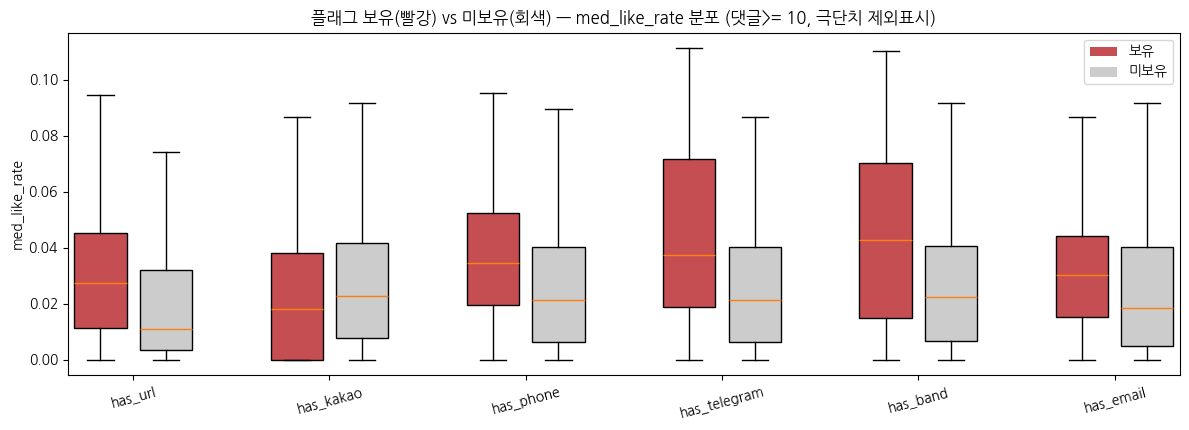

,참여율,좋아요율,author_uniq,text_uniq,댓글수,조회,구독
has_url,★2.26 p=5.2e-10,★2.49 p=2.9e-11,1.09 p=0.150,★0.96 p=4.8e-05,★4.17 p=4.0e-30,★2.17 p=3.3e-10,★18.40 p=1.6e-34
has_kakao,★1.63 p=4.3e-05,★0.79 p=6.5e-04,★0.78 p=0.002,0.94 p=0.014,0.77 p=0.837,★0.58 p=0.002,1.33 p=0.413
has_phone,1.23 p=0.257,★1.61 p=2.3e-05,1.05 p=0.835,★0.87 p=1.1e-05,1.73 p=0.044,1.31 p=0.141,★9.68 p=2.8e-10
has_telegram,1.38 p=0.106,★1.78 p=1.2e-06,1.10 p=0.271,★0.86 p=2.4e-06,1.36 p=0.080,1.23 p=0.154,★5.67 p=4.1e-07
has_band,0.36 p=0.464,1.92 p=0.076,1.04 p=0.770,0.90 p=0.440,0.53 p=0.494,0.64 p=0.589,2.48 p=0.628
has_email,1.00 p=0.877,★1.65 p=1.2e-08,★1.22 p=1.4e-04,★1.05 p=1.2e-04,★6.16 p=7.7e-23,★3.15 p=2.7e-20,★10.30 p=1.7e-23


In [21]:
# === 3-2-9 보조 확인용 === 연락처 플래그 보유 채널을 '구독수 말고' 참여율·도배율 등 다른 기준으로 정렬해 눈으로 확인
# (EDA 탐색 전용 — 4-4 정식 집계와 무관, 원본 미수정)

# 보는 법: 표 = 플래그 보유 채널을 rank_by 기준 상위 k개. 그래프 = 같은 지표의 보유(빨강) vs 미보유(회색) 분포.
#          빨강 박스가 위로(참여율↑) 또는 아래로(도배 author_uniq↓) 갈리면 그 플래그가 의심 신호와 연관된다는 뜻.
from IPython.display import display

# 채널 단위 참여·행동 지표
_v = df_videos.copy()
_v['like_rate']    = _v['like_count']    / _v['view_count'].replace(0, np.nan)   # 좋아요/조회수 = 호응도
_v['comment_rate'] = _v['comment_count'] / _v['view_count'].replace(0, np.nan)   # 댓글수/조회수 = 참여율
vch = _v.groupby('channel_id').agg(
    med_view         =('view_count', 'median'),
    med_like_rate    =('like_rate', 'median'),
    med_comment_rate =('comment_rate', 'median'),
    n_videos         =('video_id', 'size'),
)
_cg = df_comments.groupby('channel_id')
_cn = _cg.size()
cch = pd.DataFrame({
    'comment_n'  : _cn,
    'author_uniq': _cg['author'].nunique() / _cn,   # ↓ = 소수 도배
    'text_uniq'  : _cg['text'].nunique()   / _cn,   # ↓ = 복붙
})
prof = (df_channels.set_index('channel_id')[['title', 'subscriber_count']]
        .join(vch).join(cch))

# 지표 뜻(전부 영상 규모=조회수로 보정한 비율이라 큰 채널·작은 채널 비교 가능):
#   med_comment_rate = 댓글 참여율(영상별 댓글수/조회수의 채널 중앙값)
#   med_like_rate    = 시청자 호응도(영상별 좋아요/조회수의 채널 중앙값)
#   author_uniq      = 고유 작성자수/댓글수 (↓일수록 소수가 도배) | text_uniq = 고유 텍스트수/댓글수 (↓일수록 복붙)

# ── 여기만 바꿔서 다른 기준으로 확인 ──
rank_by   = 'med_like_rate'   # 후보: med_comment_rate / med_like_rate / author_uniq / text_uniq / comment_n / med_view / subscriber_count
ascending = True                # author_uniq·text_uniq(낮을수록 도배 의심)은 True로
k         = 5
min_comment_n = 10               # 비율 신뢰 위해 댓글 최소(3-2-8 임계)
# ───────────────────────────────────

cols = list(dict.fromkeys(['title', 'subscriber_count', rank_by, 'comment_n', 'author_uniq', 'med_comment_rate']))
print(f'정렬 기준 = {rank_by} ({"오름" if ascending else "내림"}차순), 댓글 >= {min_comment_n}개, 플래그 보유 채널 상위 {k}')
for flag in chan_flags.columns:
    has = chan_flags[flag].reindex(prof.index).fillna(False)
    enough = prof['comment_n'].fillna(0) >= min_comment_n
    sel = prof[has & enough].sort_values(rank_by, ascending=ascending).head(k)
    cap = f'[{flag}]  보유 {int(chan_flags[flag].sum())}채널 · 댓글>={min_comment_n} 필터 후 {int((has & enough).sum())}채널'
    if sel.empty:
        print(cap + '  → 조건 충족 채널 없음')
        continue
    # HTML 표로 렌더(한글·숫자 폭 폰트 의존 정렬깨짐 방지) — 채널명 좌측, 숫자 우측 자동정렬
    sty = (sel[cols].round(4).reset_index(drop=True).style
           .set_caption(cap)
           .set_properties(subset=['title'], **{'text-align': 'left'})
           .set_table_styles([{'selector': 'caption',
                               'props': [('font-weight', 'bold'), ('text-align', 'left'),
                                         ('padding', '6px 0'), ('font-size', '13px')]}]))
    display(sty)

# 그래프: 플래그 보유 vs 미보유 채널의 rank_by 분포 비교(댓글>= min_comment_n) — 플래그가 참여율·도배율과 갈리는지 한눈에
from matplotlib.patches import Patch
base = prof[prof['comment_n'].fillna(0) >= min_comment_n]
flags = list(chan_flags.columns)
data, positions, ticks = [], [], []
for i, flag in enumerate(flags):
    has = chan_flags[flag].reindex(base.index).fillna(False)
    h = base.loc[has,  rank_by].dropna()
    n = base.loc[~has, rank_by].dropna()
    data += [h.values if len(h) else [np.nan], n.values if len(n) else [np.nan]]
    positions += [i*3, i*3 + 1]
    ticks.append(i*3 + 0.5)

fig, ax = plt.subplots(figsize=(12, 4.4))
bp = ax.boxplot(data, positions=positions, widths=0.8, showfliers=False, patch_artist=True)
for j, box in enumerate(bp['boxes']):
    box.set_facecolor('#c44e52' if j % 2 == 0 else '#cccccc')
ax.set_xticks(ticks); ax.set_xticklabels(flags, rotation=15)
ax.set_ylabel(rank_by)
ax.set_title(f'플래그 보유(빨강) vs 미보유(회색) — {rank_by} 분포 (댓글>= {min_comment_n}, 극단치 제외표시)')
ax.legend([Patch(fc='#c44e52'), Patch(fc='#cccccc')], ['보유', '미보유'])
plt.tight_layout(); plt.show()

# 전체 지표 요약: 각 칸 = 비율(보유÷미보유 중앙값) + Mann-Whitney p값. 볼드 = p<0.01(차이 통계 유의)
from scipy.stats import mannwhitneyu
_mets = {'참여율': 'med_comment_rate', '좋아요율': 'med_like_rate', 'author_uniq': 'author_uniq',
         'text_uniq': 'text_uniq', '댓글수': 'comment_n', '조회': 'med_view', '구독': 'subscriber_count'}
_base = prof[prof['comment_n'].fillna(0) >= min_comment_n]
disp = pd.DataFrame(index=list(chan_flags.columns), columns=list(_mets), dtype=object)  # "★비율 \n p값" 문자열
for fl in chan_flags.columns:
    has = chan_flags[fl].reindex(_base.index).fillna(False)
    for sn, m in _mets.items():
        h = _base.loc[has, m].dropna(); n = _base.loc[~has, m].dropna()
        r = h.median() / n.median() if n.median() else np.nan
        try: p = mannwhitneyu(h, n).pvalue
        except ValueError: p = 1.0
        ptxt = f'p={p:.1e}' if p < 0.001 else f'p={p:.3f}'   # 위=비율, 아래=실제 p값(작을수록 유의)
        star = '★' if p < 0.01 else ''                        # ★ = p<0.01(유의), 비율 앞에 표시
        disp.loc[fl, sn] = f'{star}{r:.2f}\n{ptxt}'

# Styler = HTML 렌더 → 폰트와 무관하게 열 정렬 일정, 볼드도 CSS라 폭 안 깨짐
cap = (f'연락처 플래그별 — 위=비율(보유÷미보유 중앙값, &gt;1=보유 높음), 아래=Mann-Whitney p값, '
       f'★=p&lt;0.01(차이 통계적으로 유의·우연 아님)  (댓글&gt;={min_comment_n}, {len(_base)}채널)')
sty = (disp.style
       .set_caption(cap)
       .set_properties(**{'text-align': 'right', 'white-space': 'pre-line', 'line-height': '1.15'})
       .set_table_styles([{'selector': 'caption',
                           'props': [('font-weight', 'bold'), ('text-align', 'left'),
                                     ('padding', '8px 0'), ('font-size', '13px'),
                                     ('white-space', 'nowrap'), ('caption-side', 'top')]}]))
display(sty)


##### 3-2-10. 상호작용 파생 Attributes - 형식 플래그 × 행동·규모
**목적**: 3-2-9 결과로 형식 플래그는 단독으로 사용할 수 없는 변수. 따라서 의심 신호가 드러난 **카톡·소형·도배·참여율 교차** 상호작용으로 변수로 만듦 — 여기선 **생성만**, 상관·중복 점검은 4-4

**왜 이 변수들만?** (3-2-9 보조 Mann-Whitney 표 근거)
- 플래그×지표 = 6×7 = 42개지만 전부 생성X. 표에서 url·email·phone·telegram의 유의는 수동 확인했을 때 "대형 정상채널"도 많이 포함됨
- 따라서 **'의심' 방향 ★만 교차**: ① 카톡만 author_uniq 0.78★(작성자 소수 도배) ② phone·telegram text_uniq 0.86~0.87 ③ 참여율·소형 편중.
- `has_lure` 지표 생성 = `has_kakao`, `has_phone`, `has_telegram`, `has_band`
- `has_band`는 모든 지표 p>0.05(노이즈)라 단독 교차 제외, `has_lure_any` 합성에만 포함.

**왜 `has_lure_any`?** 개별 플래그(phone 72·telegram 84·band 13채널)는 표본이 작아 단독 통계가 불안정. 4개는 모두 **외부 채널로 끌어내는 같은 행위**(유료방·연락 유도). 단 카톡은 단독 신호가 가장 강해(author_uniq·조회 ★) `kakao_dobae`로 따로 분리, 나머지는 합쳐서 처리. url·email은 대형 정상채널 마커라 제외.

| 파생 | 정의 | 뜻 | 표 근거 |
|---|---|---|---|
| `kakao_dobae` | `has_kakao × (1 − author_uniq)` | 카톡 채널의 **작성자 소수 도배**도 | has_kakao author_uniq 0.78★ |
| `lure_textdup` | `has_lure_any × (1 − text_uniq)` | 유도 채널의 **텍스트 복붙 도배**도 | phone·telegram text_uniq 0.86★ |
| `lure_x_commentrate` | `has_lure_any × med_comment_rate` | 외부유도 + 높은 댓글참여 = **작전성 동원** 의심 | kakao 참여율 1.63★ |
| `lure_per_scale` | `has_lure_any ÷ log(구독+2)` | 같은 유도라도 **소형 채널일수록 ↑**(소형+유도 강조) | kakao 조회 0.58★(소형) |

**결론**: 4-4에서 기존 feature와 상관(다중공선성·중복) 확인 후 4-5에서 최종 선별(댓글·영상 없는 채널은 NaN → 4-4 결측 처리)


In [22]:
_vc = df_videos.copy()
_vc['comment_rate'] = _vc['comment_count'] / _vc['view_count'].replace(0, np.nan)
_mcr  = _vc.groupby('channel_id')['comment_rate'].median()
_cg2  = df_comments.groupby('channel_id')
_n2   = _cg2.size()
_au   = _cg2['author'].nunique() / _n2                                              # author_uniq (↓=소수 도배)
_tu   = _cg2['text'].nunique()   / _n2                                              # text_uniq   (↓=복붙 도배)
_subs = df_channels.set_index('channel_id')['subscriber_count']

has_kakao = chan_flags['has_kakao']
has_lure  = chan_flags[['has_kakao', 'has_phone', 'has_telegram', 'has_band']].any(axis=1)  # 순수 외부유도(url·email 제외)
idx = chan_flags.index

interact = pd.DataFrame(index=idx)
interact['kakao_dobae']        = has_kakao.astype(int) * (1 - _au.reindex(idx))            # 카톡 × 작성자 도배도
interact['lure_textdup']       = has_lure.astype(int)  * (1 - _tu.reindex(idx))            # 유도 × 복붙 도배도
interact['lure_x_commentrate'] = has_lure.astype(int)  * _mcr.reindex(idx)                 # 유도 × 참여율
interact['lure_per_scale']     = has_lure.astype(int)  / np.log1p(_subs.reindex(idx) + 1)  # 유도 / log(구독+2), 소형강조
interact.index.name = 'channel_id'

with pd.option_context('display.unicode.east_asian_width', True, 'display.width', 200):
    print('[3-2-10 상호작용 파생 — describe]')
    print(interact.describe(percentiles=[.5, .9, .99]).round(4))
print('\n비0(>0) 채널 수 (신호 있는 채널):')
print((interact.fillna(0) > 0).sum().to_string())


[3-2-10 상호작용 파생 — describe]
       kakao_dobae  lure_textdup  lure_x_commentrate  lure_per_scale
count    1575.0000     1575.0000           2348.0000       2508.0000
mean        0.0635        0.0433              0.0023          0.0543
std         0.2000        0.1337              0.0288          0.1825
min         0.0000        0.0000              0.0000          0.0000
50%         0.0000        0.0000              0.0000          0.0000
90%         0.1864        0.1429              0.0006          0.1269
99%         0.8667        0.7154              0.0362          0.9102
max         0.9500        0.9000              1.0000          1.4427

비0(>0) 채널 수 (신호 있는 채널):
kakao_dobae           168
lure_textdup          253
lure_x_commentrate    258
lure_per_scale        496


##### 3-2-11. 텍스트 내용(NLP) 탐색 - 텍스트 Attributes
**목적**: 3-2-7(길이)·3-2-9(형식)을 넘어 텍스트 *내용* 자체 탐색. 소스별로 (1) 어떤 단어가 자주 나오나(빈출 어휘·어휘 규모), (2) 댓글 복붙·동일 작성자 반복 = 도배/봇 정황, (3) 수집 검색어가 본문 상위에 끼는 정도 → 이후 NLP feature 설계와 leakage 차단 근거 마련. 대상 = 채널 `title`·`description`, 영상 `title`·`description`, 댓글 `author`·`text`.

**방법**: 형태소 분석기(konlpy) 없이 2글자 이상 토큰(한글·영문·숫자) 단순 토큰화 → 소스별 상위 빈출 토큰·고유어휘·어휘다양도(TTR=고유어휘/전체토큰). 댓글은 동일 `text` 복붙 비율·동일 `author` 반복으로 도배 점검. *조사 붙은 토큰이 그대로 잡히는 한계*는 감안(EDA 수준 탐색).

**결과**

| 소스 | 전체토큰 | 고유어휘 | TTR | 메모 |
|---|---|---|---|---|
| 채널 title | 5,140 | 3,221 | 0.63 | 짧음·채널명 위주, 변별 약 |
| 채널 description | 114,916 | 24,531 | 0.21 | 소개문, 상위에 `주식투자`·`코스피` 등장 |
| 영상 title | 334,281 | 53,913 | 0.16 | 종목·시황 키워드 밀집 |
| 영상 description | 2,451,268 | 164,039 | **0.07** | TTR 최저 = 고정 템플릿·해시태그·구독유도 복붙 多 |
| 댓글 text | 4,290,797 | 718,692 | 0.17 | 어휘 최대지만 복붙 19.2% |

- **수집 검색어 누수 확인**: 채널 desc 상위50에 `주식투자`·`코스피` = 수집 키워드가 본문에 직접 노출 → 텍스트를 그대로 feature화하면 약한 라벨 누수. 4-4 TF-IDF서 수집검색어 substring 제거가 필수임을 재확인.
- **영상 desc TTR 0.07**: 같은 문구(해시태그·구독·알림·외부유도 안내)를 영상마다 복붙 → 리딩방 정형 멘트 단서. 의미축(`desc_pca`)으로 압축할 가치.
- **댓글 도배 정황**: text 중복 19.2%(복붙 Top = `감사합니다`류 응원+자동성 혼재), 동일 작성자 최다 4,288회 = 봇/도배 후보. 내용 자체보다 **고유율**(`text_uniq`·`author_uniq`)이 신호.

**결론 — 4 전처리 연결**

| 텍스트 속성 | 4에서 처리 | 근거 |
|---|---|---|
| 채널 `title` | Retention(원값), NLP feature 미사용 | 결측0·짧음, 채널명이라 변별 약 |
| 채널 `description` | 4-1 Retention 보존, feature화 안 함 | 12.4% 빈값·자유텍스트, 누수 위험 |
| 영상 `title` | Retention(원값) | 결측0 |
| 영상 `description` | 4-4 **TF-IDF→PCA** 의미축(`desc_pca`), 수집검색어 substring 제거 | 핵심 NLP feature·정형멘트 신호 |
| 댓글 `text` | 4-4 채널집계 `text_uniq`(고유율), 내용 직접 미사용 | 복붙 19.2% = 도배축 |
| 댓글 `author` | 4-4 채널집계 `author_uniq`, 동일작성자 반복=도배 | 봇/도배 신호 |
| 수집검색어·규제어 | **leakage-제외**(feature 금지, 평가·prior만) | 약한 라벨, 본문서 직접 노출 확인 |


=== 소스별 어휘 규모 (2글자+ 토큰, 형태소분석기 미사용=조사 포함) ===
채널 title         전체토큰     5,140 / 고유어휘   3,221 / 어휘다양도(TTR) 0.6267
채널 description   전체토큰   114,916 / 고유어휘  24,531 / 어휘다양도(TTR) 0.2135
영상 title         전체토큰   334,281 / 고유어휘  53,913 / 어휘다양도(TTR) 0.1613
영상 description   전체토큰 2,451,268 / 고유어휘 164,039 / 어휘다양도(TTR) 0.0669
댓글 text          전체토큰 4,290,797 / 고유어휘 718,692 / 어휘다양도(TTR) 0.1675

채널 desc 상위50 토큰 중 수집검색어와 일치: ['주식투자', '코스피']



댓글 text 중복비율 19.2% (고유 342,246 / 전체 423,522)
가장 많이 복붙된 댓글 text Top5:


  8499회 | 감사합니다
  2060회 | 감사합니다.
  1796회 | 상수
  1390회 | 알림신청합니다
  1206회 | ❤



동일 작성자 최다 댓글수 Top5 (도배/봇 후보):
  4288회 | @user-supertrader1
  2581회 | @주식달인되자
  1472회 | @oilprof
  1407회 | @profhalf
  1404회 | @김민수의같이투자


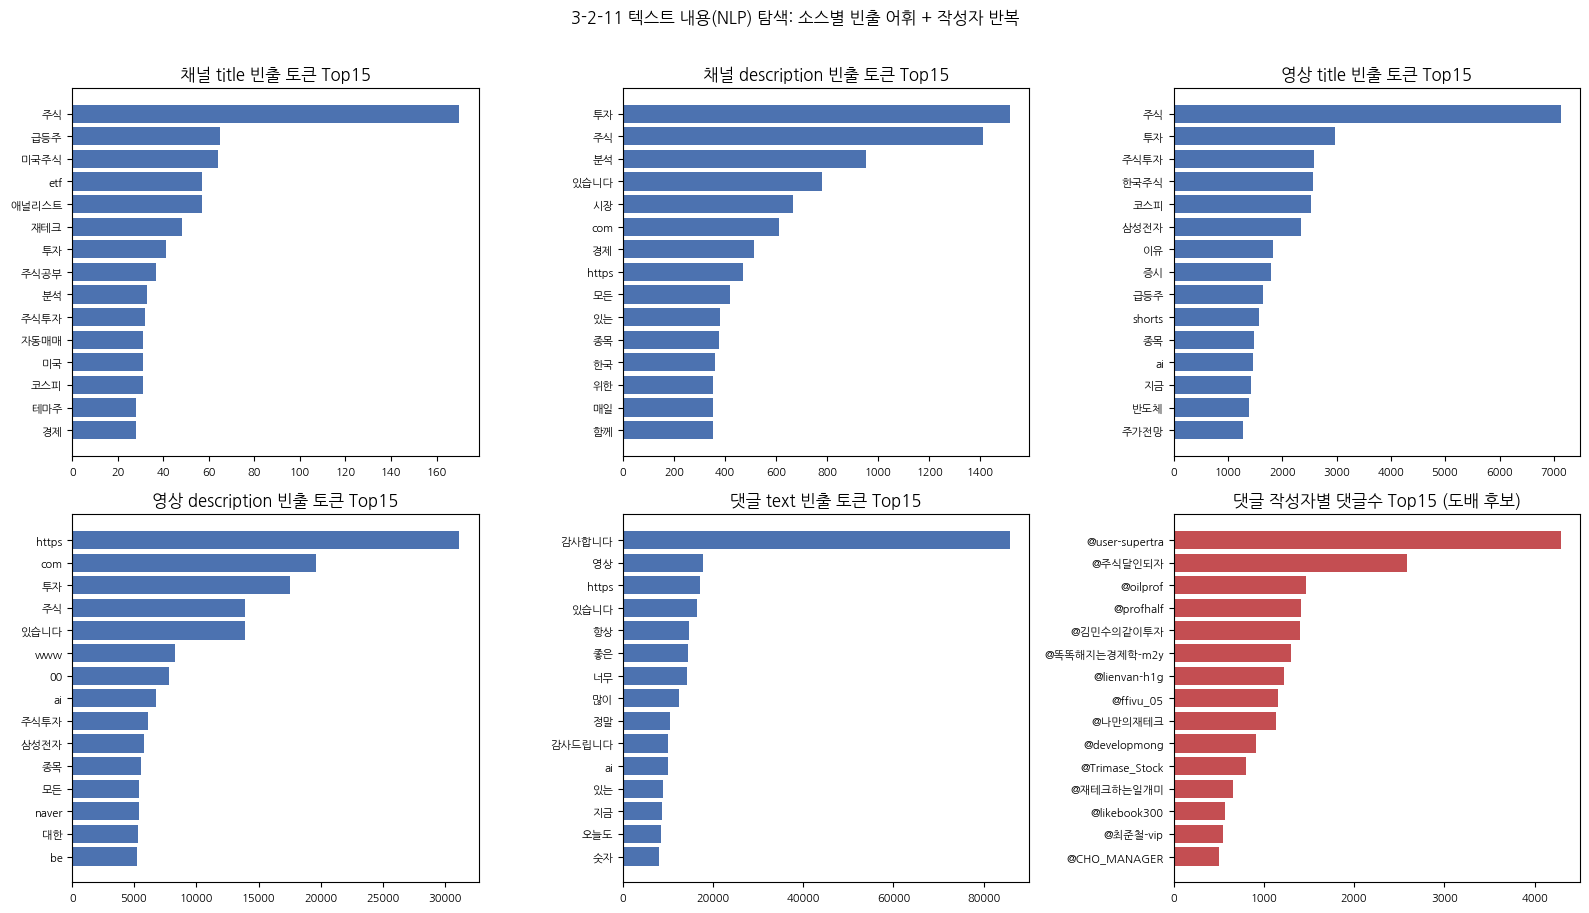

In [23]:
from collections import Counter
import re as _re
TOK = _re.compile(r'[가-힣a-z0-9]{2,}')

def tok_counter(series):
    c = Counter()
    for t in series.fillna('').astype(str):
        c.update(TOK.findall(t.lower()))
    return c

text_fields = {
    '채널 title'      : df_channels['title'],
    '채널 description': df_channels['description'],
    '영상 title'      : df_videos['title'],
    '영상 description': df_videos['description'],
    '댓글 text'       : df_comments['text'],
}
counters = {k: tok_counter(v) for k, v in text_fields.items()}

print('=== 소스별 어휘 규모 (2글자+ 토큰, 형태소분석기 미사용=조사 포함) ===')
for k, c in counters.items():
    tot = sum(c.values()); vocab = len(c)
    ttr = vocab / tot if tot else 0
    print(f'{k:16s} 전체토큰 {tot:>9,} / 고유어휘 {vocab:>7,} / 어휘다양도(TTR) {ttr:.4f}')

# 수집 검색어 30종(약한 라벨)이 본문 상위에 끼나 → feature 단계 leakage 경고 근거
SEARCH_QUERIES = ['주식리딩방','주식종목추천','급등주','수익률보장','오늘의추천주','무료리딩',
    '단타매매','주식자동매매','주식투자방법','테마주','주식대박','vip종목','주식투자','주식시장',
    '경제전망','기업분석','코스피','코스닥','주식시황','재테크','주식공부','애널리스트','etf투자',
    '미국주식','주식유튜브','주식방송','증권사리포트','개인투자자','주식초보','주식차트']
_q = set(SEARCH_QUERIES)
desc_top = [w for w, _ in counters['채널 description'].most_common(50)]
hit = [w for w in desc_top if w in _q]
print('\n채널 desc 상위50 토큰 중 수집검색어와 일치:', hit or '없음(부분토큰만 등장)')

# 댓글 도배 정황: 동일 text 복붙 + 동일 author 반복
_ct = df_comments['text'].fillna('').astype(str).str.strip()
dup_ratio = 1 - _ct.nunique() / len(_ct)
print(f'\n댓글 text 중복비율 {dup_ratio*100:.1f}% (고유 {_ct.nunique():,} / 전체 {len(_ct):,})')
print('가장 많이 복붙된 댓글 text Top5:')
for t, n in _ct[_ct.str.len() > 0].value_counts().head(5).items():
    print(f'  {n:>4}회 | {t[:40]}')
author_vc = df_comments['author'].fillna('').astype(str)
author_vc = author_vc[author_vc.str.len() > 0].value_counts()
print('\n동일 작성자 최다 댓글수 Top5 (도배/봇 후보):')
for a, n in author_vc.head(5).items():
    print(f'  {n:>4}회 | {a[:25]}')

# 시각화: 소스별 상위 15 토큰(5칸) + 작성자 반복(1칸)
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
axes = ax.ravel()
for a, (k, c) in zip(axes, counters.items()):
    items = c.most_common(15)[::-1]
    a.barh([w for w, _ in items], [n for _, n in items], color='#4c72b0')
    a.set_title(f'{k} 빈출 토큰 Top15'); a.tick_params(labelsize=8)
a6 = axes[5]
top_au = author_vc.head(15)[::-1]
a6.barh([s[:14] for s in top_au.index], top_au.values, color='#c44e52')
a6.set_title('댓글 작성자별 댓글수 Top15 (도배 후보)'); a6.tick_params(labelsize=8)
fig.suptitle('3-2-11 텍스트 내용(NLP) 탐색: 소스별 빈출 어휘 + 작성자 반복', y=1.01)
plt.tight_layout(); plt.show()

### **4. Data Pre-processing**
3-2에서 **진단**한 우편향·0-과잉·극단치·anomaly를 **처리**함

원시 데이터를 분석에 맞게 정제. **4-1 Missing → 4-2 Outlier → 4-3 Anomaly → 4-4 Exploring Patterns(원래 EDA 과정) → 4-5 feature 조립** 순.

**지배 원칙 2가지**

| 원칙 | 내용 |
|---|---|
| ① 다운스트림 정렬 | H1 분류·H2 군집/PCA·H3 검정이 요구하는 입력 보존·생성: log1p 스케일 보정 / 참여비율 feature / 범주 이진화 |
| ② Retention(삭제 최소) | outlier·anomaly = 타깃 신호일 수 있음(리딩방·봇·유령) → 삭제 X, **변환(log)·플래그**. 수집 오류로 판명된 것만 삭제 |

- 가설: **H1** 리딩방 분류 / **H2** 작전성 군집 분리 / **H3** 의심군 참여율 평균차.

#### 4-1. Missing data processing
**목적**: 3-2에서 찾아낸 실질 결측 바탕으로 결측 유형(MCAR/MAR/MNAR)을 판단해 전략(Retention/Deletion/Imputation) 고르기.

**방법**: 명시적 결측(SQLite NULL)과 숨은 결측(빈 문자열 `''`·공백)을 나눠 본다. 본 데이터는 NULL이 사실상 없고(예외 `parent_id`), 텍스트 결측은 전부 빈 문자열 형태 → 빈 문자열을 `NaN`으로 표준화해 드러낸 뒤 컬럼별 결측률·유형으로 전략 결정.

**(A) 실제 결측 = 빈 문자열** (NULL은 `parent_id` 외 전부 0%)

| 컬럼 (테이블) | 결측률 | 유형 | 전략 | 내용 |
|---|---|---|---|---|
| `description` (channel) | 12.4% | MNAR | **Retention**(원값 보존) | 빈 설명도 손실 없이 보존, 자유텍스트라 feature화 안 함 |
| `custom_url` (channel) | 1.6% | MNAR | **Retention**(원값 보존) | 소수, 핸들 매칭 보조(3-2-9) |
| `country` (channel) | 44.9% | MAR | **Imputation** → `is_kr` | KR 여부 이진 인코딩, 결측=비KR/미상(0)으로 대치 |
| `language` (channel) | 96.7% | MAR | **Deletion(열 삭제)** | 거의 전부 결측 → 정보 없음 |
| `description` (video) | 10.4% | MNAR | **Retention**(원값 보존) | 비결측 설명을 4-4서 **TF-IDF+PCA 의미 feature**로 사용(빈 desc는 해당 영상만 빠짐) |
| `text`·`author` (comment) | 0% | — | 처리 없음 | 빈값 없음(확인용) |

**(B) 결측 아님 — 혼동 방지** (0·구조적 빈값을 결측으로 오해하지 않도록 명시)

| 컬럼 (테이블) | 값 | 결측 아닌 이유 | 전략 |
|---|---|---|---|
| `parent_id` (comment) | NULL 71.9% | 최상위 댓글은 정의상 부모 없음(구조적) | 대댓글 비율 `reply_rate`는 4-4 조립에서 `parent_id`로 산출 |
| `like_count` (comment) | 0이 48.6% | 좋아요 0 = 진짜 0(미집계 아님) | 0/비0 분포는 4-2 outlier에서 다룸 |
| `subscriber/view/comment_count` (channel·video) | 0 다수 | 0 = 실제 0 또는 미집계 → 결측 아님 | 분포·이상치 4-2, 유령/비활성은 4-3서 차단(삭제) |

**결론**
- **Deletion**: `language`만(96.7% 결측).
- **Imputation**: `country→is_kr`만 사용.
- **Retention**(원값 보존): 나머지(`description` 채널·영상, `custom_url`)는 원값 그대로 보존. 영상 `description`은 4-4서 TF-IDF+PCA로 의미 feature화.
- 0값이 많지만 결측 아닌 3개 컬럼(B)은 4-1서 처리하지 않음. 행동 feature(`reply_rate` 등)는 4-4 조립에서, 분포/이상치는 4-2·4-3에서 다룸.
- **수치형 Imputation 미사용**: 수치형 명시 결측 0이고, 평균/중앙 대치는 강한 우편향을 왜곡하기 때문에. 범주형(`country`)만 '미상=비KR(0)'으로 대치(is_kr)


In [24]:
# (A) 실제 결측 점검 ----------------------------------------------------
# (1) 명시적 결측(NULL): parent_id 외 전부 0인지 확인
print('=== (A-1) 명시적 결측 NULL ===')
print('channels:', df_channels.isnull().sum().sum(), '| videos:', df_videos.isnull().sum().sum(),
      '| comments(parent_id 제외):', df_comments.drop(columns=['parent_id']).isnull().sum().sum())

# (2) 숨은 결측: 문자열 컬럼의 빈 문자열('')·공백 비율 (strip 후 빈 것)
def empty_ratio(df, cols):
    return pd.Series({c: (df[c].astype(str).str.strip() == '').mean() * 100 for c in cols}).round(1)

print('\n=== (A-2) 숨은 결측: 빈 문자열 비율(%) ===')
print('[channels]'); print(empty_ratio(df_channels, ['description','custom_url','country','language']).to_string())
print('[videos]  '); print(empty_ratio(df_videos, ['description']).to_string())
print('[comments]'); print(empty_ratio(df_comments, ['author','text']).to_string(), '  (0% = 빈값 없음)')

# (B) 결측 아님(구조적·0값) 점검 --------------------------------------
print('\n=== (B-1) 구조적 NULL: comments.parent_id ===')
print(f"  parent_id NaN={df_comments['parent_id'].isna().mean()*100:.1f}% (= 최상위 댓글, 결측 아님)")
print('=== (B-2) 0값(결측 아님) 참고: ==0 비율(%) ===')
print(f"  comment like_count==0 {(df_comments['like_count']==0).mean()*100:.1f}% |",
      f"video comment_count==0 {(df_videos['comment_count']==0).mean()*100:.1f}% |",
      f"channel subscriber==0 {(df_channels['subscriber_count']==0).mean()*100:.1f}%")


=== (A-1) 명시적 결측 NULL ===
channels: 0 | videos: 0 | comments(parent_id 제외): 0

=== (A-2) 숨은 결측: 빈 문자열 비율(%) ===
[channels]
description    12.4
custom_url      1.6
country        44.9
language       96.7
[videos]  
description    10.4
[comments]


author    0.0
text      0.0   (0% = 빈값 없음)

=== (B-1) 구조적 NULL: comments.parent_id ===
  parent_id NaN=71.9% (= 최상위 댓글, 결측 아님)
=== (B-2) 0값(결측 아님) 참고: ==0 비율(%) ===
  comment like_count==0 48.6% | video comment_count==0 53.5% | channel subscriber==0 17.5%


In [25]:
# 결측 전략 적용 → 정제 프레임 ch/vd/cm 생성. 원본 df_*는 보존(미수정).
ch = df_channels.copy()
vd = df_videos.copy()
cm = df_comments.copy()

# ===== (A) 실제 결측 처리 — 강의 명명 전략(Retention / Deletion / Imputation) =====
# [description] (channel) MNAR → Retention: 원값 그대로 보존(빈 문자열 포함). 자유텍스트라 feature화 안 함
# [custom_url]  (channel) MNAR → Retention: 원값 보존(1.6% 소수, 핸들 매칭 보조 3-2-9)
#   ↑ 위 둘은 손대지 않음(df_channels 원형 유지)
# [country] MAR → Imputation: KR 여부 이진 인코딩, 결측(44.9%)은 비-KR/미상(0)으로 대치(범주형 결측 대치)
ch['is_kr'] = (ch['country'].fillna('').astype(str).str.strip().str.upper() == 'KR').astype(int)
# [language] MAR 96.7% 결측 → Deletion(열 삭제)
ch = ch.drop(columns=['language'])
# [description] (video) MNAR → Retention: 원값 보존, 4-4서 TF-IDF+PCA 입력으로 사용

# (B) 결측 아님(구조적 parent_id·0-과잉 like_count) → 4-1서 처리 안 함. 행동 feature는 4-4 조립서 parent_id로 직접 산출

print('[A] Deletion(language 열삭제) | Imputation(country→is_kr, =1 %.1f%%) | '
      'Retention(description·custom_url 채널 + description 영상 = 원값 보존)' % (ch['is_kr'].mean()*100))

[A] Deletion(language 열삭제) | Imputation(country→is_kr, =1 53.3%) | Retention(description·custom_url 채널 + description 영상 = 원값 보존)


#### 4-2. Outlier processing
**목적**: 단변량 분포의 극단값을 강의 전략(Retention/Deletion/Imputation)으로 처리. **flag 컬럼 양산이 아니라 전략 자체를 실행.**

**왜 삭제하지 않나 — Retention**: 강의 기준 = outlier가 타깃과 관련되면 보존이 필수(사기거래 GPS, 금융붕괴 경제지표 예시). 본 프로젝트 리딩방 탐지 = 동일 맥락 → 대형·극단 채널 삭제 = 타깃 삭제.

**탐지 방법**: 극심한 우편향 → 경계 선택 주의.

| 방법 | 적합성 | 이유 |
|---|---|---|
| Z-score | ✗ | 정규 가정, 평균·std가 극단치에 오염 → 경계 무의미 |
| raw IQR | ✗ | 우편향 → 정상 대형 채널까지 과검출 |
| **log1p 후 IQR** | ✓(보고용) | 대칭화 후 잔여 극단 점검 |

**처리 전략**

| 전략 | 적용 |
|---|---|
| **Imputation — Log Transformation** | `log1p`로 우편향 압축 → 모델 입력 표현 `log_*` 생성(전 관측 변환) |
| **Retention** | 원값 보존(삭제·대치 X). outlier = 타깃 신호 |
| **Deletion** | 수집오류만(`video_age_days<0`, 0개 → 4-3) |

**결과·결론**
- log1p+IQR 잔여 극단 = 규모/참여 변수 0~0.4%(log가 흡수). `comment_count`만 11.1%지만 이는 **outlier가 아니라 0-과잉**(댓글 0이 과반) = IQR 경계 산물 → `has_comments`(4-3)로 0/비0 분리해 다룸.

=== log1p+IQR 경계 밖 비율(%) — 보고용(삭제·flag X) ===
[channels] subscriber_count     0.0%  (log경계 -9.36~18.53)
[channels] video_count          0.2%  (log경계 -3.22~10.15)
[channels] view_count           0.0%  (log경계 -2.93~21.81)
[videos]   view_count           0.3%  (log경계 -1.21~12.84)
[videos]   like_count           0.4%  (log경계 -5.15~8.58)
[videos]   comment_count       11.1%  (log경계 -1.65~2.75)
[videos]   duration_seconds     0.0%  (log경계 -0.57~11.09)
Imputation(Log) 적용 → log_* 생성, 원값 Retention 보존. flag 미생성.


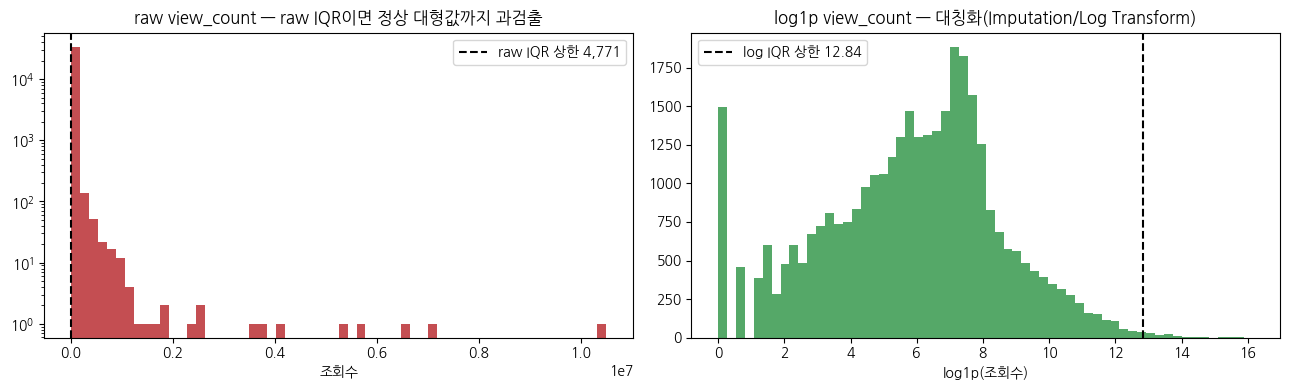

In [26]:
# 4-2 Outlier 처리 = 강의 전략 실행 (flag 컬럼 생성 X)
#   · Imputation/Log Transformation: 우편향 압축 → 모델 입력은 log1p 표현
#   · Retention: 원값 보존(삭제 X). 리딩방 outlier = 타깃 신호(강의 사기·금융붕괴 예시)
#   · Deletion: 수집오류만 → 4-3에서 video_age_days<0 처리
# IQR은 'log1p가 극단을 흡수했나' 보고용으로만 출력(영구 flag 아님).

def log_iqr_rate(s):
    """log1p 후 IQR 경계 밖 비율(%) — 보고용(처리 X). 우편향 보정 후 잔여 극단 점검."""
    sl = np.log1p(s.clip(lower=0))
    q1, q3 = sl.quantile(.25), sl.quantile(.75); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((sl < lo) | (sl > hi)).mean() * 100, (lo, hi)

ch_num = ['subscriber_count','video_count','view_count']
vd_num = ['view_count','like_count','comment_count','duration_seconds']

print('=== log1p+IQR 경계 밖 비율(%) — 보고용(삭제·flag X) ===')
for c in ch_num:
    r, (lo, hi) = log_iqr_rate(ch[c]); print(f'[channels] {c:18s} {r:5.1f}%  (log경계 {lo:.2f}~{hi:.2f})')
for c in vd_num:
    r, (lo, hi) = log_iqr_rate(vd[c]); print(f'[videos]   {c:18s} {r:5.1f}%  (log경계 {lo:.2f}~{hi:.2f})')

# Imputation: Log Transformation — 모델 입력용 log1p 표현 생성. 원값은 Retention으로 그대로 보존
for c in ch_num:
    ch[f'log_{c}'] = np.log1p(ch[c].clip(lower=0))
for c in vd_num:
    vd[f'log_{c}'] = np.log1p(vd[c].clip(lower=0))
print('Imputation(Log) 적용 → log_* 생성, 원값 Retention 보존. flag 미생성.')

# 시각화: raw(우편향, IQR 과검출) vs log1p(대칭화) — view_count 예시
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
s = vd['view_count'].clip(lower=0)
ax[0].hist(s, bins=60, color='#c44e52'); ax[0].set_yscale('log')
q1, q3 = s.quantile(.25), s.quantile(.75); raw_hi = q3 + 1.5 * (q3 - q1)
ax[0].axvline(raw_hi, color='k', ls='--', label=f'raw IQR 상한 {raw_hi:,.0f}')
ax[0].legend()
ax[0].set_title('raw view_count — raw IQR이면 정상 대형값까지 과검출'); ax[0].set_xlabel('조회수')
ax[1].hist(np.log1p(s), bins=60, color='#55a868')
_, (qlo, qhi) = log_iqr_rate(vd['view_count'])
ax[1].axvline(qhi, color='k', ls='--', label=f'log IQR 상한 {qhi:.2f}')
ax[1].set_title('log1p view_count — 대칭화(Imputation/Log Transform)'); ax[1].set_xlabel('log1p(조회수)'); ax[1].legend()
plt.tight_layout(); plt.show()

#### 4-3. Anomaly processing
**목적**: 정상 패턴 이탈 관측을 두 갈래로 처리 — (a) 타깃(리딩방) 신호인 **규칙 이탈**은 보존(수동 검증용 flag), (b) 타깃이 아닌 **무관·오류 표본**(유령/비활성·비주식·불가능값)은 강의 **Deletion(차단)**.

**방법**: outlier(4-2, *단변량 분포*의 극단)와 달리 anomaly는 *규칙·맥락*의 이탈. 본 모집단은 "30개 주식 검색어로 수집한 채널"이라, 죽은 채널·비주식 채널·물리적으로 불가능한 값은 분석 대상이 아니므로 제거(수집오류·무관표본 삭제). 리딩방 후보 자체를 지우는 게 아니므로 'anomaly=타깃 보존' 원칙과 충돌하지 않음.

**결과 + 처리**

| anomaly | 정의 | 판단 근거 | 처리 |
|---|---|---|---|
| 규칙 이탈 | 구독~조회 규칙선 이탈(4-4-3) | 작전성 후보 = 타깃 신호 | **Retention** — `is_rule_anomaly` flag 보존, **본인 수동 확인** |
| 유령/비활성 | 구독0&조회0 또는 영상0 | 콘텐츠 없는 죽은 채널 = 분석 무관 | **Deletion(차단)** — 행 삭제 |
| 비정상 참여 | `like_rate>1`(좋아요>조회) | 도메인지식상 물리적 불가능 = 데이터오류 | **Deletion** — 해당 영상 행 삭제 |
| 비주식 채널 | 주식/금융 주제 아님 | 모집단(주식 채널) 무관표본 | **Deletion(차단)** — 수동 검토 리스트로 제외 |

**결론**
- 규칙 이탈만 보존(flag), 유령/비활성·비주식·`like_rate>1`은 차단(삭제). 차단 대상은 전부 타깃(리딩방)이 아니라 죽은·무관·오류 표본 → 타깃 삭제 아님.
- 비주식 채널은 **수동 검증으로 비주식 채널을 삭제했다**: 금융어휘 횟수 임계·카테고리 키워드 자동 판별은 멀쩡한 주식채널을 오삭제(false positive)해 신뢰 불가(봇팜은 #주식 도배로 hit 과다, 정상 채널은 부분문자열·1회 언급으로 오분류). → 원본 DB 채널 2,508개 중 금융어휘 0회 후보 187개 전수 열람 + 비주식 주제어 보조 스캔, 모호 채널은 영상 제목까지 확인해 명백한 비주식 43개를 `NONSTOCK_EXCLUDE_IDS`에 직접 등록.
- **비주식 선정 기준(수동 검증)**: ① '리딩' 동음이의어 21개 — 독서·속독·영어교육(10)·타로(4)·파워볼/바카라/스포츠 베팅픽(6)·치어리딩(1). ② '애널리스트' 동음이의어 8개 — 데이터분석 SW·여행·맛집·게임. ③ 검색어 오염 서비스 14개 — 법무법인(3)·환불/피해복구(2)·보험(2)·부동산(3)·채용·간호 브이로그·더빙 코미디·범죄 스토리. 판정 원칙 = 주식 콘텐츠가 하나라도 확인되면 보존(보수적), 카카오톡/LINE 유도 봇 채널은 리딩방 후보(타깃)라 미삭제.
- **`view`=0 영상의 참여율은 0이 아니라 결측(NaN)**: `view`=0은 조회 미집계지 진짜 무반응이 아님(3-2-3 — view=0인데 댓글 184·좋아요 49 존재). 0으로 강제하면 채널 median(4-4)이 인위적으로 낮아져 정상/의심 구분을 흐림 → NaN으로 두고 median 집계에서 자동 제외.


In [27]:
import re
# ---- 4-3 anomaly 처리: Retention(타깃신호 보존) + Deletion(무관·오류표본 차단) ----
# 규칙이탈=보존(수동확인 flag) / 유령·비주식·like_rate>1=차단(삭제). 차단 대상은 리딩방 후보 아님.

# (1) 규칙 이탈 → Retention: 보존 flag(삭제 X, 수동 검증용). 규칙선 근거 시각화는 4-4-3
m = (ch['subscriber_count'] > 0) & (ch['view_count'] > 0)
ch['is_rule_anomaly'] = 0
xx, yy = np.log1p(ch.loc[m, 'subscriber_count']), np.log1p(ch.loc[m, 'view_count'])
coef = np.polyfit(xx, yy, 1); resid = yy - np.polyval(coef, xx)
ch.loc[m, 'is_rule_anomaly'] = (resid.abs() > 2.5 * resid.std()).astype(int)

# ---- 영상 파생 feature ----
vd_pub = pd.to_datetime(vd['published_at'], format='ISO8601', utc=True)
vd_col = pd.to_datetime(vd['collected_at'], format='ISO8601', utc=True)
vd['video_age_days'] = (vd_col - vd_pub).dt.total_seconds() / 86400   # 나이보정축(med_age_days용)

# 참여 비율: view==0은 미집계(진짜 0 아님, 3-2-3) → NaN으로 두고 집계서 제외(분모0 가드)
_view = vd['view_count'].replace(0, np.nan)
vd['like_rate']    = vd['like_count']    / _view
vd['comment_rate'] = vd['comment_count'] / _view

# (2) 비정상 참여 like_rate>1(좋아요>조회) → 도메인지식상 물리적 불가능 = 데이터오류 → Deletion
_bad_like = (vd['like_rate'] > 1).fillna(False)
print(f'like_rate>1(좋아요>조회=데이터오류) 영상 {int(_bad_like.sum())}행 삭제')
vd = vd[~_bad_like].copy()

vd['has_comments'] = (vd['comment_count'] > 0).astype(int)
# 업로드 시각대(KST, 3-2-5) → H3 시황민감도(장중 vs 장마감후)
_kst_hr = pd.to_datetime(vd['published_at'], format='ISO8601', utc=True).dt.tz_convert('Asia/Seoul').dt.hour
vd['is_market_hours'] = _kst_hr.between(9, 15).astype(int)
vd['is_after_market'] = _kst_hr.between(16, 20).astype(int)

# 채널 나이(3-2-6) → 성숙도 + 신생 flag(리딩방 신생 가설)
_ch_age = (pd.to_datetime(ch['collected_at'], format='ISO8601', utc=True)
           - pd.to_datetime(ch['published_at'], format='ISO8601', utc=True)).dt.total_seconds() / 86400
ch['channel_age_days'] = _ch_age
ch['is_new_channel'] = (_ch_age < 365).astype(int)

# (3) 유령/비활성(구독0&조회0 또는 영상0) → 콘텐츠 없는 죽은 채널 = 차단(Deletion)
_inactive = (((ch['subscriber_count'] == 0) & (ch['view_count'] == 0)) | (ch['video_count'] == 0))

# (4) 비주식 채널 → 모집단(주식) 무관표본 = 차단(Deletion). 자동 판별은 신뢰 불가
#     (금융어휘 횟수 임계·카테고리 키워드 모두 멀쩡한 주식채널을 오삭제 → false positive 확인됨).
#     → 수동 검토한 channel_id만 아래 리스트에 직접 등록해 제외.
#     검토 절차: ① 금융어휘(주식·투자·종목 등 30여 개) 0회 채널 187개 전수 열람
#     ② 비주식 주제어(타로·파워볼·바카라·속독·치어리딩 등) 보조 스캔으로 금융어휘 혼입 채널 보완
#     ③ 모호하면 영상 제목까지 직접 확인, 주식 콘텐츠가 하나라도 확인되면 보존(보수적 판정)
#     ④ 카카오톡/LINE 유도 봇 채널은 리딩방 후보(타깃)라서 절대 미삭제
NONSTOCK_EXCLUDE_IDS = [
    # -- '리딩(reading)' 동음이의어: 독서·속독·언어 교육 --
    'UCH85e61Xz0RUlFmOcMhsxvg',  # 국풍2000 국어로 & AI리딩플러스 (국어학원)
    'UCqNYNXT5m18-tx3xUBkbe1w',  # 글눈-리딩훈련소 (속독·문해력)
    'UCoCSHY3n2QDX_MUkDxrfCtw',  # 글눈 (속독)
    'UCr4MC7WKArV5XM9sgMs5CAQ',  # 빅데이터TV (속독법)
    'UCsMi0csPHPQW1tynn_zSjtQ',  # 리딩오션 (독서교육)
    'UCokTrkrZyALrJISgiiu5B0A',  # 리딩오션강남직영점 (독서교육)
    'UCOkFPBQbVbF1ttXwwVzU6vQ',  # 월산리딩톡영어학원 (영어학원)
    'UCTEtT13WaOXIrLNDcRAKFjw',  # 마커스랑원서읽기 (영어 원서)
    'UC5al__PZhWPULA1qdUAdkZQ',  # 리딩에듀 북트레일러연구소 (독서교육)
    'UCbn12fd1UbRb4itpgn8btnA',  # 추억의 오마이리딩 닷컴 (영어독해 강의)
    # -- '리딩' 동음이의어: 타로 리딩 --
    'UC32IOisFxLTONS6edpJWWkA',  # 타로 알려주는 남자
    'UCUT6QLUNgJ764bHq54Eapeg',  # 타로마스터 해피마인드
    'UCvD0GX34KF4OwXRzNZWL54A',  # 쭈네타로샵
    'UCxKnfs4QBV__RjbnYV1HTCQ',  # 달온타로
    # -- '리딩' 동음이의어: 도박 베팅픽(파워볼·바카라·스포츠) — 주식 아님 --
    'UCGp93uE1W_DKbWTMr67PGdA',  # 파워볼 마초 77
    'UC7r0Rk9Wxrwlv3JqnOquW6Q',  # 파워볼갓혜원
    'UCBhZR2hvP6DavEN9OvirgTQ',  # 파워볼 로켓라쿤
    'UC9muN_9QnO_WXDHdnlb2h8Q',  # 바카라 이박사
    'UCG3d5L5jrITuiYwkkQ08pNw',  # 스마트바카라
    'UCWYyDE5QmhkcpiS86P3h9IQ',  # 스포츠애널리스트 고난 (스포츠 베팅 분석)
    # -- '리딩' 동음이의어: 치어리딩 --
    'UChkeCtktdPBgWHzUO6npzbg',  # 치어리딩TV
    # -- '애널리스트' 동음이의어: 비금융 분석가·분석 SW --
    'UCeW5KeyHC1F9BGZr2Mq70cw',  # 금연석-트래블애널리스트 (여행·골프)
    'UCTbjbjpKeCQsfwijOjC7TCw',  # 이상우애널리스트 작은배려 (맛집)
    'UC44dEu_c74xrgXzO5u5Ox5A',  # League analyst 롤 애널리스트 (게임)
    'UCqfu282je1VmMZSOp3_a_lA',  # TDWI (데이터 교육)
    'UC28v2fdIYNdEwwrNoG3kP_w',  # Optelos (드론 데이터 SW)
    'UC8rqPN0uteSxNoCm_Nfy7Vw',  # Laplace (이커머스 분석 SaaS)
    'UCRvudwkTe1FeqUoWrbIIAMQ',  # PAP Product Analytics Playground (데이터 분석 커뮤니티)
    'UC1rNxByYgFxZCN6zpNYGWdA',  # Attributer (마케팅 트래킹 SW)
    # -- 검색어 오염: 주식 아닌 서비스·콘텐츠 채널 --
    'UCNuQUuYvjSaKNru9KBZ4HPw',  # 기업회생연구소 법무법인 스탠다드 (법률)
    'UCJq8suvyeU2xSJEAtfoDmFw',  # 더신사 법무법인 (법률)
    'UCnIdBdmGzpmcAZEJtML2yUw',  # 법무법인 주인 (법률)
    'UC5MH3rXK9uL9dxgBlZdvOwA',  # 환불대행 (환불 대행 서비스)
    'UC0LGVD_EzaN-Do87WzVF2_w',  # 아이디해킹당함 (사기 피해복구 대행)
    'UClJcIEW026nDsStsHQh80jg',  # 보장 인사이트 랩 (보험)
    'UCDLuHTLsJUoRreYMEyby8Nw',  # 보장은 최대로 보험료는 작게 (보험·토지)
    'UCPlhLEhcgFOXkcR-BAq_XLg',  # 집상담소 위드tv (빌라 중개)
    'UC6inuEkuN_Xq2sjfO8MLXeQ',  # 이상우 부동산 애널리스트 (부동산)
    'UC_uMY983S-vSFso0Fd3eN3w',  # 부동산장터TV (상가·토지 매물)
    'UCj-JS7C-gRUurFHv5Aq1OvQ',  # Bionote HR (채용)
    'UCFga1S51AvwWRm8mkkllSaw',  # Nurse Life Delhi (간호 브이로그)
    'UCKLD3f3Dx_--HZFCv4FXeuw',  # 네마리코믹스 (병맛더빙 코미디)
    'UCxri4ujNV5iiZ8nentzRPyA',  # 복덕방 커피 (일반 범죄·사기 스토리)
]

# (5) 차단 실행: 유령/비활성 ∪ 비주식(수동) → ch/vd/cm 전부에서 제거(일관 유지)
drop_ids = set(ch.loc[_inactive, 'channel_id']) | set(NONSTOCK_EXCLUDE_IDS)
ch = ch[~ch['channel_id'].isin(drop_ids)].copy()
vd = vd[~vd['channel_id'].isin(drop_ids)].copy()
cm = cm[~cm['channel_id'].isin(drop_ids)].copy()

print(f'차단: 유령/비활성 {int(_inactive.sum())}개 + 비주식 수동 {len(NONSTOCK_EXCLUDE_IDS)}개 '
      f'(중복제외 합 {len(drop_ids)}개) → 잔존 채널 {ch.shape[0]}개')
print('규칙이탈(보존·수동확인):', int(ch['is_rule_anomaly'].sum()),
      '| 영상', vd.shape[0], '| 댓글', cm.shape[0])

like_rate>1(좋아요>조회=데이터오류) 영상 19행 삭제


차단: 유령/비활성 252개 + 비주식 수동 43개 (중복제외 합 294개) → 잔존 채널 2214개
규칙이탈(보존·수동확인): 51 | 영상 32972 | 댓글 421987


#### 4-4. Exploring Patterns  *(원래 EDA 과정)*
3-2에서는 변수 *하나씩*(단변량) 봤다면, 여기서는 변수 *사이*의 관계를 파악

원래 EDA(3장)의 마지막 단계지만, 상관·다중공선성·규칙성은 **결측·이상치·이상(anomaly) 처리와 파생 변수 생성이 모두 끝난 최종 feature** 위에서 봐야 의미가 있으므로, 전처리(4-1~4-3) 뒤로 배치했다. 즉 여기서 보는 매트릭스 = 정제·플래그·파생까지 반영된 채널 단위 표.

속성 *간* 관계·추세·구조, 그리고 규칙에서 벗어나는 **이상(anomaly)** 단서를 탐색.

**3축**

| 축 | 보는 것 | 주의 |
|---|---|---|
| 4-4-1 공분산 | 동반 변화의 방향 | 단위 민감 → 부호만, 크기 비교 X |
| 4-4-2 상관 | 표준화(−1~+1) 선형 강도 | 상관 낮음 ≠ 무관계(비선형) → Spearman 병행 |
| 4-4-3 규칙성 | 추세·규칙 + 이탈 | 이탈 = 작전성·봇 anomaly 후보 |

##### 4-4 (입력 준비) 영상 설명 텍스트 feature — TF-IDF + PCA
영상 `description`은 텍스트라 모델이 직접 못 쓴다. 두 단계로 숫자 feature를 만든다.
1. **TF-IDF** (강의10 Text Analysis): 단어 빈도(TF) × 희소도(IDF)로 "이 채널 설명에서 어떤 단어가 특징적인가"를 수치 벡터로. 흔한 단어는 IDF가 눌러 약하게, 드물고 특징적인 단어는 강하게.
2. **PCA** (강의04 Regression — 다중공선성 대응 '변수 결합' 기법): TF-IDF는 단어 수천 개 = 변수 과다·서로 중복. PCA로 분산을 보존하며 **상관 없는 주성분 K개**로 압축해 채널 의미 feature로 만든다.

- **단위 맞춤**: 채널별로 그 채널 영상들의 설명을 한 문서로 합침(관측 단위 = 채널).
- **leakage 차단**: 수집 검색어 30종(`주식리딩방`·`급등주`·`수익률보장` …)은 *약한 라벨*이라 본문에서 substring으로 제거한 뒤 벡터화한다(규제어 직접 매칭 = 라벨 근거 → feature 금지 원칙). 즉 의미축은 '어떤 규제 키워드가 있나'가 아니라 '설명 글의 전반적 의미 결'을 잡는다.
- **한국어 처리**: 형태소 분석기(konlpy) 없이 2글자 이상 토큰(유니코드 단어, 한글 포함) 기준 TF-IDF. `min_df`·`max_df`로 너무 드물거나 흔한 토큰 제거.

*주의*: TF-IDF·PCA를 전체 채널로 fit = EDA 후보 feature 단계라 단순화한 것. 실제 H1 학습 때는 train fold 안에서 다시 fit해야 누수가 없다(4-5 StandardScaler 주의와 같은 맥락).

In [28]:
# 영상 설명(description) → 채널 단위 의미 feature: TF-IDF + PCA
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# 채널별로 영상 설명을 한 문서로 합침(채널 = 관측 단위). 빈 설명은 공백이라 토큰 안 생김
ch_desc_corpus = (vd.assign(_d=vd['description'].fillna('').astype(str))
                    .groupby('channel_id')['_d'].apply(' '.join))

# leakage 차단: 수집 검색어 30종 = 약한 라벨 → 본문에서 substring 제거(조사 붙어도 제거되도록)
SEARCH_QUERIES = ['주식리딩방','주식종목추천','급등주','수익률보장','오늘의추천주','무료리딩',
    '단타매매','주식자동매매','주식투자방법','테마주','주식대박','VIP종목','주식투자','주식시장',
    '경제전망','기업분석','코스피','코스닥','주식시황','재테크','주식공부','애널리스트','ETF투자',
    '미국주식','주식유튜브','주식방송','증권사리포트','개인투자자','주식초보','주식차트']
_leak_re = re.compile('|'.join(map(re.escape, sorted(SEARCH_QUERIES, key=len, reverse=True))))
corpus = ch_desc_corpus.str.replace(_leak_re, ' ', regex=True)

# (1) TF-IDF(강의10): sklearn 기본 token_pattern(2글자+ 유니코드 토큰, 한글 포함). 드문(min_df)·흔한(max_df) 토큰 제거
tfidf = TfidfVectorizer(max_features=3000, min_df=5, max_df=0.5)
X_tfidf = tfidf.fit_transform(corpus)

# (2) PCA(강의04 다중공선성→변수결합): 희소행렬을 dense로 변환 후 주성분 K개로 압축
K = min(8, X_tfidf.shape[1], X_tfidf.shape[0])
X_dense = X_tfidf.toarray()
pca = PCA(n_components=K, random_state=42)
desc_pca = pca.fit_transform(X_dense)
print(f'TF-IDF {X_tfidf.shape} (채널×어휘) → PCA {K}축, 누적 설명분산 {pca.explained_variance_ratio_.sum()*100:.1f}%')

chan_desc_pca = pd.DataFrame(desc_pca, index=corpus.index,
                             columns=[f'desc_pca_{i}' for i in range(K)])
display(chan_desc_pca.head(3))

TF-IDF (2206, 3000) (채널×어휘) → PCA 8축, 누적 설명분산 15.3%


,desc_pca_0,desc_pca_1,desc_pca_2,desc_pca_3,desc_pca_4,desc_pca_5,desc_pca_6,desc_pca_7
channel_id,,,,,,,,
UC---QNKc1l1dp4XmbnAi9lQ,-0.074791,0.044897,-0.049909,-0.087661,0.007397,0.071207,-0.078850,0.009685
UC--j6cf0rDlkD0Usdo7SBzg,-0.047638,-0.171631,0.291406,0.211017,0.123365,-0.018407,0.041730,0.019481
UC-03vNg7XzrcmpsaOOTZtUQ,-0.046657,-0.013419,0.002247,-0.133470,0.045043,-0.023111,-0.055279,0.011520


##### 4-4 채널 feature 매트릭스 조립 (패턴 탐색 입력)
상관·VIF·규칙성은 변수가 한 표(같은 관측 단위=채널)에 모여 있어야 잴 수 있다. 그래서 패턴을 보기 전에, 4-1~4-3에서 정제·플래그·파생까지 끝난 `ch`(채널)·`vd`(영상)·`cm`(댓글)을 **채널 단위 한 표(`channel_features`)** 로 합친다.

- 영상 참여지표(`med_view`·`med_like_rate`·`short_ratio`·시각대 비율 등)는 채널별 **중앙값**으로 집계(우편향이라 평균 대신).
- 댓글 행동(`author_uniq`·`text_uniq`·`reply_rate`·`comment_n`, 3-2-8), 연락처 플래그(3-2-9), 상호작용 파생(3-2-10), 첫댓글 시딩(`med_ttf_hours`)을 붙인다.
- 실제 **저장은 4-5**에서 하고, 여기서는 패턴 탐색용으로 메모리에만 만든다.

In [29]:
# ===== 채널 단위 feature 매트릭스 조립 (패턴 탐색 입력, 저장은 4-5) =====
# 4-1~4-3에서 정제·플래그·파생까지 끝난 ch/vd/cm 위에서 채널 단위로 합친다.

# 첫 댓글까지 시간 → 채널 median (시딩 신호, 양수만). 4-4-4에서 분포를 다시 보지만 매트릭스엔 여기서 미리 반영.
_v_pub   = pd.to_datetime(df_videos['published_at'],   format='ISO8601', utc=True)
_c_pub   = pd.to_datetime(df_comments['published_at'], format='ISO8601', utc=True)
_first_c = _c_pub.groupby(df_comments['video_id']).min()
_v_pub_m = _v_pub.set_axis(df_videos['video_id'])
_ttf     = ((_first_c - _v_pub_m.reindex(_first_c.index)).dt.total_seconds() / 3600).dropna()
_vid2ch  = df_videos.set_index('video_id')['channel_id']
_ttf_pos = _ttf[_ttf >= 0]
chan_ttf = _ttf_pos.groupby(_vid2ch.reindex(_ttf_pos.index)).median().rename('med_ttf_hours')

# 영상 참여지표 → 채널별 집계(중앙값=우편향에 안 흔들림)
vid_agg = vd.groupby('channel_id').agg(
    n_videos_collected=('video_id', 'size'),
    med_view=('view_count', 'median'),
    med_like=('like_count', 'median'),
    med_comment=('comment_count', 'median'),
    med_like_rate=('like_rate', 'median'),
    med_comment_rate=('comment_rate', 'median'),
    short_ratio=('is_shorts', 'mean'),
    has_comments_ratio=('has_comments', 'mean'),
    med_age_days=('video_age_days', 'median'),
    market_hours_ratio=('is_market_hours', 'mean'),
    after_market_ratio=('is_after_market', 'mean'),
).reset_index()

# 댓글 행동 채널 집계(3-2-8): 작성자/텍스트 고유율·대댓글율 + comment_n(신뢰 게이팅용)
_cg = cm.groupby('channel_id')
_cn = _cg.size()
cmt_beh = pd.DataFrame({
    'comment_n'  : _cn,
    'author_uniq': _cg['author'].nunique() / _cn,
    'text_uniq'  : _cg['text'].nunique() / _cn,
    'reply_rate' : _cg['parent_id'].apply(lambda s: s.notna().mean()),
})

# search_query는 약한 라벨 prior(누수) → feature 매트릭스서 분리, 평가·시드라벨 전용(4-5 channel_labels)
ch_meta = ['channel_id','title','is_kr',
           'subscriber_count','video_count','view_count',
           'log_subscriber_count','log_video_count','log_view_count',
           'channel_age_days','is_new_channel',
           'is_rule_anomaly']
channel_features = (ch[ch_meta]
    .merge(vid_agg, on='channel_id', how='left')
    .merge(cmt_beh,    left_on='channel_id', right_index=True, how='left')   # 댓글 행동(3-2-8)
    .merge(chan_flags, left_on='channel_id', right_index=True, how='left')   # 연락처 개별 플래그(3-2-9)
    .merge(interact,   left_on='channel_id', right_index=True, how='left')   # 상호작용 파생(3-2-10)
    .merge(chan_ttf,   left_on='channel_id', right_index=True, how='left')   # 첫댓글 시딩(4-4-4)
    .merge(chan_desc_pca, left_on='channel_id', right_index=True, how='left'))  # 영상설명 의미축(TF-IDF+PCA)

print(f'채널 feature 매트릭스 조립 완료: {channel_features.shape}  (저장은 4-5)')
display(channel_features.head(3))

채널 feature 매트릭스 조립 완료: (2214, 46)  (저장은 4-5)


,channel_id,title,is_kr,subscriber_count,video_count,view_count,log_subscriber_count,log_video_count,log_view_count,channel_age_days,...,lure_per_scale,med_ttf_hours,desc_pca_0,desc_pca_1,desc_pca_2,desc_pca_3,desc_pca_4,desc_pca_5,desc_pca_6,desc_pca_7
0,UCzcy0PURMktW2BBgNpih-rw,청담개미여왕,0,83,35,36736,4.430817,3.583519,10.511540,352.029856,...,0.0,13.621944,-0.027227,-0.024584,0.010467,-0.109477,-0.019087,-0.037633,-0.031061,0.059854
1,UCAcesv8qLL5-4BLI6bhHKxg,주식명사수 주명,1,15000,131,1680579,9.615872,4.882802,14.334650,80.002758,...,0.0,0.008611,-0.081906,-0.019052,0.023952,0.033213,-0.136155,-0.027830,-0.068024,0.039824
2,UC0HOU_uMrAmnT4U5VMnqpKg,주식실세,1,1020,2,177,6.928538,1.098612,5.181784,2176.137382,...,0.0,NaN,-0.058418,0.016480,-0.035131,-0.153984,0.062929,-0.040095,-0.042501,0.056318


##### 4-4-1. Covariance (공분산)
**목적**: 두 변수가 **같은 방향으로 움직이는지(동반 변화)** 부호로 확인. 공분산은 **단위에 민감**(단위만 커져도 값 폭증)이라 절대 크기는 무의미 → **부호만** 읽고, 세기 비교는 표준화한 상관(4-4-2)으로 넘김.

**결과** (videos 4지표: 조회·좋아요·댓글·길이)

| 변수 | 표준편차 |
|---|---|
| `view_count` | 108,392 |
| `duration_seconds` | 4,276 |
| `like_count` | 969 |
| `comment_count` | 97 |

- 공분산 행렬 **모든 쌍 부호 +** = 한 지표가 크면 다른 지표도 큼(동반 증가)
- 단 `view_count` std가 압도적(10만↑ vs 댓글 97) → 공분산 절대크기를 혼자 끎


**결과** (channels 3지표: 구독자·영상수·총조회수) — 채널 단위로도 동일 확인

| 변수 | 표준편차 |
|---|---|
| `view_count`(총조회) | 78,726,036 |
| `subscriber_count`(구독자) | 203,912 |
| `video_count`(영상수) | 3,468 |

- 채널 공분산도 **모든 쌍 부호 +** = 큰 채널은 구독·영상·조회가 다 같이 큼
- 여기서도 `view_count` std가 압도적 → 절대크기는 총조회 스케일이 지배

**결론**
- 영상·채널 **둘 다** 부호 전부 양(+) → 규모·참여 지표는 **같이 커지는 구조**(3-2-2 우편향·3-2-3 규모종속과 일관). 방향은 확인됐으나 **세기는 비교 불가**(단위가 값 지배).
- 다음 단계 = 단위 약분한 **표준화 상관(4-4-2)** 으로 관계 세기 측정. 공분산은 부호 확인 역할로 종료.


In [30]:
vid_num4 = ['view_count','like_count','comment_count','duration_seconds']

# 공분산 행렬: 부호(방향)만 의미, 절대크기는 스케일에 지배됨(단위 민감)
print('[videos] 공분산 행렬 — 단위 민감 (절대크기 비교 X, 부호만)')
display(df_videos[vid_num4].cov())

# 같은 데이터의 표준편차: view_count가 압도적으로 커서 공분산 크기를 끈다는 근거
print('각 변수 표준편차 (스케일 차이 확인):')
display(df_videos[vid_num4].std().round(1).to_frame('std'))
# 영상 단위 cov 봤으니 채널 단위 raw 3종(구독자/영상수/총조회수)도 같이 확인
# cov = 두 변수가 같이 커지고 작아지는 정도(부호=방향, 크기는 단위에 휘둘림)
ch_raw3 = ['subscriber_count', 'video_count', 'view_count']

print('[channels] 공분산 행렬 — 채널 단위 raw 3종 (부호만, 단위 민감)')
display(df_channels[ch_raw3].cov())

print('각 변수 표준편차 (퍼짐 정도):')
display(df_channels[ch_raw3].std().round(0).to_frame('std'))
# 모든 쌍 +공분산 → 큰 채널은 구독·영상·조회가 다 같이 큼
# view_count std가 압도적 → 공분산 크기는 사실상 총조회 스케일이 지배 → 표준화 필요(4-4-2)

[videos] 공분산 행렬 — 단위 민감 (절대크기 비교 X, 부호만)


,view_count,like_count,comment_count,duration_seconds
view_count,1.174882e+10,3.616406e+07,2.523045e+06,9.602484e+06
like_count,3.616406e+07,9.387374e+05,6.937257e+04,2.221629e+05
comment_count,2.523045e+06,6.937257e+04,9.367940e+03,1.351213e+03
duration_seconds,9.602484e+06,2.221629e+05,1.351213e+03,1.828302e+07


각 변수 표준편차 (스케일 차이 확인):


,std
view_count,108392.0
like_count,968.9
comment_count,96.8
duration_seconds,4275.9


[channels] 공분산 행렬 — 채널 단위 raw 3종 (부호만, 단위 민감)


,subscriber_count,video_count,view_count
subscriber_count,4.158003e+10,2.117111e+08,1.176183e+13
video_count,2.117111e+08,1.202526e+07,1.437268e+11
view_count,1.176183e+13,1.437268e+11,6.197789e+15


각 변수 표준편차 (퍼짐 정도):


,std
subscriber_count,203912.0
video_count,3468.0
view_count,78726036.0


##### 4-4-2. Correlation (상관관계)
**목적**: 상관관계 측정해 관계의 세기 측정. 다중공선성 식별 후 feature 설계·PCA(H2) 판단.

**방법**
- Pearson은 선형·정규 가정 → raw는 극단치에 끌림 → `log1p` 후 봄
- "상관 낮음 ≠ 관계없음 → Spearman로 단조 관계까지 포착

**결과** (Spearman 기준)

| videos 쌍 | ρ | channels 쌍 | ρ |
|---|---|---|---|
| 조회–좋아요 | 0.78 | 구독–영상수 | 0.82 |
| 좋아요–댓글 | 0.61 | 구독–총조회 | 0.88 |
| 조회–댓글 | 0.53 | 영상수–총조회 | 0.91 |
| 조회–길이 | 0.18 | — | — |

- comments(댓글 단위, 수치 = `like_count`·`text` 길이 2개뿐 → 단일 쌍): **길이–좋아요 ρ = 0.15**(약한 양)

**결론**
- 채널: 규모 3변수 매우 높은 상관(0.82~0.91) → **다중공선성**(그대로 넣으면 중복) → **PCA 차원축소(H2)** 근거 확보.
- 영상: 조회·좋아요·댓글 강한 양의 관계(0.53~0.78), 길이는 약함(0.18) → **참여 3종 묶음**. 따라서, 모델 입력 feature는 3-2-3에서 구한 **참여율**로.
- 댓글: 길이–좋아요 ρ=0.15 = 거의 독립


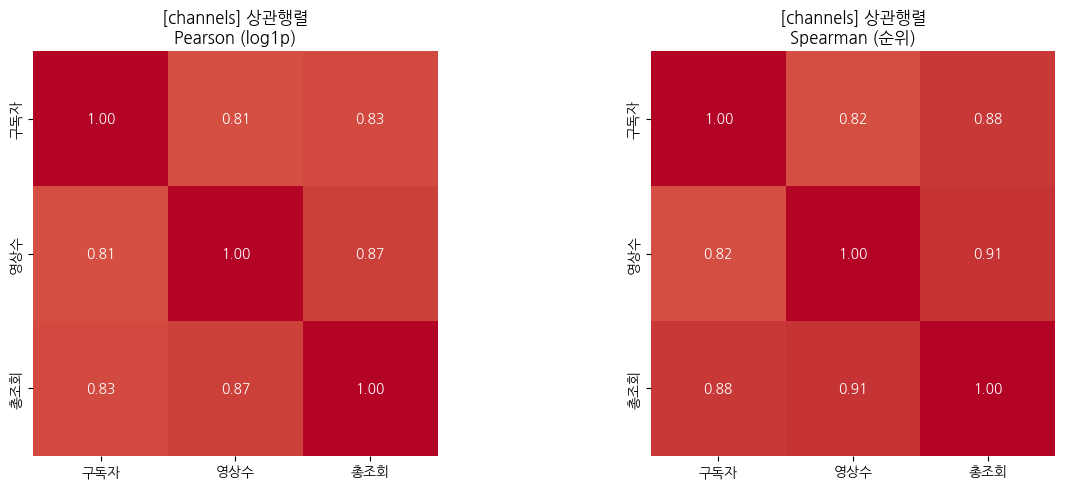

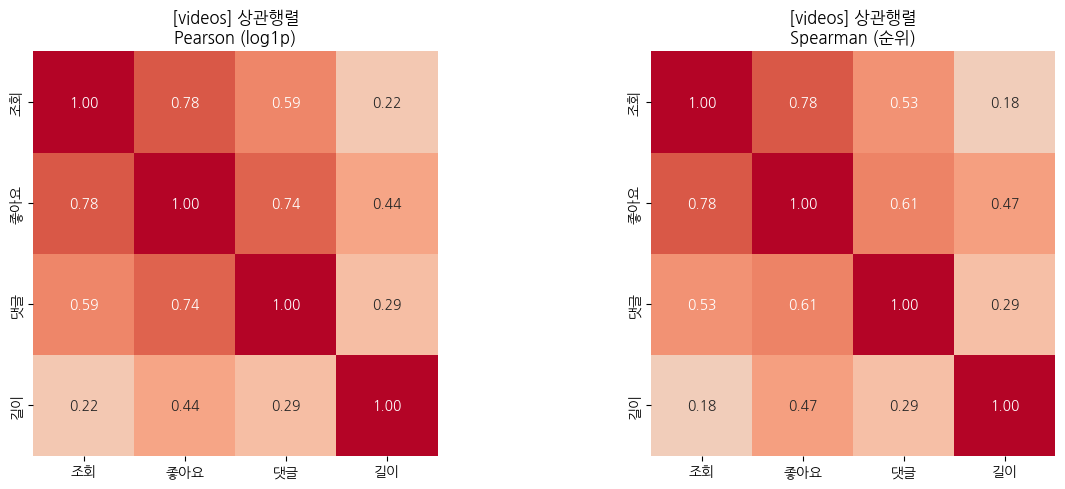

[comments] 길이-좋아요  Spearman 0.15 / Pearson(log1p) 0.15


In [31]:
def corr_pair(df, cols, title, labels):
    sub = df[cols].clip(lower=0)
    pear = np.log1p(sub).corr(method='pearson')   # 선형(우편향 보정 위해 log1p)
    spear = sub.corr(method='spearman')           # 단조(순위, 변환 불변)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for a, m, name in [(ax[0], pear, 'Pearson (log1p)'), (ax[1], spear, 'Spearman (순위)')]:
        sns.heatmap(m, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                    square=True, xticklabels=labels, yticklabels=labels,
                    cbar=False, ax=a)
        a.set_title(f'{title}\n{name}')
    plt.tight_layout(); plt.show()

# 채널 단위
corr_pair(df_channels, ['subscriber_count','video_count','view_count'],
          '[channels] 상관행렬', ['구독자','영상수','총조회'])
# 영상 단위
corr_pair(df_videos, vid_num4, '[videos] 상관행렬',
          ['조회','좋아요','댓글','길이'])

# 댓글 단위 (수치 = like_count·text 길이 2개뿐 → 쌍 상관만)
ctext_len = df_comments['text'].fillna('').astype(str).str.strip().str.len()
clike = df_comments['like_count'].clip(lower=0)
csp = ctext_len.corr(clike, method='spearman')
cpe = np.log1p(ctext_len).corr(np.log1p(clike), method='pearson')
print(f'[comments] 길이-좋아요  Spearman {csp:.2f} / Pearson(log1p) {cpe:.2f}')


##### 4-4-2 (이어서) — 파생 feature 다중공선성 점검

**목적**:  위에서는 원본 수치끼리 상관관계를 봄. 그런데 H1 분류 모델에 **실제로 입력될 변수**는 원본이 아니라, 3-2에서 우리가 직접 만든 **파생 채널 feature 20여 개**. 그래서 여기서 두 가지 도구로 중복을 직접 측정해 **다중공선성** 점검

**방법**:
- **Spearman 상관**: 두 변수의 '순위'가 같이 움직이는 정도(−1~+1). 본 데이터는 한쪽으로 우편향 분포이기 때문에 평범한 Pearson 상관은 극단치에 휘둘림. Spearman은 값 대신 등수로 보기 때문에 이런 쏠림에 강함. |ρ|이 0.7을 넘으면 사실상 "같은 변수"로 봄.
- **VIF**: 한 변수를 **나머지 변수 전부로 예측**해봤을 때, 잘 예측되면 그 변수는 중복이라는 뜻이고 VIF 값이 커짐. 보통 **VIF > 10**이면 다른 변수들과 강하게 겹친다고 판단.

파생 feature 표(`channel_features`)는 이 4-4 맨 앞 '채널 feature 매트릭스 조립' 단계에서 메모리에 만들어 둔 표를 그대로 사용한다(별도 파일 로드 없음).

완전관측(결측 없는) 채널 N = 1492


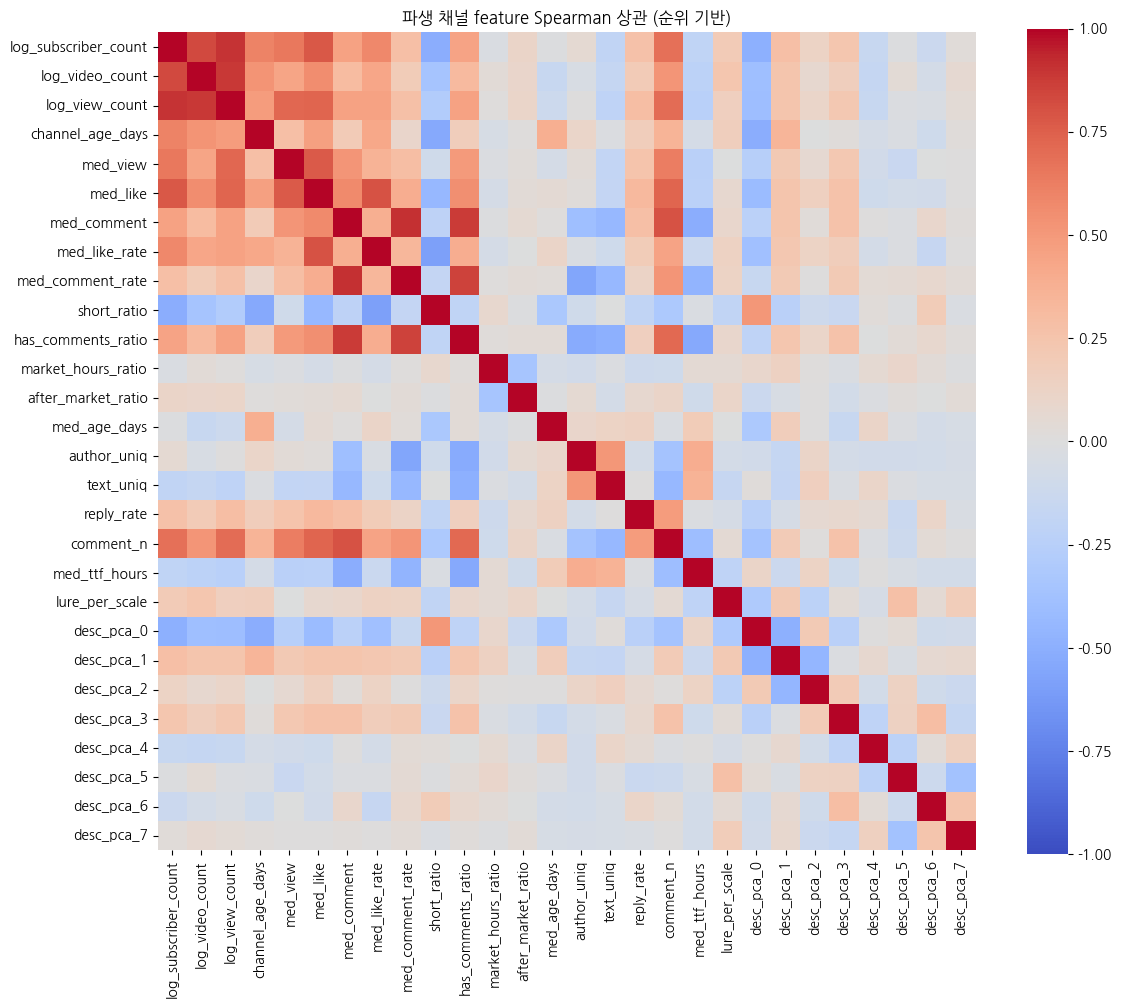

강한 상관 쌍 |rho| > 0.7 (사실상 중복 후보)


,var1,var2,spearman
0,med_comment,med_comment_rate,0.908
1,log_subscriber_count,log_view_count,0.902
2,log_video_count,log_view_count,0.885
3,med_comment,has_comments_ratio,0.882
4,med_comment_rate,has_comments_ratio,0.854
5,log_subscriber_count,log_video_count,0.833
6,med_comment,comment_n,0.801
7,med_like,med_like_rate,0.797
8,log_subscriber_count,med_like,0.775
9,med_view,med_like,0.767


VIF 계산용 dropna N = 1492
VIF (높을수록 다른 feature와 중복, >10 = 강한 중복)


,feature,VIF
0,med_comment,13.20
1,comment_n,10.55
2,log_view_count,9.80
3,log_subscriber_count,8.87
4,med_like,6.23
5,log_video_count,5.93
6,med_view,4.79
7,short_ratio,2.55
8,author_uniq,2.45
9,desc_pca_2,2.44


In [32]:

# H1 분류기에 실제로 들어갈 건 raw 원본이 아니라 3-2에서 만든 '파생 채널 feature'들.
# 그 최종 표(channel_features)는 바로 위 4-4 조립 단계에서 메모리에 만들었으므로 그대로 사용.
cf = channel_features.copy()

# 파생 feature끼리 너무 겹치면(다중공선성) 모델이 같은 정보 중복으로 받음 → 정리 필요
# H1 후보 연속형만 골라봄. id/title/0·1 플래그/outlier표시/규칙라벨(is_rule_anomaly)은 제외
deriv_feats = [
    'log_subscriber_count', 'log_video_count', 'log_view_count', 'channel_age_days',
    'med_view', 'med_like', 'med_comment', 'med_like_rate', 'med_comment_rate',
    'short_ratio', 'has_comments_ratio', 'market_hours_ratio', 'after_market_ratio',
    'med_age_days', 'author_uniq', 'text_uniq', 'reply_rate', 'comment_n',
    'med_ttf_hours', 'lure_per_scale',
]
deriv_feats += [c for c in cf.columns if c.startswith('desc_pca_')]   # 영상설명 의미축(TF-IDF+PCA) 추가
# inf는 NaN으로 바꿔 corr 계산에서 빠지게(분모0에서 생긴 inf 가드)
Xb = cf[deriv_feats].replace([np.inf, -np.inf], np.nan)

# Spearman(순위상관) 우선: 분포가 한쪽으로 쏠려 있어도 단조관계를 잡아줌
spear = Xb.corr(method='spearman')
print(f'완전관측(결측 없는) 채널 N = {Xb.dropna().shape[0]}')

plt.figure(figsize=(12, 10))
sns.heatmap(spear, annot=False, cmap='coolwarm', vmin=-1, vmax=1, square=True,
            xticklabels=deriv_feats, yticklabels=deriv_feats, cbar=True)
plt.title('파생 채널 feature Spearman 상관 (순위 기반)')
plt.tight_layout(); plt.show()

# |rho|>0.7 강한 쌍만 추려서 보기 좋게 정리
pairs = []
cols = spear.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = spear.iloc[i, j]
        if pd.notna(r) and abs(r) > 0.7:
            pairs.append((cols[i], cols[j], round(r, 3)))
high_corr = pd.DataFrame(pairs, columns=['var1', 'var2', 'spearman'])
high_corr = high_corr.reindex(high_corr['spearman'].abs().sort_values(ascending=False).index).reset_index(drop=True)
print('강한 상관 쌍 |rho| > 0.7 (사실상 중복 후보)')
display(high_corr)

# VIF(분산팽창계수): 한 feature를 나머지로 회귀했을 때 R²가 높으면(=남이 설명 가능) VIF 큼
# VIF>10 이면 보통 그 변수는 다른 변수들과 강하게 겹친다고 봄. statsmodels 없이 순수 numpy로 계산
Xv = Xb.dropna().copy()
print(f'VIF 계산용 dropna N = {Xv.shape[0]}')

# 표준화(z): 평균0 분산1로 맞춰 스케일 차이 제거. std==0이면 정보 없는 컬럼이라 빼기
keep = []
Z = Xv.copy()
for c in Z.columns:
    s = Z[c].std()
    if s == 0 or pd.isna(s):
        continue
    Z[c] = (Z[c] - Z[c].mean()) / s
    keep.append(c)
Z = Z[keep]
M = Z.values
n = M.shape[0]

vifs = []
for k, c in enumerate(keep):
    y = M[:, k]
    Xo = np.delete(M, k, axis=1)
    Xo = np.column_stack([np.ones(n), Xo])         # 절편 추가
    beta, *_ = np.linalg.lstsq(Xo, y, rcond=None)  # 최소제곱 회귀
    pred = Xo @ beta
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    vif = 1 / (1 - r2) if r2 < 0.999999 else np.inf  # R²→1 가드(완전공선이면 inf)
    vifs.append((c, round(vif, 2)))

vif_df = pd.DataFrame(vifs, columns=['feature', 'VIF']).sort_values('VIF', ascending=False).reset_index(drop=True)
print('VIF (높을수록 다른 feature와 중복, >10 = 강한 중복)')
display(vif_df)

**결과 해석**

완전관측(결측 없는) 채널 1,492개 기준. 강하게 겹치는 쌍(|Spearman ρ|>0.7)과 VIF 상위에서 같은 그림이 나온다.

- **규모 로그 3종**(`log_subscriber_count`·`log_video_count`·`log_view_count`)이 서로 0.83~0.90, VIF도 5.9~9.8 → 셋이 거의 한 덩어리. 구독·영상·조회는 결국 '채널이 얼마나 큰가'라는 하나의 축이다. → 그대로 다 넣지 말고 **PCA로 한 축으로 묶거나(H2)**, 대표 1개만 남긴다.
- **절대수 vs 비율**: `med_comment`↔`med_comment_rate` 0.91, `med_like`↔`med_like_rate` 0.80 → 영상당 '개수'(절대수)는 채널 규모를 그대로 반영해 비율과 겹친다. VIF도 `med_comment`가 13.2로 최고, `med_view`·`med_like`도 높다. → **절대수(`med_view`·`med_like`·`med_comment`)는 빼고, 조회로 정규화한 비율(`med_*_rate`)만 쓴다**(3-2-3에서 세운 '참여율로 본다' 원칙과 일치).
- 댓글량 계열도 서로 중복: `med_comment`↔`has_comments_ratio` 0.88, `comment_n`(VIF 10.6)↔`med_comment` 0.80. → `comment_n`은 feature보다는 '비율 신뢰 임계'(댓글 10개 이상만)로만 쓰고 모델 입력에서는 뺀다.
- 반대로 `author_uniq`·`text_uniq`(도배 축)·`reply_rate`·`med_ttf_hours`(시딩)·`lure_per_scale`(유도)·`short_ratio`·`market_hours_ratio`·`after_market_ratio`·`channel_age_days`는 VIF가 모두 2.6 미만 → 다른 변수로 설명되지 않는 **고유 신호**. 규모·참여와 별개 축이므로 그대로 **유지**한다.

(코스는 상관을 평문 표로만 보지만, 변수 20개의 가독성을 위해 히트맵으로 보강했다. 평문 수치는 위 '강한 상관 쌍'·'VIF' 표로 제공.)

##### 4-4-3. Regularity (규칙성)
**목적**: 데이터의 **추세·규칙**을 잡고 거기서 **벗어나는 이탈 = anomaly 후보**를 확인(4-3 Anomaly에서 이미 플래그로 생성 — 여기서 그 근거가 되는 규칙·이탈을 본다). 본 프로젝트 목표 직결 — 정상 채널은 규모-참여 규칙을 따르고, 작전성·유령은 규칙선을 이탈.

**방법** (보는 규칙 2가지)

| 규칙 | 내용 | anomaly 신호 |
|---|---|---|
| 시간 추세 | 채널 개설 연도별 신규 유입(3-2-5) | 최근 급증기 ↔ 리딩방 신생 가설 |
| 규모–참여 | 구독자↑→총조회↑ (Spearman 0.88, 4-4-2) | 규칙선 크게 이탈 = 작전/유령 후보 |

**결과**: 구독자~총조회 로그-로그 규칙선에서 |잔차|>2.5σ 이탈 = **54개(2.7%)** (원본 2,508 기준. 4-3 차단으로 유령·비주식이 빠진 잔존 flag는 51개)

**결론**
- 시간 추세 = 3-2-5 개설 급증(2026년 37%) 재확인 → 신생 채널군이 리딩방 가설 후보.
- 규모-참여 이탈 54개 = 구독 대비 조회 과다/과소 → **작전성·매수·유령 anomaly 후보**. anomaly=target이라 삭제 X → 4-3에서 이미 flag로 보존(이 규칙 이탈이 그 anomaly의 근거).
- Patterns 종합: 변수들이 강하게 묶이는(상관 0.8+) **규칙적 구조** 위에서 소수 이탈만 추출 = 이상 탐지 출발점. 이 이탈군이 H1 라벨·H2 군집 분리의 1차 후보.


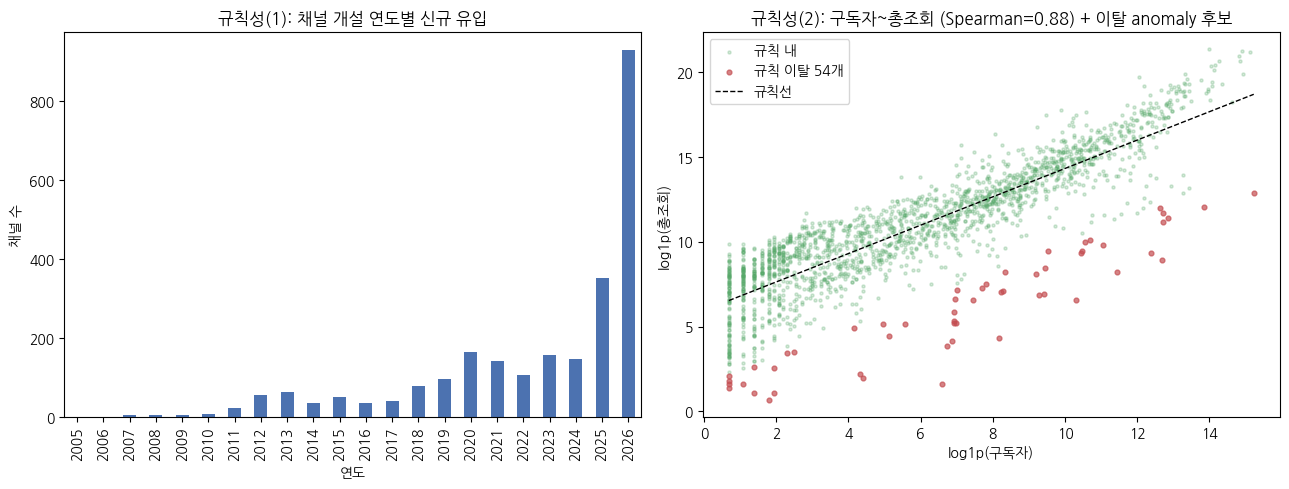

규모-참여 규칙 이탈 채널: 54개 (2.7%) → 작전/유령 anomaly 후보, 4-3 Anomaly에서 검토


In [33]:
m = (df_channels['subscriber_count'] > 0) & (df_channels['view_count'] > 0)
chm = df_channels[m].copy()
x, y = np.log1p(chm['subscriber_count']), np.log1p(chm['view_count'])
rho = chm[['subscriber_count','view_count']].corr(method='spearman').iloc[0,1]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# (1) 시간 추세: 개설 연도별 신규 채널
yr = pd.to_datetime(df_channels['published_at'], format='ISO8601', utc=True).dt.year
yr.value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4c72b0')
ax[0].set_title('규칙성(1): 채널 개설 연도별 신규 유입'); ax[0].set_xlabel('연도'); ax[0].set_ylabel('채널 수')

# (2) 규모-참여 규칙선 + 이탈(anomaly 후보)
coef = np.polyfit(x, y, 1)                       # 규칙선(로그-로그 추세)
resid = y - np.polyval(coef, x)                  # 규칙에서의 이탈
thr = 2.5 * resid.std()                          # 큰 이탈 임계
out = resid.abs() > thr
ax[1].scatter(x[~out], y[~out], s=5, alpha=0.25, color='#55a868', label='규칙 내')
ax[1].scatter(x[out],  y[out],  s=12, alpha=0.7, color='#c44e52', label=f'규칙 이탈 {int(out.sum())}개')
ax[1].plot(np.sort(x), np.polyval(coef, np.sort(x)), 'k--', lw=1, label='규칙선')
ax[1].set_xlabel('log1p(구독자)'); ax[1].set_ylabel('log1p(총조회)')
ax[1].set_title(f'규칙성(2): 구독자~총조회 (Spearman={rho:.2f}) + 이탈 anomaly 후보')
ax[1].legend()
plt.tight_layout(); plt.show()

print(f'규모-참여 규칙 이탈 채널: {int(out.sum())}개 ({out.mean()*100:.1f}%) → 작전/유령 anomaly 후보, 4-3 Anomaly에서 검토')

##### 4-4-3 (이어서) — 행동 분포의 규칙성 + H2 군집 미리보기

앞의 규칙성은 '크기' 축(구독자↑→총조회↑)이었다. 이제 **행동** 축에서 규칙과 이탈을 본다.

- `short_ratio`(채널 영상 중 쇼츠 비율)와 `author_uniq`(댓글 작성자 고유비율, **낮을수록 소수가 댓글을 도배**)의 분포 모양을 본다. 분포가 봉우리 두 개(0과 1 근처)로 갈리면, 채널 성격이 둘로 나뉜다는 신호다.
- 그리고 수업 자료(03_Data_Prepration 위버스 팬 활동 분석)에서처럼, 행동 두 축을 **z-score로 표준화**해 한 평면에 찍는다. z-score는 '평균에서 표준편차 몇 칸 떨어졌나'로, 단위가 다른 변수를 같은 잣대로 비교하게 해준다. 여기서는 가로축 `text_uniq`(낮을수록 댓글 복붙/도배), 세로축 `med_comment_rate`(높을수록 조회 대비 댓글 과열)로 놓고, **왼쪽 위(복붙 + 댓글 과열) 코너**에 채널이 따로 모이는지 본다.

이 산점도는 **H2(군집/PCA)에서 실제로 군집이 갈릴 수 있는지 미리 보는 용도**다. 군집 알고리즘 자체는 H2에서 돌리고, 여기서는 분리 가능성만 눈으로 확인한다(가설은 이미 세워둠 → HARKing 아님).

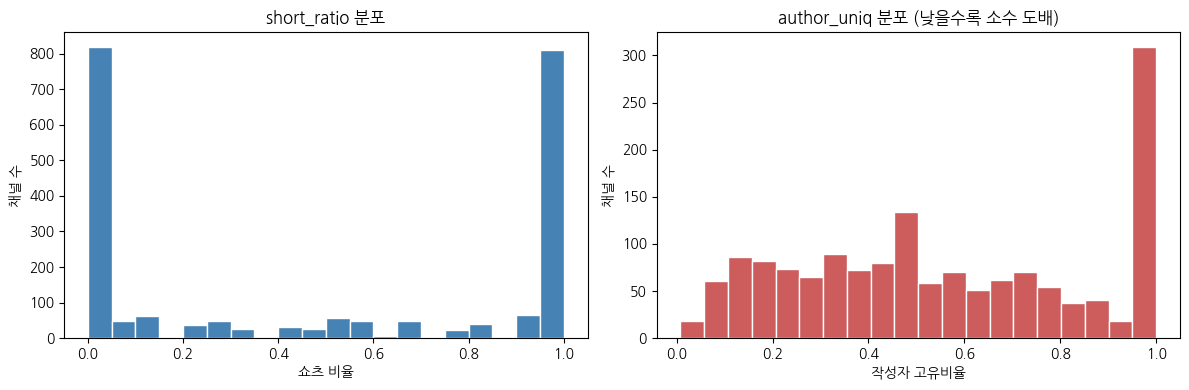

산점도 사용 N = 1526


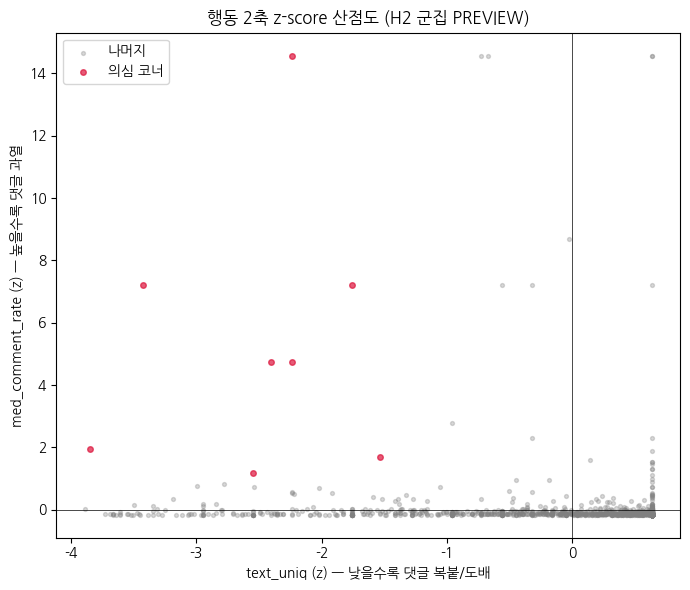

의심 코너(복붙+댓글과열) 채널 수 = 8
author_uniq < 0.3 채널 = 373개
author_uniq < 0.5 채널 = 681개


In [34]:
# 4-4 맨 앞에서 조립한 매트릭스 사용(앞 4-4-2 셀에서 cf 정의됨)
cf = channel_features


# 행동 분포 모양부터 눈으로 확인: 양봉(0/1로 갈림)이면 채널 성격이 둘로 나뉜다는 신호
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# short_ratio: 채널 영상 중 쇼츠 비율. 0 또는 1에 몰리면 "쇼츠 전문" vs "롱폼 전문"으로 갈림
ax[0].hist(cf['short_ratio'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax[0].set_title('short_ratio 분포'); ax[0].set_xlabel('쇼츠 비율'); ax[0].set_ylabel('채널 수')
# author_uniq: 댓글 작성자 고유비율. 낮다 = 소수가 댓글 도배(같은 사람이 계속 씀) → 리딩방 의심 신호
ax[1].hist(cf['author_uniq'].dropna(), bins=20, color='indianred', edgecolor='white')
ax[1].set_title('author_uniq 분포 (낮을수록 소수 도배)'); ax[1].set_xlabel('작성자 고유비율'); ax[1].set_ylabel('채널 수')
plt.tight_layout(); plt.show()

# z-score 산점도(수업 위버스 방식): 행동 2축을 표준화해 한 평면에 놓고 의심 코너를 본다
#  x축 text_uniq 낮음 = 댓글 텍스트 복붙(도배), y축 med_comment_rate 높음 = 조회 대비 댓글 과열
#  → 왼쪽 위(복붙 + 댓글 과열) = 작전성 의심 코너. 군집 자체는 H2에서 하고 여기선 PREVIEW만
axes_cols = ['text_uniq', 'med_comment_rate']
sc = cf[axes_cols].replace([np.inf, -np.inf], np.nan).dropna()
print(f'산점도 사용 N = {sc.shape[0]}')

sx, sy = sc['text_uniq'].std(), sc['med_comment_rate'].std()
zx = (sc['text_uniq'] - sc['text_uniq'].mean()) / sx if sx > 0 else sc['text_uniq'] * 0      # std==0 가드
zy = (sc['med_comment_rate'] - sc['med_comment_rate'].mean()) / sy if sy > 0 else sc['med_comment_rate'] * 0
susp = (zx < -1) & (zy > 1)  # 복붙 심함 + 댓글 과열 = 의심 코너

plt.figure(figsize=(7, 6))
plt.scatter(zx[~susp], zy[~susp], s=8, alpha=0.3, color='gray', label='나머지')
plt.scatter(zx[susp], zy[susp], s=16, alpha=0.7, color='crimson', label='의심 코너')
plt.axvline(0, color='k', lw=0.5); plt.axhline(0, color='k', lw=0.5)
plt.xlabel('text_uniq (z) — 낮을수록 댓글 복붙/도배')
plt.ylabel('med_comment_rate (z) — 높을수록 댓글 과열')
plt.title('행동 2축 z-score 산점도 (H2 군집 PREVIEW)')
plt.legend(); plt.tight_layout(); plt.show()
print(f'의심 코너(복붙+댓글과열) 채널 수 = {int(susp.sum())}')

# author_uniq 임계값 민감도: 어디서 끊든 "소수 도배" 후보가 꽤 잡힘
print(f'author_uniq < 0.3 채널 = {(cf["author_uniq"] < 0.3).sum()}개')
print(f'author_uniq < 0.5 채널 = {(cf["author_uniq"] < 0.5).sum()}개')

**결과 해석**

- `short_ratio`는 0과 1 양 끝에 몰린 **양봉 분포**(중앙값 0.46, 하위25%=0.0 / 상위75%=1.0) → '쇼츠 전문 채널'과 '롱폼 전문 채널'로 뚜렷이 갈린다.
- `author_uniq`는 중앙값 0.51로 퍼져 있되 **낮은 쪽 꼬리**가 있다. 임계를 0.3으로 잡으면 373개, 0.5로 잡으면 681개 채널이 걸린다 → 어디서 끊든 '소수 도배' 의심 채널이 꾸준히 잡힌다(임계에 둔감 = 결론 robust).
- z-score 산점도에서 '복붙 + 댓글 과열' 의심 코너(가로 z<−1 & 세로 z>+1)에 **8개 채널**이 분리돼 모인다 → 소수지만 행동축에서 따로 떨어지는 군이 존재 → **H2 군집 분리 가능성의 1차 근거**.

##### 4-4-4. 댓글 시딩 패턴 - 첫 댓글까지 시간 (행동 timing 관계)
**목적**: 영상 게시 후 **첫 댓글까지 걸린 시간**(`first_comment − published`) 분포로 **시딩(seeding) 정황** 점검. 게시 직후 즉시 댓글 = 대기·동원 작성자(바람잡이·관리방) 의심. 두 timestamp(영상·댓글) 관계라 단변량(3-2) 아닌 패턴(4-4).

**결과** (댓글 달린 영상 15,618개)

| 지표 | 값 |
|---|---|
| 첫 댓글까지 중앙값 | **0.23시간(≈14분)** |
| 1시간 이내 | **65.2%** |
| 24시간 이내 | 76.8% |
| 음수(영상 게시 전 댓글=수집 시각 불일치) | 1,931개(12.4%) |

**결론**
- 첫 댓글 중앙 14분·1시간내 65% = **상당수 영상이 게시 직후 즉시 댓글** → 대기 작성자 동원(시딩) 정황. 3-2-8 작성자 집중(소수 도배)과 같은 작전 신호 축.
- anomaly=target → 즉시 시딩 영상·채널 삭제 X, **flag**(4-3서 처리). 채널 집계 `median_ttf`(첫댓글 중앙시간) = H1 행동 feature·H2 군집 후보.
- 음수 12.4% caveat: 영상 published_at보다 이른 댓글 timestamp = API 수집 시각 불일치(타임존·게시 전 비공개 등). 시딩 계산 시 음수 제외 → 양수만 중앙 0.43h·1시간내 60.3%로 결론 동일.


댓글 달린 영상 15,618개
첫 댓글까지 중앙 0.23h / 1시간내 65.2% / 24시간내 76.8%
음수(게시 전 댓글=수집 시각 불일치) 1,931개 (12.4%)


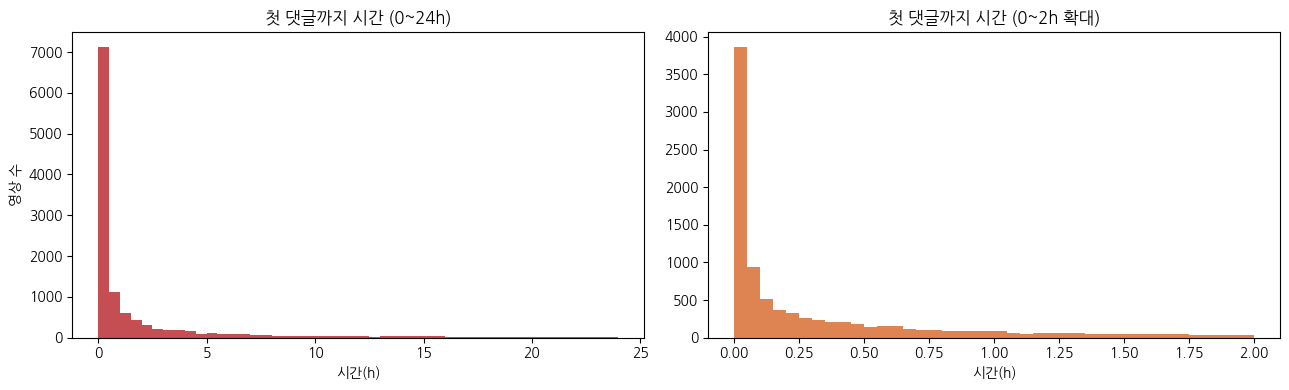

채널 단위 median_ttf 생성: 1,539개 채널 (양수 first-comment 기준)


In [35]:
# 첫 댓글까지 시간: 영상 게시 → 그 영상 첫 댓글 (두 timestamp 관계 = 4-4)
v_pub = pd.to_datetime(df_videos['published_at'],   format='ISO8601', utc=True)
c_pub = pd.to_datetime(df_comments['published_at'], format='ISO8601', utc=True)
first_c   = c_pub.groupby(df_comments['video_id']).min()
v_pub_map = v_pub.set_axis(df_videos['video_id'])           # tz 보존(.values 쓰면 tz 소실)
ttf = ((first_c - v_pub_map.reindex(first_c.index)).dt.total_seconds() / 3600).dropna()

print(f'댓글 달린 영상 {len(ttf):,}개')
print(f'첫 댓글까지 중앙 {ttf.median():.2f}h / 1시간내 {(ttf<=1).mean()*100:.1f}% / 24시간내 {ttf.between(0,24).mean()*100:.1f}%')
print(f'음수(게시 전 댓글=수집 시각 불일치) {int((ttf<0).sum()):,}개 ({(ttf<0).mean()*100:.1f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(ttf[ttf.between(0, 24)], bins=48, color='#c44e52')
ax[0].set_title('첫 댓글까지 시간 (0~24h)'); ax[0].set_xlabel('시간(h)'); ax[0].set_ylabel('영상 수')
ax[1].hist(ttf[ttf.between(0, 2)], bins=40, color='#dd8452')
ax[1].set_title('첫 댓글까지 시간 (0~2h 확대)'); ax[1].set_xlabel('시간(h)')
plt.tight_layout(); plt.show()

# 채널 집계 median_ttf(양수만) — 이미 4-4 매트릭스 조립에 반영됨, 여기선 분포 탐색용 재계산
_vid2ch = df_videos.set_index('video_id')['channel_id']
_ttf_pos = ttf[ttf >= 0]
chan_ttf = _ttf_pos.groupby(_vid2ch.reindex(_ttf_pos.index)).median().rename('med_ttf_hours')
print(f'채널 단위 median_ttf 생성: {chan_ttf.notna().sum():,}개 채널 (양수 first-comment 기준)')


#### 4-4 종합 — 모든 변수의 패턴 탐색 결과와 처리 방침 (4-1~4-3 적용 / 4-5 선별·저장)

4-4에서 변수 사이의 관계(공분산·상관·VIF·규칙성)를 다 본 결과를, **변수별로** "어떤 패턴이 나왔나 → 앞 4-1~4-3에서 어떻게 처리됐나 / 4-5에서 어떻게 선별·저장할까"로 정리한다. (전처리 표시: **유지**=feature로 keep / **중복제거**=다른 변수와 겹쳐 drop / **PCA**=차원축소로 묶음 / **flag-보존**=anomaly라 삭제 않고 표시 / **leakage-제외**=라벨 누수라 feature 금지.)

| 변수군 (관측 단위) | 패턴 탐색 방법 | 발견 | 처리 방침 |
|---|---|---|---|
| 영상 조회·좋아요·댓글 (영상) | 공분산(부호+)·Spearman 0.53~0.78 | 규모 따라 같이 큼·참여 3종 묶음 | 절대수 **중복제거**, 비율(`med_*_rate`)만 유지 |
| 영상 길이 `duration_seconds` (영상) | 상관(조회와 0.18) | 거의 독립 | **유지**(쇼츠 판별 보조) |
| 채널 규모 `log_subscriber/video/view` (채널) | 상관 0.83~0.90·VIF 5.9~9.8 | 강한 다중공선성(한 덩어리) | **PCA(H2)** 또는 대표 1개만 유지, 나머지 중복제거 |
| `channel_age_days` (채널) | 규칙성(개설 급증) | 신생 채널 다수 | **유지**(리딩방 신생 가설) |
| `med_view`·`med_like`·`med_comment` (채널) | 상관(비율과 0.80 안팎)·VIF(`med_comment` 13.2) | 규모종속 중복 | 절대수 **중복제거** |
| `med_like_rate`·`med_comment_rate` (채널) | 상관·VIF 낮음 | 참여 핵심 신호 | **유지** |
| `short_ratio` (채널) | 규칙성(양봉 분포) | 쇼츠/롱폼 분리 | **유지** |
| `market_hours_ratio`·`after_market_ratio` (채널) | 규칙성(시각 쏠림) | 장중/장마감 집중 | **유지**(시황민감도 H3) |
| `has_comments_ratio`·`comment_n` (채널) | 상관 0.71~0.88·VIF(`comment_n` 10.6) | 댓글량 계열 중복 | `comment_n`=신뢰 임계용, 모델 입력 **중복제거** |
| `author_uniq`·`text_uniq` (채널) | 상관·VIF 낮음(독립) | 도배 고유 신호 | **유지**(도배 축) |
| `reply_rate` (채널) | 상관 낮음 | 참여구조 신호 | **유지** |
| `med_ttf_hours` (채널) | 4-4-4 시딩(첫댓글 14분) | 즉시 시딩 정황 | **유지 + flag-보존** |
| `lure_per_scale`·상호작용(`kakao_dobae`·`lure_textdup`·`lure_x_commentrate`) (채널) | 상관 낮음(독립) | 외부유도 고유 신호 | **유지** |
| 단독 연락처 플래그 `has_url`~`has_email` (채널) | 3-2-9 판정 | 단독으로는 약함 | 단독 **중복제거**, 상호작용으로 대체 |
| `is_rule_anomaly` (채널) | 규칙성 이탈(4-4-3) | 작전성 후보 = 타깃 신호 | **flag-보존**(4-3, 삭제 X, 수동 검증). 유령/비활성·비주식·`like_rate>1`은 4-3서 차단(삭제)됨 |
| `desc_pca_0…k` (채널, 영상설명 TF-IDF+PCA) | TF-IDF→PCA 주성분 | 영상 설명 의미 결 | **유지**(수집 검색어 제거로 직접 누수는 차단. 단 규제어의 의미 자체는 임베딩에 남을 수 있어 H1 본검증 투입 여부는 모델링서 ablation으로 판단) |
| `search_query`·`query_group` | — | 수집 키워드 = 약한 라벨 | **leakage-제외**(feature 절대 금지, 평가·prior만) |
| `med_age_days` (채널) | 상관·VIF 낮음(1.7) | 영상 나이 보정축·독립 | **유지** |
| `like_rate>1` 영상 | 좋아요>조회 | 물리적 불가능 = 데이터오류 | **삭제됨**(4-3 Deletion) |
| `is_new_channel`·`is_kr` (채널, 이진 파생) | 단변량(3-2)·규칙성 | 0/1 파생 플래그 | **유지**(이진이라 연속 corr/VIF 대상 아님) |
| `country`·`language` (범주) | 3-2-4 결측 점검 | 결측·편중 | feature 제외, 결측 시각화로만 사용 |

**주의(caveat)**
- 모집단 = '30개 주식 검색어로 찾은 채널'이라, 경제 유튜브 **전체로 일반화 금지**(선택편향). 결론은 이 모집단 한정.
- 파생 feature가 모두 채워진(결측 없는) 채널은 (4-3 차단 후) 2,214개 중 **1,492개**뿐 → 위 상관·VIF는 이 부분표본 기준. 결측 자체의 처리는 4-1(결측)에서 이미 다뤘다(이 매트릭스는 그 정제 결과 위에서 조립).
- anomaly 중 **규칙 이탈·도배·시딩·외부유도**(타깃 신호)는 삭제하지 않고 플래그로 보존. 다만 **유령/비활성·비주식·`like_rate>1`**(죽은·무관·오류 표본)은 타깃이 아니므로 4-3서 차단(Deletion).
- `desc_pca_*`는 전체 채널로 TF-IDF·PCA를 fit한 EDA 후보 feature → 실제 H1 학습 시엔 train fold 안에서 재fit해야 누수 없음(StandardScaler와 동일 주의).

**다음 단계**: 위 '중복제거/PCA/유지' 판정을 4-5에서 최종 모델 입력 feature로 확정·저장 → 규모 묶음은 H2 PCA, 시황·참여·도배 축은 H3 검정으로 연결.

#### 4-5. 분석용 데이터셋 조립 & 저장
**목적**: 전처리 결과를 정제 테이블 3개 + **채널 단위 모델링 매트릭스**로 저장.

**방법**: 채널 단위 매트릭스 자체는 4-4 맨 앞 '채널 feature 매트릭스 조립'에서 이미 메모리에 만들어 패턴 탐색에 썼다. 여기서는 그 매트릭스에 대해 4-4 패턴 판정(중복제거/PCA/유지)을 모델 입력 spec으로 확정하고, 정제 테이블 3개와 함께 파일로 저장한다. (집계 단위 = 채널: 영상 참여지표 채널별 중앙값, 댓글 행동 3-2-8, 연락처 플래그 3-2-9, 첫댓글 시딩 4-4-4, 업로드 시각대 3-2-5 H3.)

**결과 — 산출물** (`data/processed/`)

| 파일 | 내용 |
|---|---|
| `channels_clean` | 채널 + 결측처리(country→is_kr Imputation·language Deletion·나머지 Retention) + log feature + anomaly flag + 채널나이 |
| `videos_clean` | 영상 + 참여비율 + age + 시각대 flag |
| `comments_clean` | 댓글 원값(정제) — 대댓글율은 4-4서 `parent_id`로 산출 |
| `channel_features` | 채널단위 ML 입력(H1/H2/H3) |
| `channel_labels` | `search_query`(약한 라벨 prior) — **누수 차단 위해 feature서 분리**, 평가·시드라벨 전용 |

EDA에서 신호로 짚은 feature를 채널 단위로 추가: 댓글행동(`author_uniq`·`text_uniq`·`reply_rate`·`comment_n`), 연락처 개별 플래그(`has_url`·`has_kakao`·`has_phone`·`has_telegram`·`has_band`·`has_email`), 첫댓글 중앙시간(`med_ttf_hours`), 업로드 시각대 비율(`market_hours_ratio`·`after_market_ratio`), 채널나이(`channel_age_days`·`is_new_channel`), 상호작용 파생(`kakao_dobae`·`lure_textdup`·`lure_x_commentrate`·`lure_per_scale`, 3-2-10). 모든 파생은 4-4 상관 점검 후 선별.

**결론**
- 원본 DB는 건드리지 않고 csv로 별도 저장(TermProject1 제출 dataset 포함).
- **표준화(StandardScaler)는 여기서 적용하지 않는다**: PCA(H2)·거리기반 군집은 표준화가 필요하나 train/test 분리 *후* fit해야 누수가 없으므로 모델링 단계에서 수행. log feature는 분포 보정용(표준화와 별개).
- 댓글·시딩 feature는 댓글 없는 채널에서 NaN → 모델 입력 전 결측 처리(중앙값 대치 또는 결측 flag) 필요. `comment_n`으로 신뢰 게이팅 가능.


In [36]:
# 채널 매트릭스(channel_features)는 4-4 맨 앞에서 이미 조립됨. 여기서는 정제 테이블 + 매트릭스를 파일로 저장.
# ---- 저장 (원본 DB 보존, processed/ 별도) ----
from pathlib import Path
out = Path('/home/songyaeji/stockguard_for_youtube/data/processed'); out.mkdir(parents=True, exist_ok=True)

def save(df, name):
    df.to_csv(out / f'{name}.csv', index=False)
    try:
        df.to_parquet(out / f'{name}.parquet', index=False)   # pyarrow 있으면
    except Exception as e:
        print(f'  (parquet 건너뜀: {type(e).__name__})')

# 라벨 누수 차단: search_query(약한 라벨 prior) 별도 파일 — 평가·시드라벨 전용, feature 아님
channel_labels = ch[['channel_id','title','search_query']].copy()

save(ch, 'channels_clean')
save(vd, 'videos_clean')
save(cm, 'comments_clean')
save(channel_features, 'channel_features')
save(channel_labels, 'channel_labels')

print('저장 완료 →', out)
print(f'  channels_clean   {ch.shape}')
print(f'  videos_clean     {vd.shape}')
print(f'  comments_clean   {cm.shape}')
print(f'  channel_features {channel_features.shape}  ← ML 입력(H1/H2/H3)')
display(channel_features.head(3))

  (parquet 건너뜀: ImportError)


  (parquet 건너뜀: ImportError)


  (parquet 건너뜀: ImportError)
  (parquet 건너뜀: ImportError)
  (parquet 건너뜀: ImportError)
저장 완료 → /home/songyaeji/stockguard_for_youtube/data/processed
  channels_clean   (2214, 20)
  videos_clean     (32972, 24)
  comments_clean   (421987, 9)
  channel_features (2214, 46)  ← ML 입력(H1/H2/H3)


,channel_id,title,is_kr,subscriber_count,video_count,view_count,log_subscriber_count,log_video_count,log_view_count,channel_age_days,...,lure_per_scale,med_ttf_hours,desc_pca_0,desc_pca_1,desc_pca_2,desc_pca_3,desc_pca_4,desc_pca_5,desc_pca_6,desc_pca_7
0,UCzcy0PURMktW2BBgNpih-rw,청담개미여왕,0,83,35,36736,4.430817,3.583519,10.511540,352.029856,...,0.0,13.621944,-0.027227,-0.024584,0.010467,-0.109477,-0.019087,-0.037633,-0.031061,0.059854
1,UCAcesv8qLL5-4BLI6bhHKxg,주식명사수 주명,1,15000,131,1680579,9.615872,4.882802,14.334650,80.002758,...,0.0,0.008611,-0.081906,-0.019052,0.023952,0.033213,-0.136155,-0.027830,-0.068024,0.039824
2,UC0HOU_uMrAmnT4U5VMnqpKg,주식실세,1,1020,2,177,6.928538,1.098612,5.181784,2176.137382,...,0.0,NaN,-0.058418,0.016480,-0.035131,-0.153984,0.062929,-0.040095,-0.042501,0.056318
